# **Environment Setup**

## **Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Data Understanding**

## **Dataset Path Setup**

In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/kaggle_app_reviews"

def find_csv(folder_name, keyword=None):
    folder_path = os.path.join(BASE_DIR, folder_name)
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(".csv"):
                if keyword is None or keyword.lower() in f.lower():
                    return os.path.join(root, f)
    return None

dataset_paths = {
    "ds1_top10_global_apps": find_csv("ds1_top10_global_apps"),
    "ds2_spotify_reviews_2022": find_csv("ds2_spotify_reviews_2022"),
    "ds3_appstore_music_reviews": find_csv("ds3_appstore_music_reviews"),
    "ds4_top20_apps_daily": find_csv("ds4_top20_apps_daily", keyword="Spotify")
}

print(dataset_paths)

{'ds1_top10_global_apps': '/content/drive/MyDrive/kaggle_app_reviews/ds1_top10_global_apps/Top10_global_apps_by_downloads_playstore_reviews.csv', 'ds2_spotify_reviews_2022': '/content/drive/MyDrive/kaggle_app_reviews/ds2_spotify_reviews_2022/reviews.csv', 'ds3_appstore_music_reviews': '/content/drive/MyDrive/kaggle_app_reviews/ds3_appstore_music_reviews/app_store_music_reviews.csv', 'ds4_top20_apps_daily': '/content/drive/MyDrive/kaggle_app_reviews/ds4_top20_apps_daily/Spotify.csv'}


## **Check Dataset File Existence**

In [3]:
for name, path in dataset_paths.items():
    print(name, "->", path, "->", os.path.exists(path) if path else "Not found")

ds1_top10_global_apps -> /content/drive/MyDrive/kaggle_app_reviews/ds1_top10_global_apps/Top10_global_apps_by_downloads_playstore_reviews.csv -> True
ds2_spotify_reviews_2022 -> /content/drive/MyDrive/kaggle_app_reviews/ds2_spotify_reviews_2022/reviews.csv -> True
ds3_appstore_music_reviews -> /content/drive/MyDrive/kaggle_app_reviews/ds3_appstore_music_reviews/app_store_music_reviews.csv -> True
ds4_top20_apps_daily -> /content/drive/MyDrive/kaggle_app_reviews/ds4_top20_apps_daily/Spotify.csv -> True


## **Read Dataset Function**

In [4]:
import pandas as pd
from IPython.display import display

def read_dataset(file_path, sample_rows=None):
    try:
        if sample_rows:
            return pd.read_csv(file_path, nrows=sample_rows, low_memory=False)
        return pd.read_csv(file_path, low_memory=False)
    except UnicodeDecodeError:
        if sample_rows:
            return pd.read_csv(file_path, nrows=sample_rows, encoding="latin1", low_memory=False)
        return pd.read_csv(file_path, encoding="latin1", low_memory=False)

def detect_columns(df):
    cols = df.columns.tolist()

    text_candidates = [c for c in cols if any(k in c.lower() for k in ["review", "content", "comment", "text", "body"])]
    rating_candidates = [c for c in cols if any(k in c.lower() for k in ["rating", "score", "star", "stars"])]
    date_candidates = [c for c in cols if any(k in c.lower() for k in ["date", "time", "at", "created", "updated"])]
    app_candidates = [c for c in cols if any(k in c.lower() for k in ["app", "package", "bundle", "store", "platform", "track"])]

    return {
        "text_candidates": text_candidates,
        "rating_candidates": rating_candidates,
        "date_candidates": date_candidates,
        "app_candidates": app_candidates
    }

def understand_dataset(dataset_name, file_path, sample_rows=None):
    print("=" * 120)
    print("DATASET:", dataset_name)
    print("FILE:", file_path)

    if sample_rows:
        print(f"Reading sample only: first {sample_rows} rows")
    df = read_dataset(file_path, sample_rows=sample_rows)

    print("\n1) Shape")
    print(df.shape)

    print("\n2) Columns")
    print(df.columns.tolist())

    print("\n3) Data types")
    display(df.dtypes.to_frame("dtype"))

    print("\n4) First 5 rows")
    display(df.head())

    print("\n5) Missing values")
    missing_df = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values("missing_count", ascending=False)
    display(missing_df)

    print("\n6) Duplicate rows")
    print(df.duplicated().sum())

    print("\n7) Numeric summary")
    numeric_df = df.select_dtypes(include="number")
    if not numeric_df.empty:
        display(numeric_df.describe().T)
    else:
        print("No numeric columns found.")

    detected = detect_columns(df)

    print("\n8) Candidate text columns")
    print(detected["text_candidates"])

    print("\n9) Candidate rating columns")
    print(detected["rating_candidates"])

    print("\n10) Candidate date columns")
    print(detected["date_candidates"])

    print("\n11) Candidate app/store columns")
    print(detected["app_candidates"])

    for col in detected["app_candidates"][:3]:
        print(f"\nTop values for app/store column: {col}")
        display(df[col].astype(str).value_counts(dropna=False).head(15))

    for col in detected["text_candidates"][:2]:
        print(f"\nSample review text from: {col}")
        display(df[col].dropna().astype(str).head(5))

    if detected["rating_candidates"]:
        rating_col = detected["rating_candidates"][0]
        print(f"\n12) Rating distribution for: {rating_col}")
        display(df[rating_col].value_counts(dropna=False).sort_index())

    if detected["date_candidates"]:
        date_col = detected["date_candidates"][0]
        parsed_dates = pd.to_datetime(df[date_col], errors="coerce")
        print(f"\n13) Date coverage for: {date_col}")
        print("Parsed non-null:", parsed_dates.notna().sum())
        if parsed_dates.notna().sum() > 0:
            print("Earliest:", parsed_dates.min())
            print("Latest:", parsed_dates.max())

    if detected["text_candidates"]:
        text_col = detected["text_candidates"][0]
        review_length = df[text_col].astype(str).str.len()
        print(f"\n14) Review length summary for: {text_col}")
        print(review_length.describe())

    return df, detected

## **Dataset Overview Checking**

In [5]:
understanding_results = {}

for name, path in dataset_paths.items():
    sample_rows = 50000 if name == "ds4_spotify_34m_reviews" else None
    df_temp, detected = understand_dataset(name, path, sample_rows=sample_rows)
    understanding_results[name] = {
        "path": path,
        "detected": detected
    }

DATASET: ds1_top10_global_apps
FILE: /content/drive/MyDrive/kaggle_app_reviews/ds1_top10_global_apps/Top10_global_apps_by_downloads_playstore_reviews.csv

1) Shape
(50000, 5)

2) Columns
['reviewId', 'content', 'score', 'app', 'category']

3) Data types


,dtype
reviewId,object
content,object
score,int64
app,object
category,object



4) First 5 rows


,reviewId,content,score,app,category
0,7ef2741f-fd7a-4eef-8ea8-5e3bc2806e9a,"Super, 😉",5,WhatsApp Messenger,communication
1,bdbb60b4-7290-4f54-8506-899e92ae1fa5,Good,1,WhatsApp Messenger,communication
2,b1965a5d-093d-4787-974a-7b9128fa10c3,Helpful,4,WhatsApp Messenger,communication
3,f6087b82-2e03-49ea-8dda-8854992565b5,Best forever,3,WhatsApp Messenger,communication
4,2eb65092-f7fb-4ef4-b18a-53941caf13b0,Good,5,WhatsApp Messenger,communication



5) Missing values


...


Sample review text from: content


,content
0,great variety of music to pick from and very e...
1,i already pay for premium but in 15 days it's ...
2,On repeat is really messed up... it won't add ...
3,song is good
4,easy to use. clear.



12) Rating distribution for: score


,count
score,
1,2445
2,489
3,530
4,882
5,5654



14) Review length summary for: reviewId
count    10000.0
mean        36.0
std          0.0
min         36.0
25%         36.0
50%         36.0
75%         36.0
max         36.0
Name: reviewId, dtype: float64


**1.   Dataset 1: Top10_global_apps_by_downloads_playstore_reviews.csv**
*  The dataset has 50000 records with 5 columns.
*  In the dataset, there are 5000 of records are related to Spotify's review which are future analysis needed.
*  Qualitative Data: reviewId, content, app, caategory; Quantitative Data: score
*  There are 11 data's content are missing value. If the Spotify has missing content.The record will be erased.
* The reviewId, app and category columns will be deleted which are not important features for future analysis.
* The dataset does not have duplicate rows.

**2.   Dataset 2: reviews.csv**
* The dataset has 61594 records with 5 columns.
* Qualitative Data: Time_submitted, Review, Reply; Quantitative Data: Rating, Total_thumbsup
* There are 61378 data's reply are missing value. But the feature are not important features, so the columns can be ignored.
* The Time_submitted, Reply and Total_thumbsup columns will be deleted which are not important for future analysis.
* The dataset does not have duplicate rows.

**3. Dataset 3: app_store_music_reviews.csv**
* The dataset has 5640 records with 6 columns
* In the dataset, there are 950 of records are related to Spotify's review which are needed for future analysis
* Qualitative Data: app, country, title, review, date;Quantitative Data: rating
* There are no missing value
* The app, country, title and date columns will be deleted which are not important for future analysis.
* The dataset does not have duplicate rows.

**4. Dataset 4: Spotify.csv**
* The dataset has 10000 records with 3 columns
* Qualitative Data: reviewId, content; Quantitative Data: rating
* There no missing value
* The dataset does not have duplicate rows.

## **Check Dataset Columns and Sample Rows**

In [6]:
for name in ["ds1_top10_global_apps", "ds3_appstore_music_reviews"]:
    path = dataset_paths[name]
    df = read_dataset(path, sample_rows=5)
    print("=" * 100)
    print(name)
    print(df.columns.tolist())
    display(df.head())

ds1_top10_global_apps
['reviewId', 'content', 'score', 'app', 'category']


,reviewId,content,score,app,category
0,7ef2741f-fd7a-4eef-8ea8-5e3bc2806e9a,"Super, 😉",5,WhatsApp Messenger,communication
1,bdbb60b4-7290-4f54-8506-899e92ae1fa5,Good,1,WhatsApp Messenger,communication
2,b1965a5d-093d-4787-974a-7b9128fa10c3,Helpful,4,WhatsApp Messenger,communication
3,f6087b82-2e03-49ea-8dda-8854992565b5,Best forever,3,WhatsApp Messenger,communication
4,2eb65092-f7fb-4ef4-b18a-53941caf13b0,Good,5,WhatsApp Messenger,communication


ds3_appstore_music_reviews
['app', 'country', 'title', 'review', 'rating', 'date']


,app,country,title,review,rating,date
0,Spotify,MX,Muy buena aplicación de música. Casi sin anunc...,La,5,2025-05-21 18:57:56-07:00
1,SoundCloud,US,I have loved you from day 1 bi,"Nah fr tho, omm nothing but love for SoundClou...",5,2025-05-21 18:56:41-07:00
2,Spotify,MX,Los amo,Los amo,5,2025-05-21 18:56:12-07:00
3,Deezer,US,Must have a premium account to download music,I got this music app so I could download songs...,1,2025-05-21 18:50:34-07:00
4,Apple Music,US,4 star,I tunes don’t have all the songs like to liste...,4,2025-05-21 18:50:04-07:00


## **Check Spotify-only Records in Dataset 1**

In [7]:
# Dataset 1
df1 = read_dataset(dataset_paths["ds1_top10_global_apps"])
spotify_ds1 = df1[df1["app"].astype(str).str.contains("spotify", case=False, na=False)]

print("Dataset 1 total rows:", len(df1))
print("Dataset 1 Spotify rows:", len(spotify_ds1))
display(spotify_ds1.head())

Dataset 1 total rows: 50000
Dataset 1 Spotify rows: 5000


,reviewId,content,score,app,category
45000,6151cf08-53a1-4444-bd2d-6329f09d798f,Perfect,5,Spotify,Music and Audio
45001,49e9b95e-8f48-45c3-a5ac-c436d8fd8a76,Nice app,1,Spotify,Music and Audio
45002,6a79f6cd-0bec-4cd4-a2a1-e51cddde7ecb,Using mostly for bible podcast n prayers. Very...,5,Spotify,Music and Audio
45003,209e6637-762b-4c41-b9f3-b13e8ab565ec,It understands music taste and quality of soun...,5,Spotify,Music and Audio
45004,7be3e992-ee7b-4a96-971f-6453082a0d37,Its very helpful especially to music lovers li...,5,Spotify,Music and Audio


*   Dataset 1 is proven that there are records for Spotify app

## **Check Spotify-only Records in Dataset 3**

In [8]:
# Dataset 3
df3 = read_dataset(dataset_paths["ds3_appstore_music_reviews"])
spotify_ds3 = df3[df3["app"].astype(str).str.contains("spotify", case=False, na=False)]

print("Dataset 3 total rows:", len(df3))
print("Dataset 3 Spotify rows:", len(spotify_ds3))
display(spotify_ds3.head())

Dataset 3 total rows: 5640
Dataset 3 Spotify rows: 950


,app,country,title,review,rating,date
0,Spotify,MX,Muy buena aplicación de música. Casi sin anunc...,La,5,2025-05-21 18:57:56-07:00
2,Spotify,MX,Los amo,Los amo,5,2025-05-21 18:56:12-07:00
5,Spotify,US,Great selection,"Spotify has a great selection, but the only pr...",4,2025-05-21 18:45:38-07:00
6,Spotify,US,"Loved Spotify for a decade, but the new UI is ...","I’ve used Spotify for more than 10 years, but ...",2,2025-05-21 18:44:16-07:00
7,Spotify,US,Get it,That song you can play anytime you want to,5,2025-05-21 18:42:11-07:00


*   Dataset 3 is proven that there are records for Spotify app

# **Preprocessing Preparation**

## **Reload Dataset Paths**

In [9]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/kaggle_app_reviews"

dataset_paths = {
    "ds1_top10_global_apps": find_csv("ds1_top10_global_apps"),
    "ds2_spotify_reviews_2022": find_csv("ds2_spotify_reviews_2022"),
    "ds3_appstore_music_reviews": find_csv("ds3_appstore_music_reviews"),
    "ds4_top20_apps_daily": find_csv("ds4_top20_apps_daily", keyword="Spotify")
}

for name, path in dataset_paths.items():
    print(name, "->", os.path.exists(path), "->", path)

ds1_top10_global_apps -> True -> /content/drive/MyDrive/kaggle_app_reviews/ds1_top10_global_apps/Top10_global_apps_by_downloads_playstore_reviews.csv
ds2_spotify_reviews_2022 -> True -> /content/drive/MyDrive/kaggle_app_reviews/ds2_spotify_reviews_2022/reviews.csv
ds3_appstore_music_reviews -> True -> /content/drive/MyDrive/kaggle_app_reviews/ds3_appstore_music_reviews/app_store_music_reviews.csv
ds4_top20_apps_daily -> True -> /content/drive/MyDrive/kaggle_app_reviews/ds4_top20_apps_daily/Spotify.csv


* Double checking for the datasets to ensure they are exist.

## **Read Full Dataset Function**

In [10]:
def read_dataset(file_path):
    try:
        return pd.read_csv(file_path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding="latin1", low_memory=False)

## **Display Dataset Columns**

In [11]:
for name, path in dataset_paths.items():
    df = read_dataset(path)
    print("=" * 100)
    print(name)
    print(df.columns.tolist())
    display(df.head(3))

ds1_top10_global_apps
['reviewId', 'content', 'score', 'app', 'category']


,reviewId,content,score,app,category
0,7ef2741f-fd7a-4eef-8ea8-5e3bc2806e9a,"Super, 😉",5,WhatsApp Messenger,communication
1,bdbb60b4-7290-4f54-8506-899e92ae1fa5,Good,1,WhatsApp Messenger,communication
2,b1965a5d-093d-4787-974a-7b9128fa10c3,Helpful,4,WhatsApp Messenger,communication


ds2_spotify_reviews_2022
['Time_submitted', 'Review', 'Rating', 'Total_thumbsup', 'Reply']


,Time_submitted,Review,Rating,Total_thumbsup,Reply
0,2022-07-09 15:00:00,"Great music service, the audio is high quality...",5,2,NaN
1,2022-07-09 14:21:22,Please ignore previous negative rating. This a...,5,1,NaN
2,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience o...",4,0,NaN


ds3_appstore_music_reviews
['app', 'country', 'title', 'review', 'rating', 'date']


,app,country,title,review,rating,date
0,Spotify,MX,Muy buena aplicación de música. Casi sin anunc...,La,5,2025-05-21 18:57:56-07:00
1,SoundCloud,US,I have loved you from day 1 bi,"Nah fr tho, omm nothing but love for SoundClou...",5,2025-05-21 18:56:41-07:00
2,Spotify,MX,Los amo,Los amo,5,2025-05-21 18:56:12-07:00


ds4_top20_apps_daily
['reviewId', 'content', 'score']


,reviewId,content,score
0,a390f542-e6fb-4982-894e-77b7ae5d0c6b,great variety of music to pick from and very e...,5
1,2e1b5e2f-d98b-45d5-bf43-15902400e118,i already pay for premium but in 15 days it's ...,1
2,cfb6eb4d-8b08-415f-a4f2-240cdf62abb7,On repeat is really messed up... it won't add ...,2


*   Identify the column name of the review of all the datasets.
*   For Dataset 1 and Dataset 5, I need to identify the column name of the app for future filtering (Spotify-only)

## **Prepare Dataset Functiom**

In [12]:
def prepare_dataset(df, prefix, text_col, app_col=None, spotify_only=False):
    df = df.copy()

    print(f"\nProcessing {prefix}")
    print("Original rows:", len(df))

    # Keep only Spotify rows for mixed-app datasets
    if spotify_only and app_col is not None:
        before_filter = len(df)
        df = df[df[app_col].astype(str).str.contains("spotify", case=False, na=False)].copy()
        print("Rows removed by Spotify filter:", before_filter - len(df))
        print("Rows after Spotify filter:", len(df))

    # Remove missing review text
    before_text_clean = len(df)
    df = df[df[text_col].notna()].copy()
    df[text_col] = df[text_col].astype(str)
    df = df[df[text_col].str.strip() != ""].copy()
    df = df[df[text_col].str.lower() != "nan"].copy()

    print("Rows removed without review text:", before_text_clean - len(df))
    print("Rows after review-text cleaning:", len(df))

    # Reset index and create personal ID
    df = df.reset_index(drop=True)
    df.insert(0, "custom_id", [f"{prefix}_{i+1}" for i in range(len(df))])

    print("Final rows:", len(df))
    return df

*   Filter Spotify rowss when needed (Dataset 1 and Dataset 5)
*   Delete records with missing review text
* Add my personal index column for reference Id purpose

## **Define Review and App Column Mapping**

In [13]:
column_map = {
    "ds1_top10_global_apps": {
        "text_col": "content",
        "app_col": "app"
    },
    "ds2_spotify_reviews_2022": {
        "text_col": "Review"
    },
    "ds3_appstore_music_reviews": {
        "text_col": "review",
        "app_col": "app"
    },
    "ds4_spotify_csv": {
        "text_col": "content"
    }
}

* Function to save the column name of review text and app category (Dataset 1 and Dataset 5 only) for preparation of processing

# **Dataset Cleaning (Spotify-only and Missing Values)**

## **Clean Dataset 1**

In [14]:
df1 = read_dataset(dataset_paths["ds1_top10_global_apps"])

df1_cleaned = prepare_dataset(
    df=df1,
    prefix="ds1",
    text_col=column_map["ds1_top10_global_apps"]["text_col"],
    app_col=column_map["ds1_top10_global_apps"]["app_col"],
    spotify_only=True
)

display(df1_cleaned.head())


Processing ds1
Original rows: 50000
Rows removed by Spotify filter: 45000
Rows after Spotify filter: 5000
Rows removed without review text: 1
Rows after review-text cleaning: 4999
Final rows: 4999


,custom_id,reviewId,content,score,app,category
0,ds1_1,6151cf08-53a1-4444-bd2d-6329f09d798f,Perfect,5,Spotify,Music and Audio
1,ds1_2,49e9b95e-8f48-45c3-a5ac-c436d8fd8a76,Nice app,1,Spotify,Music and Audio
2,ds1_3,6a79f6cd-0bec-4cd4-a2a1-e51cddde7ecb,Using mostly for bible podcast n prayers. Very...,5,Spotify,Music and Audio
3,ds1_4,209e6637-762b-4c41-b9f3-b13e8ab565ec,It understands music taste and quality of soun...,5,Spotify,Music and Audio
4,ds1_5,7be3e992-ee7b-4a96-971f-6453082a0d37,Its very helpful especially to music lovers li...,5,Spotify,Music and Audio


**Dataset 1**
* Filter for Spotify-only review text
* Delete reocrds with missing review text
* After cleanning, there are 4999 of records are available.

## **Clean Dataset 2**

In [15]:
df2 = read_dataset(dataset_paths["ds2_spotify_reviews_2022"])

df2_cleaned = prepare_dataset(
    df=df2,
    prefix="ds2",
    text_col=column_map["ds2_spotify_reviews_2022"]["text_col"]
)

display(df2_cleaned.head())


Processing ds2
Original rows: 61594
Rows removed without review text: 0
Rows after review-text cleaning: 61594
Final rows: 61594


,custom_id,Time_submitted,Review,Rating,Total_thumbsup,Reply
0,ds2_1,2022-07-09 15:00:00,"Great music service, the audio is high quality...",5,2,NaN
1,ds2_2,2022-07-09 14:21:22,Please ignore previous negative rating. This a...,5,1,NaN
2,ds2_3,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience o...",4,0,NaN
3,ds2_4,2022-07-09 13:26:45,Really buggy and terrible to use as of recently,1,1,NaN
4,ds2_5,2022-07-09 13:20:49,Dear Spotify why do I get songs that I didn't ...,1,1,NaN


**Dataset 2**
* Since dataset 2 is already Spotify-focused, I only need process for missing review text
* There are no missing review text, so the numbers of records (61594) remain unchange

## **Clean Dataset 3**

In [16]:
df3 = read_dataset(dataset_paths["ds3_appstore_music_reviews"])

df3_cleaned = prepare_dataset(
    df=df3,
    prefix="ds3",
    text_col=column_map["ds3_appstore_music_reviews"]["text_col"],
    app_col=column_map["ds3_appstore_music_reviews"]["app_col"],
    spotify_only=True
)

display(df3_cleaned.head())


Processing ds3
Original rows: 5640
Rows removed by Spotify filter: 4690
Rows after Spotify filter: 950
Rows removed without review text: 0
Rows after review-text cleaning: 950
Final rows: 950


,custom_id,app,country,title,review,rating,date
0,ds3_1,Spotify,MX,Muy buena aplicación de música. Casi sin anunc...,La,5,2025-05-21 18:57:56-07:00
1,ds3_2,Spotify,MX,Los amo,Los amo,5,2025-05-21 18:56:12-07:00
2,ds3_3,Spotify,US,Great selection,"Spotify has a great selection, but the only pr...",4,2025-05-21 18:45:38-07:00
3,ds3_4,Spotify,US,"Loved Spotify for a decade, but the new UI is ...","I’ve used Spotify for more than 10 years, but ...",2,2025-05-21 18:44:16-07:00
4,ds3_5,Spotify,US,Get it,That song you can play anytime you want to,5,2025-05-21 18:42:11-07:00


**Dataset 3**

* Filter for Spotify-only review text
* Delete reocrds with missing review text
* After cleanning, the number of records (950) reamin unchanged

## **Clean Dataset 4**

In [17]:
df4 = read_dataset(dataset_paths["ds4_top20_apps_daily"])

df4_cleaned = prepare_dataset(
    df=df4,
    prefix="ds4",
    text_col=column_map["ds4_spotify_csv"]["text_col"]
)

display(df4_cleaned.head())


Processing ds4
Original rows: 10000
Rows removed without review text: 0
Rows after review-text cleaning: 10000
Final rows: 10000


,custom_id,reviewId,content,score
0,ds4_1,a390f542-e6fb-4982-894e-77b7ae5d0c6b,great variety of music to pick from and very e...,5
1,ds4_2,2e1b5e2f-d98b-45d5-bf43-15902400e118,i already pay for premium but in 15 days it's ...,1
2,ds4_3,cfb6eb4d-8b08-415f-a4f2-240cdf62abb7,On repeat is really messed up... it won't add ...,2
3,ds4_4,0fbe4760-f824-420d-aed4-89b395d7cf2a,song is good,5
4,ds4_5,48b56588-775d-452b-ad2b-0e4640fb5ac5,easy to use. clear.,5


**Dataset 4**
* Since dataset 4 is already Spotify-focused, I only need process for missing review text
* There are no missing review text, so the numbers of records (10000) remain unchange

## **Store Cleaned Datasets**

In [18]:
cleaned_datasets = {
    "ds1": df1_cleaned,
    "ds2": df2_cleaned,
    "ds3": df3_cleaned,
    "ds4": df4_cleaned
}

for name, df in cleaned_datasets.items():
    print("=" * 80)
    print(name)
    print("Shape:", df.shape)
    print("First custom_id values:")
    print(df["custom_id"].head().tolist())

ds1
Shape: (4999, 6)
First custom_id values:
['ds1_1', 'ds1_2', 'ds1_3', 'ds1_4', 'ds1_5']
ds2
Shape: (61594, 6)
First custom_id values:
['ds2_1', 'ds2_2', 'ds2_3', 'ds2_4', 'ds2_5']
ds3
Shape: (950, 7)
First custom_id values:
['ds3_1', 'ds3_2', 'ds3_3', 'ds3_4', 'ds3_5']
ds4
Shape: (10000, 4)
First custom_id values:
['ds4_1', 'ds4_2', 'ds4_3', 'ds4_4', 'ds4_5']


* Create the cleanned datasets with unqiue id for each of the dataset

## **Check Cleaned Dataset Text Columns**

In [19]:
for name, df in cleaned_datasets.items():
    text_col = None

    if name == "ds1":
        text_col = column_map["ds1_top10_global_apps"]["text_col"]
    elif name == "ds2":
        text_col = column_map["ds2_spotify_reviews_2022"]["text_col"]
    elif name == "ds3":
        text_col = column_map["ds3_appstore_music_reviews"]["text_col"]
    elif name == "ds4":
        text_col = column_map["ds4_spotify_csv"]["text_col"]

    empty_count = (
        df[text_col].isna().sum() +
        (df[text_col].astype(str).str.strip() == "").sum() +
        (df[text_col].astype(str).str.lower() == "nan").sum()
    )

    print(name, "empty review rows left:", empty_count)

ds1 empty review rows left: 0
ds2 empty review rows left: 0
ds3 empty review rows left: 0
ds4 empty review rows left: 0


## **Save Cleaned Datasets**

In [20]:
CLEANED_DIR = os.path.join(BASE_DIR, "cleaned_before_combine")
os.makedirs(CLEANED_DIR, exist_ok=True)

df1_cleaned.to_csv(os.path.join(CLEANED_DIR, "ds1_cleaned.csv"), index=False)
df2_cleaned.to_csv(os.path.join(CLEANED_DIR, "ds2_cleaned.csv"), index=False)
df3_cleaned.to_csv(os.path.join(CLEANED_DIR, "ds3_cleaned.csv"), index=False)
df4_cleaned.to_csv(os.path.join(CLEANED_DIR, "ds4_cleaned.csv"), index=False)

print("All cleaned datasets saved in:", CLEANED_DIR)

All cleaned datasets saved in: /content/drive/MyDrive/kaggle_app_reviews/cleaned_before_combine


## **Preview Cleaned Datasets**

In [21]:
for name, df in {
    "ds1": df1_cleaned,
    "ds2": df2_cleaned,
    "ds3": df3_cleaned,
    "ds4": df4_cleaned
}.items():
    print("=" * 100)
    print(name)
    print(df.columns.tolist())
    display(df.head(3))

ds1
['custom_id', 'reviewId', 'content', 'score', 'app', 'category']


,custom_id,reviewId,content,score,app,category
0,ds1_1,6151cf08-53a1-4444-bd2d-6329f09d798f,Perfect,5,Spotify,Music and Audio
1,ds1_2,49e9b95e-8f48-45c3-a5ac-c436d8fd8a76,Nice app,1,Spotify,Music and Audio
2,ds1_3,6a79f6cd-0bec-4cd4-a2a1-e51cddde7ecb,Using mostly for bible podcast n prayers. Very...,5,Spotify,Music and Audio


ds2
['custom_id', 'Time_submitted', 'Review', 'Rating', 'Total_thumbsup', 'Reply']


,custom_id,Time_submitted,Review,Rating,Total_thumbsup,Reply
0,ds2_1,2022-07-09 15:00:00,"Great music service, the audio is high quality...",5,2,NaN
1,ds2_2,2022-07-09 14:21:22,Please ignore previous negative rating. This a...,5,1,NaN
2,ds2_3,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience o...",4,0,NaN


ds3
['custom_id', 'app', 'country', 'title', 'review', 'rating', 'date']


,custom_id,app,country,title,review,rating,date
0,ds3_1,Spotify,MX,Muy buena aplicación de música. Casi sin anunc...,La,5,2025-05-21 18:57:56-07:00
1,ds3_2,Spotify,MX,Los amo,Los amo,5,2025-05-21 18:56:12-07:00
2,ds3_3,Spotify,US,Great selection,"Spotify has a great selection, but the only pr...",4,2025-05-21 18:45:38-07:00


ds4
['custom_id', 'reviewId', 'content', 'score']


,custom_id,reviewId,content,score
0,ds4_1,a390f542-e6fb-4982-894e-77b7ae5d0c6b,great variety of music to pick from and very e...,5
1,ds4_2,2e1b5e2f-d98b-45d5-bf43-15902400e118,i already pay for premium but in 15 days it's ...,1
2,ds4_3,cfb6eb4d-8b08-415f-a4f2-240cdf62abb7,On repeat is really messed up... it won't add ...,2


# Dataset Integration

## **Define Combine Column Mapping**

In [22]:
combine_map = {
    "ds1": {
        "text_col": "content",
        "rating_col": "score"
    },
    "ds2": {
        "text_col": "Review",
        "rating_col": "Rating"
    },
    "ds3": {
        "text_col": "review",
        "rating_col": "rating"
    },
    "ds4": {
        "text_col": "content",
        "rating_col": "score"
    }
}

## **Standardize Dataset Columns**

In [23]:
import pandas as pd

def standardize_for_combine(df, dataset_name, text_col, rating_col):
    temp = df.copy()

    required_cols = ["custom_id", text_col, rating_col]
    for col in required_cols:
        if col not in temp.columns:
            raise ValueError(f"{dataset_name}: column '{col}' not found. Available columns: {temp.columns.tolist()}")

    temp = temp[["custom_id", text_col, rating_col]].copy()
    temp = temp.rename(columns={
        text_col: "review_text",
        rating_col: "rating_score"
    })

    return temp

## **Apply Column Standardization**

In [24]:
standardized_datasets = {
    "ds1": standardize_for_combine(
        df1_cleaned,
        "ds1",
        combine_map["ds1"]["text_col"],
        combine_map["ds1"]["rating_col"]
    ),
    "ds2": standardize_for_combine(
        df2_cleaned,
        "ds2",
        combine_map["ds2"]["text_col"],
        combine_map["ds2"]["rating_col"]
    ),
    "ds3": standardize_for_combine(
        df3_cleaned,
        "ds3",
        combine_map["ds3"]["text_col"],
        combine_map["ds3"]["rating_col"]
    ),
    "ds4": standardize_for_combine(
        df4_cleaned,
        "ds4",
        combine_map["ds4"]["text_col"],
        combine_map["ds4"]["rating_col"]
    )
}

* Before combining, each dataset has different column names for review text and rating.
* This step standardizes them into same format (**review_text** and **rating_score**)

## **Check Standardized Datasets**

In [25]:
for name, df in standardized_datasets.items():
    print("=" * 100)
    print(name)
    print(df.shape)
    display(df.head(3))

ds1
(4999, 3)


,custom_id,review_text,rating_score
0,ds1_1,Perfect,5
1,ds1_2,Nice app,1
2,ds1_3,Using mostly for bible podcast n prayers. Very...,5


ds2
(61594, 3)


,custom_id,review_text,rating_score
0,ds2_1,"Great music service, the audio is high quality...",5
1,ds2_2,Please ignore previous negative rating. This a...,5
2,ds2_3,"This pop-up ""Get the best Spotify experience o...",4


ds3
(950, 3)


,custom_id,review_text,rating_score
0,ds3_1,La,5
1,ds3_2,Los amo,5
2,ds3_3,"Spotify has a great selection, but the only pr...",4


ds4
(10000, 3)


,custom_id,review_text,rating_score
0,ds4_1,great variety of music to pick from and very e...,5
1,ds4_2,i already pay for premium but in 15 days it's ...,1
2,ds4_3,On repeat is really messed up... it won't add ...,2


## **Combine All Datasets**

In [26]:
combined_df = pd.concat(standardized_datasets.values(), ignore_index=True)

print("Combined dataset shape:", combined_df.shape)
display(combined_df.head())

Combined dataset shape: (77543, 3)


,custom_id,review_text,rating_score
0,ds1_1,Perfect,5
1,ds1_2,Nice app,1
2,ds1_3,Using mostly for bible podcast n prayers. Very...,5
3,ds1_4,It understands music taste and quality of soun...,5
4,ds1_5,Its very helpful especially to music lovers li...,5


* Merges all cleaned Spotify-related datasets into one master dataset
* During this stage, only the important fields were kept, such as **custom_id**, **review_text** ,and **rating_score**.

## **Create Global Index ID**

In [27]:
combined_df = combined_df.reset_index(drop=True)
combined_df.insert(0, "global_index_id", [f"review_{i+1}" for i in range(len(combined_df))])

display(combined_df.head())

,global_index_id,custom_id,review_text,rating_score
0,review_1,ds1_1,Perfect,5
1,review_2,ds1_2,Nice app,1
2,review_3,ds1_3,Using mostly for bible podcast n prayers. Very...,5
3,review_4,ds1_4,It understands music taste and quality of soun...,5
4,review_5,ds1_5,Its very helpful especially to music lovers li...,5


* A new **global_index_id** was created for all rows
* Every review has a unique master identifier across the full dataset, while the **custom_id** remains for traceability

## **Check Final Combined Dataset Quality**

In [28]:
print(combined_df.columns.tolist())

['global_index_id', 'custom_id', 'review_text', 'rating_score']


In [29]:
print("Final number of rows:", len(combined_df))
print("Final number of columns:", combined_df.shape[1])

Final number of rows: 77543
Final number of columns: 4


In [30]:
empty_review_count = (
    combined_df["review_text"].isna().sum() +
    (combined_df["review_text"].astype(str).str.strip() == "").sum() +
    (combined_df["review_text"].astype(str).str.lower() == "nan").sum()
)

print("Empty review_text rows left:", empty_review_count)

Empty review_text rows left: 0


In [31]:
print(combined_df["rating_score"].dtype)
display(combined_df["rating_score"].head(10))

int64


,rating_score
0,5
1,1
2,5
3,5
4,5
5,1
6,5
7,5
8,5
9,4


In [32]:
print("Missing rating_score after numeric conversion:", combined_df["rating_score"].isna().sum())

Missing rating_score after numeric conversion: 0


* Check missing value of **rating_score** for each of the record

## **Save Final Combined Dataset**

In [33]:
import os

FINAL_DIR = os.path.join(BASE_DIR, "final_combined")
os.makedirs(FINAL_DIR, exist_ok=True)

final_path = os.path.join(FINAL_DIR, "spotify_combined_reviews.csv")
combined_df.to_csv(final_path, index=False)

print("Saved final combined dataset to:")
print(final_path)

Saved final combined dataset to:
/content/drive/MyDrive/kaggle_app_reviews/final_combined/spotify_combined_reviews.csv


## **Preview Final Combined Dataset**

In [34]:
display(combined_df.head(10))
display(combined_df.tail(10))

,global_index_id,custom_id,review_text,rating_score
0,review_1,ds1_1,Perfect,5
1,review_2,ds1_2,Nice app,1
2,review_3,ds1_3,Using mostly for bible podcast n prayers. Very...,5
3,review_4,ds1_4,It understands music taste and quality of soun...,5
4,review_5,ds1_5,Its very helpful especially to music lovers li...,5
5,review_6,ds1_6,🤬🤬🤬🤬,1
6,review_7,ds1_7,Good 😍😍,5
7,review_8,ds1_8,"Superlative, auspicious and empowering - it wo...",5
8,review_9,ds1_9,❤️👍,5
9,review_10,ds1_10,Good,4


,global_index_id,custom_id,review_text,rating_score
77533,review_77534,ds4_9991,hok cuh,1
77534,review_77535,ds4_9992,worst app,1
77535,review_77536,ds4_9993,nice,5
77536,review_77537,ds4_9994,ah ja we hebben alweer een spotify die niet no...,1
77537,review_77538,ds4_9995,you should letters changer songs anytime but w...,4
77538,review_77539,ds4_9996,"I canceled Spotify, they continue to steal my ...",1
77539,review_77540,ds4_9997,i just love spotify music. ...thumbs.up..4 rrr...,5
77540,review_77541,ds4_9998,Ads..,3
77541,review_77542,ds4_9999,my favourite music app ❤️,5
77542,review_77543,ds4_10000,Bro why,1


# **Raw Dataset Cleaning and Sentiment Labelling**

## **Remove Duplicate Reviews**

In [35]:
before = len(combined_df)

print("=== Raw Dataset Statistics (Before Duplicate Removal) ===")
print(f"Raw dataset shape: {len(combined_df)} records")

# Rating distribution
rating_dist = combined_df['rating_score'].value_counts().sort_index()
rating_percent = (rating_dist / len(combined_df) * 100).round(2)

print("\nRaw Rating Distribution (count):")
print(rating_dist)

print("\nPercentage Distribution (%):")
print(rating_percent)

print("\n" + "="*60)

combined_df = combined_df.drop_duplicates(subset=["review_text", "rating_score"]).copy()

after = len(combined_df)
print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

=== Raw Dataset Statistics (Before Duplicate Removal) ===
Raw dataset shape: 77543 records

Raw Rating Distribution (count):
rating_score
1    21085
2     7940
3     7811
4     9367
5    31340
Name: count, dtype: int64

Percentage Distribution (%):
rating_score
1    27.19
2    10.24
3    10.07
4    12.08
5    40.42
Name: count, dtype: float64

Rows before removing duplicates: 77543
Rows after removing duplicates: 74929
Duplicates removed: 2614


* Remove repeated reviews so the dataset is cleanner and less biased.
* The same opinion of review may be counted multiple times and affect the sentiment distribution
* Improve data quality and makes the final analysis more trustworthy.

## **Remove Empty Review Text**

In [36]:
combined_df["review_text"] = combined_df["review_text"].astype(str).str.strip()
combined_df = combined_df[combined_df["review_text"] != ""].copy()
combined_df = combined_df[combined_df["review_text"].str.lower() != "nan"].copy()

print("Rows after review_text cleanup:", len(combined_df))

Rows after review_text cleanup: 74929


## **Convert Rating Score to Sentiment Class**

In [37]:
def map_rating_scale(score):
    if pd.isna(score):
        return None
    elif score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

combined_df["rating_scale"] = combined_df["rating_score"].apply(map_rating_scale)

* The numeric rating score was converted into a sentiment-style label:
  * 1-2 as negative
  * 3 as neutral
  * 4-5 as positive

In [38]:
print("Before removing neutrals:", combined_df["rating_scale"].value_counts(dropna=False))

combined_df = combined_df[combined_df["rating_scale"] != "neutral"].copy()

combined_df = combined_df.reset_index(drop=True)

print("After removing neutrals:", combined_df["rating_scale"].value_counts())
print("Final dataset shape after neutral removal:", combined_df.shape)

Before removing neutrals: rating_scale
positive    38289
negative    28861
neutral      7779
Name: count, dtype: int64
After removing neutrals: rating_scale
positive    38289
negative    28861
Name: count, dtype: int64
Final dataset shape after neutral removal: (67150, 5)


## **Check Sentiment Distribution**

In [39]:
print(combined_df["rating_scale"].value_counts(dropna=False))
display(combined_df[["rating_score", "rating_scale"]].head(10))

rating_scale
positive    38289
negative    28861
Name: count, dtype: int64


,rating_score,rating_scale
0,5,positive
1,1,negative
2,5,positive
3,5,positive
4,5,positive
5,1,negative
6,5,positive
7,5,positive
8,5,positive
9,4,positive


* Positive review text: 38289
* Negative review text: 28861

# **Language Filtering**

## **Install Language Detection Package**

In [40]:
!pip -q install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 50.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## **Import Language Detection Library**

In [41]:
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 0

## **Language Detection Function**

In [42]:
def detect_language_safe(text):
    try:
        text = str(text).strip()
        if text == "" or text.lower() == "nan":
            return None
        return detect(text)
    except LangDetectException:
        return None
    except Exception:
        return None

## **Apply Language Detection**

In [43]:
combined_df["detected_language"] = combined_df["review_text"].apply(detect_language_safe)

* Identiffy which language each review is written in
* The analysis only focuses on English reviews
* Helps reduce noise, but it is not always perfect, especially for short reviews, slang, and emoji-heavy comments

## **Check Detected Lamguage Distribution**

In [44]:
print(combined_df["detected_language"].value_counts(dropna=False).head(20))

detected_language
en      63416
af        298
no        296
fr        251
so        244
id        235
None      221
it        201
de        181
tl        167
ca        150
es        135
ro        131
sk        107
nl         95
pt         94
sv         84
pl         83
et         82
da         78
Name: count, dtype: int64


In [45]:
print(combined_df.shape)
print(combined_df.columns.tolist())
display(combined_df.head())

(67150, 6)
['global_index_id', 'custom_id', 'review_text', 'rating_score', 'rating_scale', 'detected_language']


,global_index_id,custom_id,review_text,rating_score,rating_scale,detected_language
0,review_1,ds1_1,Perfect,5,positive,en
1,review_2,ds1_2,Nice app,1,negative,it
2,review_3,ds1_3,Using mostly for bible podcast n prayers. Very...,5,positive,en
3,review_4,ds1_4,It understands music taste and quality of soun...,5,positive,en
4,review_5,ds1_5,Its very helpful especially to music lovers li...,5,positive,en


## **Inspect Non-Engliah/Uncertain Samples**

In [46]:
for lang in ["it", "af", "so", "tl", "no", "fr", "de", "None"]:
    print("=" * 100)
    print("Language:", lang)

    if lang == "None":
        temp = combined_df[combined_df["detected_language"].isna()]
    else:
        temp = combined_df[combined_df["detected_language"] == lang]

    display(temp[["review_text", "detected_language"]].head(20))

Language: it


,review_text,detected_language
1,Nice app,it
91,I LIKE,it
125,Notice all,it
236,Nice app,it
311,My favorite app.,it
501,Fantastic,it
527,Perfecto per ascoltare musica,it
972,gimme more premium smile,it
1062,Brilliant,it
1197,Amazing application,it


Language: af


,review_text,detected_language
37,Awesome,af
40,Very good,af
62,Ok,af
143,Awesome,af
183,Ok good,af
238,very bad 🖕💩💩💩💩💩💩💩💩,af
270,Awesome!,af
324,Bosdiwalo Songs ke naam ads sunare ho,af
393,Good Listening,af
520,Awesome✌🤘👋👐👋👐👋👐👋,af


Language: so


...

,review_text,detected_language
27,No question bout it I love it.,fr
65,Best music app,fr
70,Best app❤️❤️,fr
162,Grt experience,fr
382,Best music app.,fr
395,Gud app,fr
448,Best music app 🤘,fr
581,You guys are scum,fr
610,Best app,fr
858,Super app,fr


Language: de


,review_text,detected_language
38,THIS APP VERY USFULL,de
44,RAZAK,de
89,Faltu h,de
168,Bitter,de
188,Sick,de
196,Fun,de
320,Wonderful,de
332,Excellent The Very Best Music,de
346,Bb,de
439,Music,de


Language: None


,review_text,detected_language
5,🤬🤬🤬🤬,None
8,❤️👍,None
39,Gᴏᴏᴅ ᴀᴘᴘ ɪ ʟɪᴋᴇ ɪᴛ,None
99,👌,None
107,🐱🐕🐕🐕🐕🐕,None
161,♡♡♡♡,None
222,👌,None
278,𝘐 𝘭𝘰𝘷𝘦𝘥 𝘵𝘩𝘦 𝘢𝘱𝘱 𝘣𝘶𝘵 𝘐'𝘮 𝘵𝘪𝘳𝘦𝘥 𝘰𝘧 𝘰𝘯𝘭𝘺 𝘨𝘦𝘵𝘵𝘪𝘯𝘨 ...,None
339,💙,None
354,👍,None


## **Text Normalisation and Character Rules**

In [47]:
import re
import unicodedata
import pandas as pd

In [48]:
combined_df["review_text"] = combined_df["review_text"].astype(str).str.strip()
combined_df = combined_df[combined_df["review_text"] != ""].copy()
combined_df = combined_df[combined_df["review_text"].str.lower() != "nan"].copy()

In [49]:
def normalize_text(text):
    text = str(text)
    return unicodedata.normalize("NFKC", text)

def is_invisible_or_format_char(ch):
    # zero-width joiners, variation selectors, formatting marks
    return unicodedata.category(ch) in {"Cf", "Mn", "Me"}

def is_punctuation_or_symbol(ch):
    cat = unicodedata.category(ch)
    return cat.startswith("P") or cat.startswith("S")

def is_space(ch):
    return ch.isspace()

def is_latin_letter(ch):
    if not ch.isalpha():
        return False
    try:
        return "LATIN" in unicodedata.name(ch)
    except ValueError:
        return False

def is_non_latin_letter(ch):
    if not ch.isalpha():
        return False
    try:
        return "LATIN" not in unicodedata.name(ch)
    except ValueError:
        return True

def remove_non_content_chars(text):
    """
    Remove:
    - spaces
    - punctuation
    - symbols (including most emoji)
    - invisible unicode formatting chars
    Keep:
    - letters
    - digits
    """
    text = normalize_text(text)
    cleaned = []

    for ch in text:
        if is_space(ch):
            continue
        if is_invisible_or_format_char(ch):
            continue
        if is_punctuation_or_symbol(ch):
            continue
        cleaned.append(ch)

    return "".join(cleaned)

def extract_letters_digits_only(text):
    """
    Keep only letters and digits after normalization.
    Useful for detecting whether anything real remains besides emoji/punctuation.
    """
    text = normalize_text(text)
    kept = []
    for ch in text:
        if ch.isalnum():
            kept.append(ch)
    return "".join(kept)

def true_emoji_only(text):
    """
    True only if, after removing punctuation/symbols/spaces/invisible chars,
    nothing remains.
    This prevents Korean/Chinese letters from being incorrectly kept as emoji-only.
    """
    remainder = remove_non_content_chars(text)
    return remainder == ""

def count_latin_and_non_latin_letters(text):
    text = normalize_text(text)
    latin_count = 0
    non_latin_count = 0

    for ch in text:
        if is_latin_letter(ch):
            latin_count += 1
        elif is_non_latin_letter(ch):
            non_latin_count += 1

    return latin_count, non_latin_count

def looks_like_basic_english_latin(text):
    """
    After removing emoji/symbol/punctuation/invisible chars,
    allow only Latin letters and digits.
    """
    cleaned = remove_non_content_chars(text)
    if cleaned == "":
        return False

    for ch in cleaned:
        if ch.isdigit():
            continue
        if is_latin_letter(ch):
            continue
        return False

    return True

* Reviews were grouped into categories such as English, likely English short, emoji-only, and non-English
* The app reviews are often short and informal, so extra grouping rules are needed to avoid deleting useful English reviews by mistake

* Emoji-only and Emoji-heavy reviews were allowed in the dataset, special rules were added so they would not be automatically treated as non-English

* Emoji still carry sentiment even where there are few words, so excluding them blindly could lose useful sentiment signals

## **Generate Text Statistics and Emoji Flags**

In [50]:
combined_df["normalized_text"] = combined_df["review_text"].apply(normalize_text)
combined_df["char_count"] = combined_df["review_text"].str.len()
combined_df["word_count"] = combined_df["review_text"].str.split().str.len()

combined_df["true_emoji_only"] = combined_df["review_text"].apply(true_emoji_only)
combined_df["looks_latin_only"] = combined_df["review_text"].apply(looks_like_basic_english_latin)

latin_nonlatin_counts = combined_df["review_text"].apply(count_latin_and_non_latin_letters)
combined_df["latin_letter_count"] = latin_nonlatin_counts.apply(lambda x: x[0])
combined_df["non_latin_letter_count"] = latin_nonlatin_counts.apply(lambda x: x[1])

## **Review Language Filtering Features**

In [51]:
display(
    combined_df[
        [
            "review_text",
            "detected_language",
            "true_emoji_only",
            "looks_latin_only",
            "latin_letter_count",
            "non_latin_letter_count"
        ]
    ].head(20)
)

,review_text,detected_language,true_emoji_only,looks_latin_only,latin_letter_count,non_latin_letter_count
0,Perfect,en,False,True,7,0
1,Nice app,it,False,True,7,0
2,Using mostly for bible podcast n prayers. Very...,en,False,True,59,0
3,It understands music taste and quality of soun...,en,False,True,68,0
4,Its very helpful especially to music lovers li...,en,False,True,43,0
5,🤬🤬🤬🤬,None,True,False,0,0
6,Good 😍😍,so,False,True,4,0
7,"Superlative, auspicious and empowering - it wo...",en,False,True,199,0
8,❤️👍,None,True,False,0,0
9,Good,so,False,True,4,0


## **Define English Short Review Rules**

In [52]:
common_english_short = {
    "good", "bad", "nice", "great", "awesome", "love it", "hate it",
    "best app", "worst app", "so good", "very good", "very bad",
    "not good", "too slow", "love this app", "nice app", "good app",
    "bad app", "excellent", "perfect", "cool", "amazing", "super",
    "ok", "okay", "wow", "works well", "love spotify", "too many ads",
    "good music", "best music app", "nice update", "bad update",
    "crash again", "keeps crashing"
}

def corrected_language_group_strict(row):
    text = str(row["review_text"]).strip()
    text_lower = text.lower()
    lang = row["detected_language"]
    chars = row["char_count"]
    words = row["word_count"]
    latin_letters = row["latin_letter_count"]
    non_latin_letters = row["non_latin_letter_count"]
    emoji_only = row["true_emoji_only"]
    latin_only = row["looks_latin_only"]

    # 1. True emoji-only: keep regardless of langdetect guess
    if emoji_only:
        return "emoji_only"

    # 2. If real non-Latin letters are present, treat as non-English
    # This catches Korean, Chinese, Japanese, Arabic, Cyrillic, etc.
    if non_latin_letters > 0:
        return "non_english"

    # 3. Clear English by detector, with only Latin content
    if lang == "en" and latin_only:
        return "english"

    # 4. Common short English phrases
    if text_lower in common_english_short and latin_only:
        return "likely_english_short"

    # 5. Short Latin-only reviews are likely English app reviews
    if latin_only and (words <= 3 or chars <= 20):
        return "likely_english_short"

    # 6. Slightly longer Latin-only reviews with emoji/noise can still be kept
    if latin_only and latin_letters > 0 and (words <= 6 or chars <= 40):
        return "likely_english_with_emoji"

    # 7. Otherwise safer to remove
    return "non_english"

## **Assign Final Language Group**

In [53]:
combined_df["language_group"] = combined_df.apply(corrected_language_group_strict, axis=1)

* A stricter filtering step was introduced to remove review containing real non-Latin letters, such as Korean, Chinese, Japanese and others
* Improve the reliability of the final dataset

## **Inspect Emoji-Only Reviews**

In [54]:
emoji_df = combined_df[combined_df["language_group"] == "emoji_only"].copy()

print("Emoji-only rows:", len(emoji_df))
display(
    emoji_df[
        [
            "review_text",
            "detected_language",
            "true_emoji_only",
            "latin_letter_count",
            "non_latin_letter_count"
        ]
    ].head(50)
)

Emoji-only rows: 177


,review_text,detected_language,true_emoji_only,latin_letter_count,non_latin_letter_count
5,🤬🤬🤬🤬,None,True,0,0
8,❤️👍,None,True,0,0
99,👌,None,True,0,0
107,🐱🐕🐕🐕🐕🐕,None,True,0,0
161,♡♡♡♡,None,True,0,0
203,😍（⌒▽⌒）,ja,True,0,0
222,👌,None,True,0,0
339,💙,None,True,0,0
354,👍,None,True,0,0
482,⭐⭐⭐🌟⭐⭐,None,True,0,0


## **Inspect Removed Non-English Reviews**

In [55]:
removed_preview = combined_df[combined_df["language_group"] == "non_english"].copy()

print("Non-English rows:", len(removed_preview))
display(
    removed_preview[
        [
            "review_text",
            "detected_language",
            "latin_letter_count",
            "non_latin_letter_count",
            "word_count",
            "char_count"
        ]
    ].head(50)
)

Non-English rows: 847


,review_text,detected_language,latin_letter_count,non_latin_letter_count,word_count,char_count
163,HORRÍVEL. Esse app fica me recomendando podcas...,pt,114,0,23,138
278,𝘐 𝘭𝘰𝘷𝘦𝘥 𝘵𝘩𝘦 𝘢𝘱𝘱 𝘣𝘶𝘵 𝘐'𝘮 𝘵𝘪𝘳𝘦𝘥 𝘰𝘧 𝘰𝘯𝘭𝘺 𝘨𝘦𝘵𝘵𝘪𝘯𝘨 ...,None,60,0,16,76
537,좋은 품질의 음악,ko,0,7,3,9
561,သုံးလို့ကောင်းတယ်,None,0,6,1,17
621,"Tangina, nagchachat sakin ung crush ko, nagkwe...",tl,117,0,22,142
682,It's Spotify. What more can I say ¯⁠\⁠_⁠(⁠ツ⁠)⁠...,en,25,1,8,51
826,So beautiful song ilove Spotify Thanks for you...,sq,446,0,39,496
890,It's one of the best apps I have used I listen...,en,201,2,61,280
945,Tumlog to gaana kam add jyada sunate ho...kya ...,so,86,0,20,115
953,Me bas itna hii kehnaa chahungaa it's awesome 👍,tl,37,0,9,47


## **Keep English-Related Reviews Only**

In [56]:
final_df = combined_df[
    combined_df["language_group"].isin([
        "english",
        "likely_english_short",
        "likely_english_with_emoji",
        "emoji_only"
    ])
].copy()

removed_df = combined_df[
    combined_df["language_group"] == "non_english"
].copy()

print("Final kept rows:", len(final_df))
print("Removed rows:", len(removed_df))

Final kept rows: 66303
Removed rows: 847


## **Reset Index and Select Final Columns**

In [57]:
final_df = final_df.reset_index(drop=True)
final_df["global_index_id"] = [f"review_{i+1}" for i in range(len(final_df))]

cols = final_df.columns.tolist()
cols.remove("global_index_id")
final_df = final_df[["global_index_id"] + cols]

In [58]:
final_df = final_df[
    [
        "global_index_id",
        "custom_id",
        "review_text",
        "rating_score",
        "rating_scale",
        "detected_language",
        "language_group",
        "char_count",
        "word_count",
        "true_emoji_only",
        "looks_latin_only",
        "latin_letter_count",
        "non_latin_letter_count"
    ]
].copy()

## **Preview Final Language-Filtered Dataset**

In [59]:
print(final_df.shape)
print(final_df.columns.tolist())
display(final_df.head(20))

(66303, 13)
['global_index_id', 'custom_id', 'review_text', 'rating_score', 'rating_scale', 'detected_language', 'language_group', 'char_count', 'word_count', 'true_emoji_only', 'looks_latin_only', 'latin_letter_count', 'non_latin_letter_count']


,global_index_id,custom_id,review_text,rating_score,rating_scale,detected_language,language_group,char_count,word_count,true_emoji_only,looks_latin_only,latin_letter_count,non_latin_letter_count
0,review_1,ds1_1,Perfect,5,positive,en,english,7,1,False,True,7,0
1,review_2,ds1_2,Nice app,1,negative,it,likely_english_short,8,2,False,True,7,0
2,review_3,ds1_3,Using mostly for bible podcast n prayers. Very...,5,positive,en,english,72,12,False,True,59,0
3,review_4,ds1_4,It understands music taste and quality of soun...,5,positive,en,english,85,16,False,True,68,0
4,review_5,ds1_5,Its very helpful especially to music lovers li...,5,positive,en,english,52,9,False,True,43,0
5,review_6,ds1_6,🤬🤬🤬🤬,1,negative,None,emoji_only,4,1,True,False,0,0
6,review_7,ds1_7,Good 😍😍,5,positive,so,likely_english_short,7,2,False,True,4,0
7,review_8,ds1_8,"Superlative, auspicious and empowering - it wo...",5,positive,en,english,281,40,False,True,199,0
8,review_9,ds1_9,❤️👍,5,positive,None,emoji_only,3,1,True,False,0,0
9,review_10,ds1_10,Good,4,positive,so,likely_english_short,4,1,False,True,4,0


## **Save Final English Dataset and Removed Dataset**

In [60]:
import os

FINAL_DIR = os.path.join(BASE_DIR, "final_language_strict")
os.makedirs(FINAL_DIR, exist_ok=True)

final_path = os.path.join(FINAL_DIR, "spotify_reviews_final_strict.csv")
removed_path = os.path.join(FINAL_DIR, "spotify_reviews_removed_non_english.csv")

final_df.to_csv(final_path, index=False)
removed_df.to_csv(removed_path, index=False)

print("Saved final dataset:", final_path)
print("Saved removed dataset:", removed_path)

Saved final dataset: /content/drive/MyDrive/kaggle_app_reviews/final_language_strict/spotify_reviews_final_strict.csv
Saved removed dataset: /content/drive/MyDrive/kaggle_app_reviews/final_language_strict/spotify_reviews_removed_non_english.csv


## **Check Final Sentiment Distribution**

In [61]:
sentiment_counts = final_df["rating_scale"].value_counts(dropna=False)
total = len(final_df)

positive_count = sentiment_counts.get("positive", 0)
negative_count = sentiment_counts.get("negative", 0)
neutral_count = sentiment_counts.get("neutral", 0)

print("Positive:", positive_count, f"({positive_count/total:.2%})")
print("Negative:", negative_count, f"({negative_count/total:.2%})")
print("Neutral:", neutral_count, f"({neutral_count/total:.2%})")

Positive: 37812 (57.03%)
Negative: 28491 (42.97%)
Neutral: 0 (0.00%)


# **Text Preprocessing Pipeline**

In [62]:
import re
import html
import unicodedata
import pandas as pd
import nltk
from nltk.corpus import wordnet as wn

# NLTK resources for adjective checking
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

* The purpose of **wordnet** and **omw-1.4** is to let the code check whether a single-word review is likely an adjective

## **Text Preprocessing**

### **Define Contraction, Slang, Misspelling, and Adjective Rules**

In [63]:
# Contractions: expand to preserve negation and meaning
CONTRACTIONS_MAP = {
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'd": "i would",
    "i'll": "i will",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it's": "it is",
    "it'll": "it will",
    "i'd've": "i would have",
    "let's": "let us",
    "mightn't": "might not",
    "mustn't": "must not",
    "shan't": "shall not",
    "she'd": "she would",
    "she'll": "she will",
    "she's": "she is",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they'd": "they would",
    "they'll": "they will",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we'd": "we would",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what's": "what is",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you'd": "you would",
    "you'll": "you will",
    "you're": "you are",
    "you've": "you have",
    "n't": " not",
    "'re": " are",
    "'ve": " have",
    "'ll": " will",
    "'d": " would",
    "'m": " am"
}

# Abbreviations, slang, common short forms
NORMALIZE_MAP = {
    "pls": "please",
    "pls!": "please",
    "plz": "please",
    "thx": "thanks",
    "ty": "thanks",
    "u": "you",
    "ur": "your",
    "urs": "yours",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my honest opinion",
    "btw": "by the way",
    "bcz": "because",
    "bc": "because",
    "cuz": "because",
    "coz": "because",
    "luv": "love",
    "gr8": "great",
    "gud": "good",
    "abt": "about",
    "w/": "with",
    "w/o": "without",
    "omg": "oh my god",
    "wtf": "what the fuck",
    "wth": "what the hell",
    "lol": "laughing out loud",
    "ikr": "i know right",
    "tbh": "to be honest",
    "smh": "shaking my head",
    "asap": "as soon as possible"
}

# Common misspellings / noisy forms
MISSPELL_MAP = {
    "definately": "definitely",
    "definetely": "definitely",
    "definatly": "definitely",
    "recieve": "receive",
    "seperate": "separate",
    "occured": "occurred",
    "untill": "until",
    "wierd": "weird",
    "awsome": "awesome",
    "amazng": "amazing",
    "awfull": "awful",
    "goood": "good",
    "gooood": "good",
    "gooooood": "good",
    "niice": "nice",
    "nive": "nice",
    "laggyy": "laggy",
    "lagg": "lag",
    "buggyy": "buggy",
    "crashy": "crashy",
    "crsh": "crash",
    "crshing": "crashing",
    "adss": "ads",
    "musics": "music",
    "appp": "app"
}

# Single-word reviews: keep only if adjective-like
ADJECTIVE_WHITELIST = {
    "good", "bad", "great", "nice", "amazing", "awesome", "excellent", "perfect",
    "terrible", "awful", "horrible", "poor", "decent", "fantastic", "wonderful",
    "beautiful", "smooth", "stable", "fast", "slow", "laggy", "buggy", "broken",
    "crashy", "useful", "helpful", "easy", "difficult", "annoying", "awesome",
    "cool", "clean", "premium", "free", "best", "worst", "okay", "ok"
}

* The **CONTRACTIONS_MAP** dictionary helps preserve negation, expands contractions clearly to makes text easier to be understand.
* The **NORMALIZE_MAP** dictionary normalizes common abbreviations, slang, and short forms to avoid creates noise.
* The **MISSPELL_MAP** dictionary handles common misspellings and noisy forms to reduce vocabulary fragmentation which may weakens the quality of features.
* The **ADJECTIVE_WHITELIST** dictionary contains adjective words when a review has only one token.

### **Define Emoji and Cleanning Helper Functions**

In [64]:
# Unicode emoji ranges
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001FAFF"   # pictographs, symbols, emoji
    "\U00002700-\U000027BF"   # dingbats
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#([A-Za-z0-9_]+)")
REPEATED_PUNCT_PATTERN = re.compile(r"([!?.,])\1+")
REPEATED_SYMBOL_PATTERN = re.compile(r"([~*_=+\-])\1+")
MULTISPACE_PATTERN = re.compile(r"\s+")

def contains_emoji(text: str) -> bool:
    return bool(EMOJI_PATTERN.search(str(text)))

def normalize_unicode(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\u200b", " ").replace("\ufeff", " ").replace("\xa0", " ")
    text = "".join(ch for ch in text if unicodedata.category(ch)[0] != "C" or ch in "\n\t ")
    return text

def expand_contractions(text: str) -> str:
    text = text.replace("’", "'").replace("`", "'")
    # sort longer keys first so "can't" is handled before "n't"
    for k in sorted(CONTRACTIONS_MAP.keys(), key=len, reverse=True):
        pattern = re.compile(rf"\b{re.escape(k)}\b", flags=re.IGNORECASE)
        text = pattern.sub(CONTRACTIONS_MAP[k], text)
    return text

def split_hashtag_body(tag: str) -> str:
    # split CamelCase first, then underscores/hyphens
    tag = re.sub(r"(?<=[a-z])(?=[A-Z])", " ", tag)
    tag = tag.replace("_", " ").replace("-", " ")
    return tag

def handle_hashtags(text: str) -> str:
    return HASHTAG_PATTERN.sub(lambda m: " " + split_hashtag_body(m.group(1)) + " ", text)

def handle_mentions(text: str) -> str:
    # Keep spotify mentions, but remove the @
    text = re.sub(r"@spotify\w*", " spotify ", text, flags=re.IGNORECASE)
    # Remove all other mentions
    text = MENTION_PATTERN.sub(" ", text)
    return text

def normalize_repeated_letters(token: str) -> str:
    # compress 3+ repeats to 2 repeats, e.g. soooo -> soo, loveeee -> lovee
    return re.sub(r"(.)\1{2,}", r"\1\1", token)

def normalize_word_token(token: str) -> str:
    t = token.lower()

    # exact map first
    if t in NORMALIZE_MAP:
        return NORMALIZE_MAP[t]
    if t in MISSPELL_MAP:
        return MISSPELL_MAP[t]

    # repeated letters
    t2 = normalize_repeated_letters(t)

    if t2 in NORMALIZE_MAP:
        return NORMALIZE_MAP[t2]
    if t2 in MISSPELL_MAP:
        return MISSPELL_MAP[t2]

    return t2

def normalize_words_in_text(text: str) -> str:
    # normalize only alphabetic/apostrophe tokens, preserve emoji and punctuation outside tokens
    def repl(match):
        token = match.group(0)
        return normalize_word_token(token)

    return re.sub(r"\b[a-zA-Z][a-zA-Z']*\b", repl, text)

def remove_urls_html_noise(text: str) -> str:
    text = html.unescape(text)
    text = HTML_TAG_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    return text

def normalize_punctuation_and_symbols(text: str) -> str:
    # repeated punctuation to one char
    text = REPEATED_PUNCT_PATTERN.sub(r"\1", text)

    # repeated expressive symbols to one char, then strip noisy standalone symbols except basic punctuation
    text = REPEATED_SYMBOL_PATTERN.sub(r"\1", text)

    # remove stray HTML leftovers / encoding junk but keep emoji and sentence punctuation
    text = re.sub(r"[|^<>`]", " ", text)

    # normalize spaces
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text

def is_adjective_like(token: str) -> bool:
    token = token.lower().strip()
    if token in ADJECTIVE_WHITELIST:
        return True

    synsets = wn.synsets(token)
    if not synsets:
        return False

    # keep if token has adjective or adjective satellite sense
    return any(s.pos() in {"a", "s"} for s in synsets)

def get_word_tokens(text: str):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

def keep_or_drop_short_review(cleaned_text: str):
    """
    Rule used here:
    - 0 word tokens:
        keep if emoji-only / emoji-present text remains
        otherwise drop
    - 1 word token:
        keep only if adjective-like
    - 2+ word tokens:
        keep
    """
    tokens = get_word_tokens(cleaned_text)
    has_emoji = contains_emoji(cleaned_text)

    if len(tokens) == 0:
        if has_emoji:
            return True, "keep_emoji_only"
        return False, "drop_zero_token"

    if len(tokens) == 1:
        if is_adjective_like(tokens[0]):
            return True, "keep_single_adjective"
        return False, "drop_single_non_adjective"

    return True, "keep_multi_token"

* The **contain_emoji** checks whether a review contains emoji. This function helps the code distinguish emoji-only reviews from meaningless empty text.
* The **normalize_unicode** standardizes Unicode text and remove invisible formating characters. Unicode noise will break tokenization.
* The **expand_contractions** makes negative expressions more explicit and consistent.
* The **split_hastag_body** and **handle_hashtags** will remove # and preserve the words inside the hastag which keeps the meaning while reducing noise
* The **handle_mentions** keeps **@spotify** as spotify and remove other mentions. Other mentions are ususally usernames or unrelated handles, which add noise and do not help sentiment classification
* The **normalize_repeated_letters** reduces exaggerated spelling to improve consistency while still keeping the original word meaning
* The **normalize_word_in_text** applies token-level normalization across the full text. It normalize words words without destroying the whole sentences structure.
* The **remove_urls_html_noise** removes links, HTML tags, and decoded entities to improve feature quality
* The **normalize_punctuation_and_symbols** reduce repeated punctuation and cleans noisy expressive symbols
* The  **is_adjective_like** checks whether a single token is adjective-like, using both the whitelist and WordNet.
* The **get_word_tokens** extracts word tokens from text to decide whether a review is extremely short.
* The **keep_or_drop_short_review** functions for very short reviews:
  * Zero-token reviews are only kept if they still contain emoji
  * One-token reviews are kept only if they are adjective-like
  * Longer reviews are kept  

### **Main Social Review Cleaning Function**

In [65]:
def preprocess_social_review(text: str) -> str:
    text = str(text)

    # 1. Unicode normalization + lowercase
    text = normalize_unicode(text)
    text = text.lower()

    # 2. Remove URLs, links, html tags/entities/noise
    text = remove_urls_html_noise(text)

    # 3. Expand contractions (preserves negation meaning)
    text = expand_contractions(text)

    # 4. Mentions: keep spotify, remove others
    text = handle_mentions(text)

    # 5. Hashtags: remove #, keep normalized word(s)
    text = handle_hashtags(text)

    # 6. Normalize abbreviations, slang, misspellings, elongated words
    text = normalize_words_in_text(text)

    # 7. Normalize repeated punctuation and expressive symbols
    text = normalize_punctuation_and_symbols(text)

    # 8. Final spacing cleanup
    text = MULTISPACE_PATTERN.sub(" ", text).strip()

    return text

* The **preprocess_social_review** is the main text-cleanning pipeline, which keep all the functions created.

### **Apply Preprocessing to DataFrame**

In [66]:
def preprocess_dataframe(df: pd.DataFrame, text_col: str = "review_text"):
    out = df.copy()

    # keep original
    out["original_review_text"] = out[text_col].astype(str)

    # preprocess
    out["cleaned_review_text"] = out[text_col].astype(str).apply(preprocess_social_review)

    # apply short-review rule
    decisions = out["cleaned_review_text"].apply(keep_or_drop_short_review)
    out["keep_record"] = decisions.apply(lambda x: x[0])
    out["drop_reason"] = decisions.apply(lambda x: x[1])

    cleaned_df = out[out["keep_record"]].copy()
    removed_df = out[~out["keep_record"]].copy()

    # overwrite the working text column with cleaned text if you want
    cleaned_df[text_col] = cleaned_df["cleaned_review_text"]

    return cleaned_df, removed_df

* The **preprocess_dataframe** applies the full preprocessing pipeline to the whole dataframe. This is useful for transparency because you can compare before-and-after text and also inspect what was removed.

### **Create Cleaned and Removed Datasets**

In [67]:
cleaned_df, removed_df = preprocess_dataframe(final_df, text_col="review_text")

* The **cleanned_df** and **removed_df** seperate the final usable data from deleted rows. A removed dataset is keeped to help auditing error checking, and later adjustments.

## **Emoji Processing**

### **Install Emoji Package**

In [68]:
!pip -q install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 40.4 MB/s eta 0:00:00


* The **emoji** package is to let Python recognize and convert emoji characters into readable text labels.

### **Import Emoji Library**

In [69]:
import re
import emoji
import pandas as pd

### **Define Emoji Token Map**

In [70]:
EMOJI_TOKEN_MAP = {
    "😍": "emoji_love",
    "🥰": "emoji_love",
    "❤️": "emoji_love",
    "❤": "emoji_love",
    "💕": "emoji_love",
    "💖": "emoji_love",
    "😊": "emoji_happy",
    "😀": "emoji_happy",
    "😁": "emoji_happy",
    "😄": "emoji_happy",
    "😂": "emoji_laugh",
    "🤣": "emoji_laugh",
    "😭": "emoji_cry",
    "😢": "emoji_cry",
    "😡": "emoji_angry",
    "😠": "emoji_angry",
    "🔥": "emoji_fire",
    "👍": "emoji_positive",
    "👎": "emoji_negative",
    "👏": "emoji_clap",
    "🎵": "emoji_music",
    "🎶": "emoji_music",
    "💯": "emoji_perfect",
    "✨": "emoji_positive",
    "👌": "emoji_positive",
    "🙏": "emoji_thanks"
}

* The **emoji_token_map** maps common emoji directly into short sentiment or meaning tokens.

### **Convert Emojis into TF-IDF Text Tokens**

In [71]:
def normalize_emoji_for_tfidf(text):
    text = str(text)

    # replace common emojis with your own controlled tokens
    for emj, token in EMOJI_TOKEN_MAP.items():
        text = text.replace(emj, f" {token} ")

    # convert remaining emojis to text names
    text = emoji.demojize(text, delimiters=(" ", " "))

    # convert names like "smiling_face_with_hearts" into "emoji_smiling_face_with_hearts"
    def convert_unknown_emoji_names(match):
        token = match.group(0).strip()
        # only convert if it looks like an emoji description
        if "_" in token and len(token) > 2:
            return f" emoji_{token} "
        return f" {token} "

    text = re.sub(r"\b[a-zA-Z]+(?:_[a-zA-Z]+)+\b", convert_unknown_emoji_names, text)

    # clean spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

* The **normalize_emoji_for_tfidf** is a function for emoji normalizarion and created for specifically for the TF-IDF version of the text, while the original cleaned review text is kept separately for embeddings

# **Create Final Preprocessed Datasets**

## **Separate TF-IDF and Embedding Text Versions**

In [72]:
cleaned_df["review_text_embedding"] = cleaned_df["review_text"]
cleaned_df["review_text_tfidf"] = cleaned_df["review_text"].apply(normalize_emoji_for_tfidf)

## **Preview TF-IDF and Embedding Text**

In [73]:
display(
    cleaned_df[
        ["review_text", "review_text_tfidf", "review_text_embedding"]
    ].head(20)
)

,review_text,review_text_tfidf,review_text_embedding
0,perfect,perfect,perfect
1,nice app,nice app,nice app
2,using mostly for bible podcast n prayers. very...,using mostly for bible podcast n prayers. very...,using mostly for bible podcast n prayers. very...
3,it understands music taste and quality of soun...,it understands music taste and quality of soun...,it understands music taste and quality of soun...
4,its very helpful especially to music lovers li...,its very helpful especially to music lovers li...,its very helpful especially to music lovers li...
5,🤬🤬🤬🤬,emoji_face_with_symbols_on_mouth emoji_face_wi...,🤬🤬🤬🤬
6,good 😍😍,good emoji_emoji_love emoji_emoji_love,good 😍😍
7,"superlative, auspicious and empowering - it wo...","superlative, auspicious and empowering - it wo...","superlative, auspicious and empowering - it wo..."
8,❤️👍,emoji_emoji_love emoji_emoji_positive,❤️👍
9,good,good,good


## **Check Kept and Removed Records**

In [74]:
print("Original rows:", len(final_df))
print("Kept rows:", len(cleaned_df))
print("Removed rows:", len(removed_df))

print("\nDrop reasons:")
print(removed_df["drop_reason"].value_counts(dropna=False))

display(cleaned_df[["original_review_text", "cleaned_review_text"]].head(20))
display(removed_df[["original_review_text", "cleaned_review_text", "drop_reason"]].head(20))

Original rows: 66303
Kept rows: 65978
Removed rows: 325

Drop reasons:
drop_reason
drop_single_non_adjective    318
drop_zero_token                7
Name: count, dtype: int64


,original_review_text,cleaned_review_text
0,Perfect,perfect
1,Nice app,nice app
2,Using mostly for bible podcast n prayers. Very...,using mostly for bible podcast n prayers. very...
3,It understands music taste and quality of soun...,it understands music taste and quality of soun...
4,Its very helpful especially to music lovers li...,its very helpful especially to music lovers li...
5,🤬🤬🤬🤬,🤬🤬🤬🤬
6,Good 😍😍,good 😍😍
7,"Superlative, auspicious and empowering - it wo...","superlative, auspicious and empowering - it wo..."
8,❤️👍,❤️👍
9,Good,good


,original_review_text,cleaned_review_text,drop_reason
39,Gᴏᴏᴅ ᴀᴘᴘ ɪ ʟɪᴋᴇ ɪᴛ,gᴏᴏᴅ ᴀᴘᴘ ɪ ʟɪᴋᴇ ɪᴛ,drop_single_non_adjective
44,RAZAK,razak,drop_single_non_adjective
72,Dope,dope,drop_single_non_adjective
90,Adsssssssssssssss😑😑😑😑😑,ads😑😑😑😑😑,drop_single_non_adjective
96,Lags,lags,drop_single_non_adjective
136,Ntp,ntp,drop_single_non_adjective
166,Bruh.,bruh.,drop_single_non_adjective
195,Fun,fun,drop_single_non_adjective
234,Sup..,sup.,drop_single_non_adjective
238,Wowooooooo,wowoo,drop_single_non_adjective


* After the process of functions, the dataset has remain 73673 of data and remove 337 of data.
* Among the removed data, there are 330 of data are single non-adjective while the rest of data (3) are zero_token after some of processing function.

## **Save Cleaned and Removed Datasets**

In [75]:
# change this path if needed
OUTPUT_DIR = "/content/drive/MyDrive/spotify_preprocessed_output"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

cleaned_path = os.path.join(OUTPUT_DIR, "spotify_reviews_cleaned_patterns.csv")
removed_path = os.path.join(OUTPUT_DIR, "spotify_reviews_removed_short_non_adj.csv")

cleaned_df.to_csv(cleaned_path, index=False)
removed_df.to_csv(removed_path, index=False)

print("Saved cleaned file:", cleaned_path)
print("Saved removed file:", removed_path)

Saved cleaned file: /content/drive/MyDrive/spotify_preprocessed_output/spotify_reviews_cleaned_patterns.csv
Saved removed file: /content/drive/MyDrive/spotify_preprocessed_output/spotify_reviews_removed_short_non_adj.csv


## **Save TF-IDF and Embedding Datasets**

In [76]:
import os
import pandas as pd

# output folder
OUTPUT_DIR = "/content/drive/MyDrive/spotify_preprocessed_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# create embedding dataset
embedding_df = cleaned_df[
    ["global_index_id", "custom_id", "review_text_embedding", "rating_score", "rating_scale"]
].copy()

embedding_df = embedding_df.rename(columns={
    "review_text_embedding": "review_text"
})

# create tf-idf dataset
tfidf_df = cleaned_df[
    ["global_index_id", "custom_id", "review_text_tfidf", "rating_score", "rating_scale"]
].copy()

tfidf_df = tfidf_df.rename(columns={
    "review_text_tfidf": "review_text"
})

# save files
embedding_path = os.path.join(OUTPUT_DIR, "spotify_reviews_embedding_dataset.csv")
tfidf_path = os.path.join(OUTPUT_DIR, "spotify_reviews_tfidf_dataset.csv")

embedding_df.to_csv(embedding_path, index=False)
tfidf_df.to_csv(tfidf_path, index=False)

print("Saved embedding dataset:", embedding_path)
print("Saved TF-IDF dataset:", tfidf_path)

Saved embedding dataset: /content/drive/MyDrive/spotify_preprocessed_output/spotify_reviews_embedding_dataset.csv
Saved TF-IDF dataset: /content/drive/MyDrive/spotify_preprocessed_output/spotify_reviews_tfidf_dataset.csv


## **Check Preprocessed Sentiment Distribution**

In [77]:
sentiment_counts = cleaned_df["rating_scale"].value_counts(dropna=False)
total = len(cleaned_df)

positive_count = sentiment_counts.get("positive", 0)
negative_count = sentiment_counts.get("negative", 0)
neutral_count = sentiment_counts.get("neutral", 0)

print("Positive:", positive_count, f"({positive_count/total:.2%})")
print("Negative:", negative_count, f"({negative_count/total:.2%})")
print("Neutral:", neutral_count, f"({neutral_count/total:.2%})")

Positive: 37548 (56.91%)
Negative: 28430 (43.09%)
Neutral: 0 (0.00%)


# **Data Splitting**

## **Load TF-IDF and Embedding Datasets**

In [78]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

ID_COLUMN = "global_index_id"
TEXT_COLUMN = "review_text"
LABEL_COLUMN = "rating_scale"

BASE_DIR = (
    "/content/drive/MyDrive/"
    "spotify_preprocessed_output"
)

df_tfidf_original = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "spotify_reviews_tfidf_dataset.csv"
    )
)

df_embedding_original = pd.read_csv(
    os.path.join(
        BASE_DIR,
        "spotify_reviews_embedding_dataset.csv"
    )
)


# final_df is the raw English dataset created earlier
if "final_df" not in globals():
    raise NameError(
        "final_df was not found. Run the earlier raw dataset "
        "integration and English filtering cells first."
    )


raw_original = final_df.copy()


print(
    "Original raw records:",
    len(raw_original)
)

print(
    "Original TF-IDF preprocessed records:",
    len(df_tfidf_original)
)

print(
    "Original embedding preprocessed records:",
    len(df_embedding_original)
)

Original raw records: 66303
Original TF-IDF preprocessed records: 65978
Original embedding preprocessed records: 65978


In [79]:
required_columns = {
    ID_COLUMN,
    "custom_id",
    TEXT_COLUMN,
    "rating_score",
    LABEL_COLUMN
}


def standardize_for_alignment(
    dataframe,
    dataset_name
):
    output_df = dataframe.copy()

    missing_columns = (
        required_columns
        - set(output_df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing these columns: "
            f"{sorted(missing_columns)}"
        )

    # Check missing IDs before converting to string
    if output_df[ID_COLUMN].isna().any():
        raise ValueError(
            f"{dataset_name} contains missing "
            f"{ID_COLUMN} values."
        )

    # Standardize ID format
    output_df[ID_COLUMN] = (
        output_df[ID_COLUMN]
        .astype(str)
        .str.strip()
    )

    # Check blank IDs
    if (
        output_df[ID_COLUMN] == ""
    ).any():
        raise ValueError(
            f"{dataset_name} contains blank IDs."
        )

    # Standardize sentiment labels
    output_df[LABEL_COLUMN] = (
        output_df[LABEL_COLUMN]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Retain binary classification only
    output_df = output_df[
        output_df[LABEL_COLUMN].isin(
            ["negative", "positive"]
        )
    ].copy()

    # Each global ID must identify one review
    duplicated_count = (
        output_df[ID_COLUMN]
        .duplicated()
        .sum()
    )

    if duplicated_count > 0:
        raise ValueError(
            f"{dataset_name} contains "
            f"{duplicated_count} duplicated IDs."
        )

    return output_df


raw_original = standardize_for_alignment(
    raw_original,
    "Raw dataset"
)

df_tfidf_original = standardize_for_alignment(
    df_tfidf_original,
    "TF-IDF preprocessed dataset"
)

df_embedding_original = (
    standardize_for_alignment(
        df_embedding_original,
        "Embedding preprocessed dataset"
    )
)


print("\nAfter binary-label filtering:")

print(
    "Raw:",
    len(raw_original)
)

print(
    "TF-IDF:",
    len(df_tfidf_original)
)

print(
    "Embedding:",
    len(df_embedding_original)
)


After binary-label filtering:
Raw: 66303
TF-IDF: 65978
Embedding: 65978


In [80]:
raw_id_set = set(
    raw_original[ID_COLUMN]
)

tfidf_id_set = set(
    df_tfidf_original[ID_COLUMN]
)

embedding_id_set = set(
    df_embedding_original[ID_COLUMN]
)


common_id_set = (
    raw_id_set
    & tfidf_id_set
    & embedding_id_set
)


if len(common_id_set) == 0:
    raise ValueError(
        "No matching global_index_id values were found "
        "between the three datasets."
    )


# Preserve the order of the TF-IDF preprocessed dataset
common_ids_in_order = [
    record_id
    for record_id
    in df_tfidf_original[ID_COLUMN].tolist()
    if record_id in common_id_set
]


print(
    "\nCommon records available in all datasets:",
    len(common_ids_in_order)
)

print(
    "Raw records excluded:",
    len(raw_original)
    - len(common_ids_in_order)
)

print(
    "TF-IDF records excluded:",
    len(df_tfidf_original)
    - len(common_ids_in_order)
)

print(
    "Embedding records excluded:",
    len(df_embedding_original)
    - len(common_ids_in_order)
)


Common records available in all datasets: 65978
Raw records excluded: 325
TF-IDF records excluded: 0
Embedding records excluded: 0


In [81]:
def select_records_in_exact_order(
    dataframe,
    selected_ids
):
    indexed_df = dataframe.set_index(
        ID_COLUMN,
        verify_integrity=True
    )

    missing_ids = (
        set(selected_ids)
        - set(indexed_df.index)
    )

    if missing_ids:
        example_ids = list(
            missing_ids
        )[:10]

        raise ValueError(
            "Some selected IDs are missing. "
            f"Examples: {example_ids}"
        )

    selected_df = (
        indexed_df
        .loc[selected_ids]
        .reset_index()
    )

    return selected_df


raw_fair_df = select_records_in_exact_order(
    raw_original,
    common_ids_in_order
)

df_tfidf = select_records_in_exact_order(
    df_tfidf_original,
    common_ids_in_order
)

df_embedding = select_records_in_exact_order(
    df_embedding_original,
    common_ids_in_order
)


# Confirm equal totals
assert len(raw_fair_df) == len(df_tfidf)
assert len(df_tfidf) == len(df_embedding)


# Confirm same IDs and order
assert (
    raw_fair_df[ID_COLUMN].tolist()
    == df_tfidf[ID_COLUMN].tolist()
)

assert (
    df_tfidf[ID_COLUMN].tolist()
    == df_embedding[ID_COLUMN].tolist()
)


# Confirm same labels
assert (
    raw_fair_df[LABEL_COLUMN].tolist()
    == df_tfidf[LABEL_COLUMN].tolist()
)

assert (
    df_tfidf[LABEL_COLUMN].tolist()
    == df_embedding[LABEL_COLUMN].tolist()
)


print(
    "\nAll datasets are aligned successfully."
)

print(
    "Aligned total records:",
    len(df_tfidf)
)

print(
    "\nAligned label distribution:"
)

print(
    df_tfidf[LABEL_COLUMN]
    .value_counts()
)


All datasets are aligned successfully.
Aligned total records: 65978

Aligned label distribution:
rating_scale
positive    37548
negative    28430
Name: count, dtype: int64


## **Stratified Split for TF-IDF Dataset**

In [82]:
split_source = df_tfidf[
    [
        ID_COLUMN,
        LABEL_COLUMN
    ]
].copy()


# First split:
# 80% training and 20% temporary
train_split, temp_split = train_test_split(
    split_source,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=split_source[LABEL_COLUMN],
    shuffle=True
)


# Second split:
# Temporary 20% becomes 10% validation and 10% test
val_split, test_split = train_test_split(
    temp_split,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_split[LABEL_COLUMN],
    shuffle=True
)


# Store IDs in their generated split order
train_ids = train_split[
    ID_COLUMN
].tolist()

temp_ids = temp_split[
    ID_COLUMN
].tolist()

val_ids = val_split[
    ID_COLUMN
].tolist()

test_ids = test_split[
    ID_COLUMN
].tolist()


print("\nShared stratified split:")

print(
    "Training:",
    len(train_ids)
)

print(
    "Validation:",
    len(val_ids)
)

print(
    "Test:",
    len(test_ids)
)

print(
    "Total:",
    len(train_ids)
    + len(val_ids)
    + len(test_ids)
)


Shared stratified split:
Training: 52782
Validation: 6598
Test: 6598
Total: 65978


In [83]:
# Raw dataset
raw_train = select_records_in_exact_order(
    raw_fair_df,
    train_ids
)

raw_temp = select_records_in_exact_order(
    raw_fair_df,
    temp_ids
)

raw_val = select_records_in_exact_order(
    raw_fair_df,
    val_ids
)

raw_test = select_records_in_exact_order(
    raw_fair_df,
    test_ids
)


# TF-IDF preprocessed dataset
tfidf_train = select_records_in_exact_order(
    df_tfidf,
    train_ids
)

tfidf_temp = select_records_in_exact_order(
    df_tfidf,
    temp_ids
)

tfidf_val = select_records_in_exact_order(
    df_tfidf,
    val_ids
)

tfidf_test = select_records_in_exact_order(
    df_tfidf,
    test_ids
)


# Embedding preprocessed dataset
embedding_train = select_records_in_exact_order(
    df_embedding,
    train_ids
)

embedding_temp = select_records_in_exact_order(
    df_embedding,
    temp_ids
)

embedding_val = select_records_in_exact_order(
    df_embedding,
    val_ids
)

embedding_test = select_records_in_exact_order(
    df_embedding,
    test_ids
)

In [84]:
# ------------------------------------------------------------
# Full aligned TF-IDF variables
# ------------------------------------------------------------

X_tfidf = (
    df_tfidf[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

y_tfidf = (
    df_tfidf[LABEL_COLUMN]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# TF-IDF training, validation and test variables
# ------------------------------------------------------------

X_train_tfidf = (
    tfidf_train[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

X_temp_tfidf = (
    tfidf_temp[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

X_val_tfidf = (
    tfidf_val[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

X_test_tfidf = (
    tfidf_test[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)


y_train_tfidf = (
    tfidf_train[LABEL_COLUMN]
    .reset_index(drop=True)
)

y_temp_tfidf = (
    tfidf_temp[LABEL_COLUMN]
    .reset_index(drop=True)
)

y_val_tfidf = (
    tfidf_val[LABEL_COLUMN]
    .reset_index(drop=True)
)

y_test_tfidf = (
    tfidf_test[LABEL_COLUMN]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Full aligned embedding variables
# ------------------------------------------------------------

X_emb = (
    df_embedding[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

y_emb = (
    df_embedding[LABEL_COLUMN]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Embedding training, validation and test variables
# ------------------------------------------------------------

X_train_emb = (
    embedding_train[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

X_temp_emb = (
    embedding_temp[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

X_val_emb = (
    embedding_val[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

X_test_emb = (
    embedding_test[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)


y_train_emb = (
    embedding_train[LABEL_COLUMN]
    .reset_index(drop=True)
)

y_temp_emb = (
    embedding_temp[LABEL_COLUMN]
    .reset_index(drop=True)
)

y_val_emb = (
    embedding_val[LABEL_COLUMN]
    .reset_index(drop=True)
)

y_test_emb = (
    embedding_test[LABEL_COLUMN]
    .reset_index(drop=True)
)


print("\nExisting notebook variables recreated.")

print(
    "TF-IDF split:",
    len(X_train_tfidf),
    len(X_val_tfidf),
    len(X_test_tfidf)
)

print(
    "Embedding split:",
    len(X_train_emb),
    len(X_val_emb),
    len(X_test_emb)
)

print(
    "Raw split:",
    len(raw_train),
    len(raw_val),
    len(raw_test)
)


Existing notebook variables recreated.
TF-IDF split: 52782 6598 6598
Embedding split: 52782 6598 6598
Raw split: 52782 6598 6598


In [85]:
def verify_equal_split(
    split_name,
    raw_split,
    tfidf_split,
    embedding_split
):
    raw_ids = raw_split[
        ID_COLUMN
    ].tolist()

    tfidf_ids = tfidf_split[
        ID_COLUMN
    ].tolist()

    embedding_ids = embedding_split[
        ID_COLUMN
    ].tolist()

    raw_labels = raw_split[
        LABEL_COLUMN
    ].tolist()

    tfidf_labels = tfidf_split[
        LABEL_COLUMN
    ].tolist()

    embedding_labels = embedding_split[
        LABEL_COLUMN
    ].tolist()

    assert (
        raw_ids
        == tfidf_ids
        == embedding_ids
    ), (
        f"{split_name}: record IDs or row "
        "orders are different."
    )

    assert (
        raw_labels
        == tfidf_labels
        == embedding_labels
    ), (
        f"{split_name}: sentiment labels "
        "are different."
    )

    print(
        f"\n{split_name} verified:",
        len(raw_split),
        "records"
    )

    print(
        pd.Series(raw_labels)
        .value_counts()
    )


verify_equal_split(
    "Training set",
    raw_train,
    tfidf_train,
    embedding_train
)

verify_equal_split(
    "Validation set",
    raw_val,
    tfidf_val,
    embedding_val
)

verify_equal_split(
    "Test set",
    raw_test,
    tfidf_test,
    embedding_test
)


# Confirm no data leakage
train_id_set = set(train_ids)
val_id_set = set(val_ids)
test_id_set = set(test_ids)


assert train_id_set.isdisjoint(
    val_id_set
)

assert train_id_set.isdisjoint(
    test_id_set
)

assert val_id_set.isdisjoint(
    test_id_set
)


assert (
    train_id_set
    | val_id_set
    | test_id_set
) == set(
    common_ids_in_order
)


print(
    "\nNo record overlap exists between "
    "training, validation and test sets."
)

print(
    "Validation and test records remain "
    "untouched and use their original labels."
)


Training set verified: 52782 records
positive    30038
negative    22744
Name: count, dtype: int64

Validation set verified: 6598 records
positive    3755
negative    2843
Name: count, dtype: int64

Test set verified: 6598 records
positive    3755
negative    2843
Name: count, dtype: int64

No record overlap exists between training, validation and test sets.
Validation and test records remain untouched and use their original labels.


In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_configs = {
    "unigram": TfidfVectorizer(ngram_range=(1, 1), max_features=10000, min_df=2),
    "unigram_bigram": TfidfVectorizer(ngram_range=(1, 2), max_features=15000, min_df=2),
    "unigram_bigram_trigram": TfidfVectorizer(ngram_range=(1, 3), max_features=20000, min_df=2)
}

tfidf_vectors = {}

for name, vectorizer in tfidf_configs.items():
    print(f"Fitting TF-IDF: {name} ...")
    X_train_vec = vectorizer.fit_transform(X_train_tfidf)
    X_val_vec   = vectorizer.transform(X_val_tfidf)
    X_test_vec  = vectorizer.transform(X_test_tfidf)

    tfidf_vectors[name] = {
        "vectorizer": vectorizer,
        "X_train": X_train_vec,
        "X_val": X_val_vec,
        "X_test": X_test_vec
    }
    print(f"   → {X_train_vec.shape[1]} features created")

Fitting TF-IDF: unigram ...
   → 10000 features created
Fitting TF-IDF: unigram_bigram ...
   → 15000 features created
Fitting TF-IDF: unigram_bigram_trigram ...
   → 20000 features created


## **Stratified Split for Embedding Dataset**

In [87]:
X_emb = df_embedding['review_text']
y_emb = df_embedding['rating_scale']

X_train_emb, X_temp_emb, y_train_emb, y_temp_emb = train_test_split(
    X_emb, y_emb, test_size=0.20, random_state=42, stratify=y_emb, shuffle=True
)

X_val_emb, X_test_emb, y_val_emb, y_test_emb = train_test_split(
    X_temp_emb, y_temp_emb, test_size=0.50, random_state=42, stratify=y_temp_emb, shuffle=True
)

print("Embedding Split:")
print(f"Train: {len(X_train_emb)} | Val: {len(X_val_emb)} | Test: {len(X_test_emb)}")

Embedding Split:
Train: 52782 | Val: 6598 | Test: 6598


# **Feature Representation**

## **Install Genism for Embedding Models**

In [88]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 101.8 MB/s eta 0:00:00


## **Train FastText and Word2Vec Models**

In [89]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from gensim.models import FastText, Word2Vec

nltk.download('punkt', quiet=True)

X_train_tokens = [word_tokenize(str(text).lower()) for text in X_train_emb]

print("Training FastText on embedding train set...")
fasttext_model = FastText(sentences=X_train_tokens, vector_size=300, window=5,
                         min_count=3, epochs=10, workers=4)

print("Training Word2Vec (Skip-gram)...")
word2vec_model = Word2Vec(sentences=X_train_tokens, vector_size=300, window=5,
                         min_count=3, epochs=10, sg=1, workers=4)

print("FastText and Word2Vec trained on embedding train data only.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Training FastText on embedding train set...
Training Word2Vec (Skip-gram)...
FastText and Word2Vec trained on embedding train data only.


## **Convert Reviews into Document Vectors**

In [90]:
import numpy as np

def get_doc_vector(tokens, model, vector_size=300):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

X_train_ft = np.array([get_doc_vector(t, fasttext_model) for t in X_train_tokens])
X_val_ft   = np.array([get_doc_vector(t, fasttext_model) for t in [word_tokenize(str(text).lower()) for text in X_val_emb]])
X_test_ft  = np.array([get_doc_vector(t, fasttext_model) for t in [word_tokenize(str(text).lower()) for text in X_test_emb]])

X_train_w2v = np.array([get_doc_vector(t, word2vec_model) for t in X_train_tokens])
X_val_w2v   = np.array([get_doc_vector(t, word2vec_model) for t in [word_tokenize(str(text).lower()) for text in X_val_emb]])
X_test_w2v  = np.array([get_doc_vector(t, word2vec_model) for t in [word_tokenize(str(text).lower()) for text in X_test_emb]])

print("Document vectors created for FastText and Word2Vec.")

print("GloVe: Load pretrained vectors and average similarly when ready.")

Document vectors created for FastText and Word2Vec.
GloVe: Load pretrained vectors and average similarly when ready.


# **Class Imbalance Handling**

## **Label Encoding and Class Weight Calculation**

In [91]:
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

le_tfidf = LabelEncoder()


# Fit only on the training labels
y_train_tfidf_enc = le_tfidf.fit_transform(
    y_train_tfidf
)


# Apply the same encoder to validation and test labels
y_val_tfidf_enc = le_tfidf.transform(
    y_val_tfidf
)

y_test_tfidf_enc = le_tfidf.transform(
    y_test_tfidf
)


# Confirm that only negative and positive classes remain
print(
    "TF-IDF classes:",
    le_tfidf.classes_
)


if set(le_tfidf.classes_) != {
    "negative",
    "positive"
}:
    raise ValueError(
        "TF-IDF labels should contain only "
        "'negative' and 'positive'."
    )


# Get encoded classes: normally [0, 1]
tfidf_encoded_classes = np.unique(
    y_train_tfidf_enc
)


# Calculate balanced weights using training labels only
class_weights_tfidf = compute_class_weight(
    class_weight="balanced",
    classes=tfidf_encoded_classes,
    y=y_train_tfidf_enc
)


# Create integer-key class-weight dictionary
class_weight_dict_tfidf = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        tfidf_encoded_classes,
        class_weights_tfidf
    )
}


le_emb = LabelEncoder()


# Fit only on the training labels
y_train_emb_enc = le_emb.fit_transform(
    y_train_emb
)


# Apply the same encoder to validation and test labels
y_val_emb_enc = le_emb.transform(
    y_val_emb
)

y_test_emb_enc = le_emb.transform(
    y_test_emb
)


# Confirm that only negative and positive classes remain
print(
    "Embedding classes:",
    le_emb.classes_
)


if set(le_emb.classes_) != {
    "negative",
    "positive"
}:
    raise ValueError(
        "Embedding labels should contain only "
        "'negative' and 'positive'."
    )


# Get encoded classes: normally [0, 1]
embedding_encoded_classes = np.unique(
    y_train_emb_enc
)


# Calculate balanced weights using training labels only
class_weights_emb = compute_class_weight(
    class_weight="balanced",
    classes=embedding_encoded_classes,
    y=y_train_emb_enc
)


# Create integer-key class-weight dictionary
class_weight_dict_emb = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        embedding_encoded_classes,
        class_weights_emb
    )
}

print("\nTF-IDF label mapping:")

for class_id, class_name in enumerate(
    le_tfidf.classes_
):
    print(
        f"{class_id} = {class_name}"
    )


print(
    "\nTF-IDF encoded class weights:",
    class_weight_dict_tfidf
)


print("\nEmbedding label mapping:")

for class_id, class_name in enumerate(
    le_emb.classes_
):
    print(
        f"{class_id} = {class_name}"
    )


print(
    "\nEmbedding encoded class weights:",
    class_weight_dict_emb
)

TF-IDF classes: ['negative' 'positive']
Embedding classes: ['negative' 'positive']

TF-IDF label mapping:
0 = negative
1 = positive

TF-IDF encoded class weights: {0: 1.1603499824129442, 1: 0.8785871229775618}

Embedding label mapping:
0 = negative
1 = positive

Embedding encoded class weights: {0: 1.1603499824129442, 1: 0.8785871229775618}


## **Apply SMOTE to TF-IDF Training Set**

In [92]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)

# Example: SMOTE on TF-IDF unigram train only
X_train_tfidf_smote, y_train_tfidf_smote = smote.fit_resample(
    tfidf_vectors["unigram"]["X_train"], y_train_tfidf_enc
)

print("Original train distribution:", Counter(y_train_tfidf))
print("After SMOTE (train only):", Counter(y_train_tfidf_smote))
# Validation stays original!

Original train distribution: Counter({'positive': 30038, 'negative': 22744})
After SMOTE (train only): Counter({np.int64(1): 30038, np.int64(0): 30038})


# **Modelling (Validation)**

## **Model Preparation**

### **Select TF-IDF Unigram Features**

In [93]:
X_train_vec = tfidf_vectors["unigram"]["X_train"]
X_val_vec   = tfidf_vectors["unigram"]["X_val"]
X_test_vec  = tfidf_vectors["unigram"]["X_test"]

print("Using TF-IDF Unigram features")
print("Train shape:", X_train_vec.shape)
print("Val shape:  ", X_val_vec.shape)
print("Test shape: ", X_test_vec.shape)

Using TF-IDF Unigram features
Train shape: (52782, 10000)
Val shape:   (6598, 10000)
Test shape:  (6598, 10000)


## **Naive Bayes with TF-IDF (Unigram) on Preprocessed Dataset**

=== NAIVE BAYES + TF-IDF (Unigram) - VALIDATION RESULTS ===
Accuracy: 0.8717793270688088
Weighted F1-score: 0.8723874069482744

Classification Report:
               precision    recall  f1-score   support

    negative       0.81      0.92      0.86      2843
    positive       0.93      0.83      0.88      3755

    accuracy                           0.87      6598
   macro avg       0.87      0.88      0.87      6598
weighted avg       0.88      0.87      0.87      6598



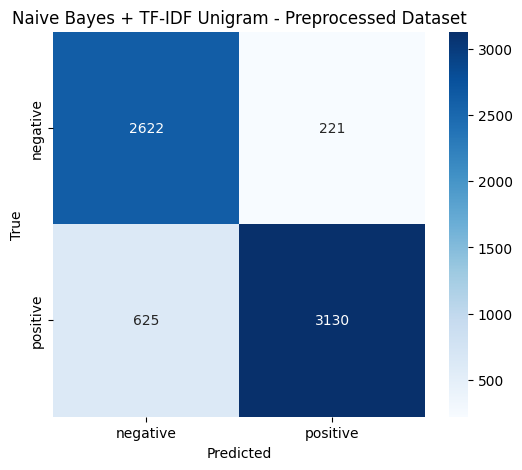

In [94]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sample_weights = np.array([class_weight_dict_tfidf[int(label)] for label in y_train_tfidf_enc])

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train_tfidf_enc, sample_weight=sample_weights)

y_val_pred_nb = nb_model.predict(X_val_vec)

print("=== NAIVE BAYES + TF-IDF (Unigram) - VALIDATION RESULTS ===")
print("Accuracy:", accuracy_score(y_val_tfidf_enc, y_val_pred_nb))
print("Weighted F1-score:", f1_score(y_val_tfidf_enc, y_val_pred_nb, average='weighted'))
print("\nClassification Report:\n", classification_report(y_val_tfidf_enc, y_val_pred_nb, target_names=le_tfidf.classes_))

cm_nb = confusion_matrix(y_val_tfidf_enc, y_val_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_tfidf.classes_, yticklabels=le_tfidf.classes_)
plt.title('Naive Bayes + TF-IDF Unigram - Preprocessed Dataset')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## **Naive Bayes with FastText on Preprocessed Dataset**

Raw TF-IDF label mapping:
0 = negative
1 = positive

Raw TF-IDF training shape: (52782, 10000)
Raw TF-IDF validation shape: (6598, 10000)

Raw TF-IDF class weights: {0: 1.1603499824129442, 1: 0.8785871229775618}
Sample weights created: 52782

Raw and preprocessed TF-IDF records are aligned.
Multinomial Naive Bayes training completed.

NAIVE BAYES + TF-IDF UNIGRAM - RAW DATASET VALIDATION
Accuracy: 0.8678387390118217
Weighted F1-score: 0.8684506505321135

Classification Report:

              precision    recall  f1-score   support

    negative       0.81      0.91      0.86      2843
    positive       0.93      0.83      0.88      3755

    accuracy                           0.87      6598
   macro avg       0.87      0.87      0.87      6598
weighted avg       0.87      0.87      0.87      6598



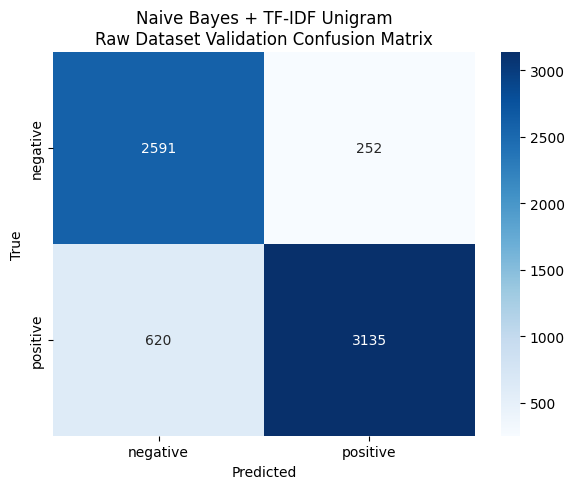

In [95]:
# ============================================================
# NAIVE BAYES WITH TF-IDF UNIGRAM ON RAW DATASET
# VALIDATION SET EVALUATION
# ============================================================


# ------------------------------------------------------------
# 1. Prepare raw training and validation text
# ------------------------------------------------------------

X_train_raw_tfidf_text = (
    raw_train["review_text"]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)

X_val_raw_tfidf_text = (
    raw_val["review_text"]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 2. Prepare raw training and validation labels
# ------------------------------------------------------------

y_train_raw_tfidf = (
    raw_train["rating_scale"]
    .astype(str)
    .str.strip()
    .str.lower()
    .reset_index(drop=True)
)

y_val_raw_tfidf = (
    raw_val["rating_scale"]
    .astype(str)
    .str.strip()
    .str.lower()
    .reset_index(drop=True)
)


# Use the existing TF-IDF label encoder
# Do not fit a new label encoder
y_train_raw_tfidf_enc = le_tfidf.transform(
    y_train_raw_tfidf
)

y_val_raw_tfidf_enc = le_tfidf.transform(
    y_val_raw_tfidf
)


print("Raw TF-IDF label mapping:")

for encoded_value, class_name in enumerate(
    le_tfidf.classes_
):
    print(
        f"{encoded_value} = {class_name}"
    )


# ------------------------------------------------------------
# 3. Create TF-IDF unigram representation
# ------------------------------------------------------------

raw_tfidf_unigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=10000,
    min_df=2
)


# Fit using raw training text only
X_train_raw_tfidf_unigram = (
    raw_tfidf_unigram_vectorizer.fit_transform(
        X_train_raw_tfidf_text
    )
)


# Transform validation text only
X_val_raw_tfidf_unigram = (
    raw_tfidf_unigram_vectorizer.transform(
        X_val_raw_tfidf_text
    )
)


print(
    "\nRaw TF-IDF training shape:",
    X_train_raw_tfidf_unigram.shape
)

print(
    "Raw TF-IDF validation shape:",
    X_val_raw_tfidf_unigram.shape
)


# ------------------------------------------------------------
# 4. Calculate class weights for this model only
# ------------------------------------------------------------

raw_tfidf_nb_classes = np.unique(
    y_train_raw_tfidf_enc
)


raw_tfidf_nb_weights = compute_class_weight(
    class_weight="balanced",
    classes=raw_tfidf_nb_classes,
    y=y_train_raw_tfidf_enc
)


raw_tfidf_nb_class_weight_dict = {
    int(class_id): float(class_weight)
    for class_id, class_weight in zip(
        raw_tfidf_nb_classes,
        raw_tfidf_nb_weights
    )
}


# Create one sample weight for every training record
raw_tfidf_nb_sample_weights = np.array(
    [
        raw_tfidf_nb_class_weight_dict[
            int(encoded_label)
        ]
        for encoded_label
        in y_train_raw_tfidf_enc
    ],
    dtype=np.float64
)


print(
    "\nRaw TF-IDF class weights:",
    raw_tfidf_nb_class_weight_dict
)

print(
    "Sample weights created:",
    len(raw_tfidf_nb_sample_weights)
)


# ------------------------------------------------------------
# 5. Safety checks
# ------------------------------------------------------------

assert (
    X_train_raw_tfidf_unigram.shape[0]
    == len(y_train_raw_tfidf_enc)
), (
    "Raw training features and labels "
    "have different record totals."
)

assert (
    X_train_raw_tfidf_unigram.shape[0]
    == len(raw_tfidf_nb_sample_weights)
), (
    "Raw training features and sample weights "
    "have different record totals."
)

assert (
    X_val_raw_tfidf_unigram.shape[0]
    == len(y_val_raw_tfidf_enc)
), (
    "Raw validation features and labels "
    "have different record totals."
)


# Check alignment with the preprocessed TF-IDF split
assert (
    raw_train["global_index_id"].tolist()
    == tfidf_train["global_index_id"].tolist()
), (
    "Raw and preprocessed TF-IDF training "
    "records are not aligned."
)

assert (
    raw_val["global_index_id"].tolist()
    == tfidf_val["global_index_id"].tolist()
), (
    "Raw and preprocessed TF-IDF validation "
    "records are not aligned."
)


print(
    "\nRaw and preprocessed TF-IDF records "
    "are aligned."
)


# ------------------------------------------------------------
# 6. Train Multinomial Naive Bayes
# ------------------------------------------------------------

raw_tfidf_nb_model = MultinomialNB()


raw_tfidf_nb_model.fit(
    X_train_raw_tfidf_unigram,
    y_train_raw_tfidf_enc,
    sample_weight=raw_tfidf_nb_sample_weights
)


print(
    "Multinomial Naive Bayes training completed."
)


# ------------------------------------------------------------
# 7. Predict the validation set
# ------------------------------------------------------------

y_val_pred_raw_tfidf_nb = (
    raw_tfidf_nb_model.predict(
        X_val_raw_tfidf_unigram
    )
)


# ------------------------------------------------------------
# 8. Calculate validation results
# ------------------------------------------------------------

raw_tfidf_nb_accuracy = accuracy_score(
    y_val_raw_tfidf_enc,
    y_val_pred_raw_tfidf_nb
)


raw_tfidf_nb_weighted_f1 = f1_score(
    y_val_raw_tfidf_enc,
    y_val_pred_raw_tfidf_nb,
    average="weighted",
    zero_division=0
)


print(
    "\n"
    + "=" * 65
)

print(
    "NAIVE BAYES + TF-IDF UNIGRAM "
    "- RAW DATASET VALIDATION"
)

print(
    "=" * 65
)


print(
    "Accuracy:",
    raw_tfidf_nb_accuracy
)

print(
    "Weighted F1-score:",
    raw_tfidf_nb_weighted_f1
)


print(
    "\nClassification Report:\n"
)


print(
    classification_report(
        y_val_raw_tfidf_enc,
        y_val_pred_raw_tfidf_nb,
        labels=np.arange(
            len(le_tfidf.classes_)
        ),
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 9. Display confusion matrix
# ------------------------------------------------------------

raw_tfidf_nb_confusion_matrix = (
    confusion_matrix(
        y_val_raw_tfidf_enc,
        y_val_pred_raw_tfidf_nb,
        labels=np.arange(
            len(le_tfidf.classes_)
        )
    )
)


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(
    raw_tfidf_nb_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)


plt.title(
    "Naive Bayes + TF-IDF Unigram\n"
    "Raw Dataset Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

## **Naive Bayes with TF-IDF on Raw Dataset**

## **Naive Bayes with FastText on Raw Dataset**

## **Prepare GloVe Document Vector**

In [96]:
import gensim.downloader as api
import numpy as np

print("Loading GloVe...")

glove_model = api.load(
    "glove-wiki-gigaword-300"
)

print("GloVe loaded successfully.")
print("GloVe vector size:", glove_model.vector_size)

Loading GloVe...
[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe loaded successfully.
GloVe vector size: 300


In [97]:
def create_glove_document_vectors(text_series):
    document_vectors = []

    for text in text_series.astype(str):
        words = text.lower().split()

        available_vectors = [
            glove_model[word]
            for word in words
            if word in glove_model.key_to_index
        ]

        if available_vectors:
            document_vector = np.mean(
                available_vectors,
                axis=0
            )
        else:
            document_vector = np.zeros(
                glove_model.vector_size,
                dtype=np.float32
            )

        document_vectors.append(
            document_vector
        )

    return np.asarray(
        document_vectors,
        dtype=np.float32
    )


X_train_glove = create_glove_document_vectors(
    X_train_emb
)

X_val_glove = create_glove_document_vectors(
    X_val_emb
)

print(
    "GloVe training shape:",
    X_train_glove.shape
)

print(
    "GloVe validation shape:",
    X_val_glove.shape
)

GloVe training shape: (52782, 300)
GloVe validation shape: (6598, 300)


## **Naive Bayes + TF-IDF (Unigram + Bigram)**

=== NAIVE BAYES + TF-IDF UNIGRAM + BIGRAM - VALIDATION RESULTS ===
Accuracy: 0.8901182176417096
Weighted F1-score: 0.8905832919249561

Classification Report:

              precision    recall  f1-score   support

    negative       0.84      0.92      0.88      2843
    positive       0.94      0.86      0.90      3755

    accuracy                           0.89      6598
   macro avg       0.89      0.89      0.89      6598
weighted avg       0.89      0.89      0.89      6598



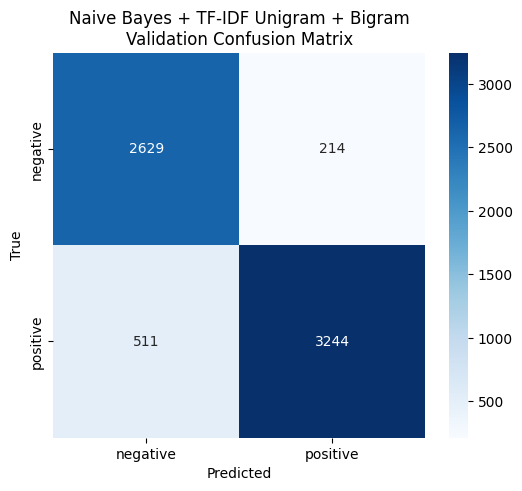

In [98]:
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Select TF-IDF Unigram + Bigram features
X_train_vec_nb_ub = (
    tfidf_vectors["unigram_bigram"]["X_train"]
)

X_val_vec_nb_ub = (
    tfidf_vectors["unigram_bigram"]["X_val"]
)


# Create training sample weights
sample_weights_nb_ub = np.array([
    class_weight_dict_tfidf[int(label)]
    for label in y_train_tfidf_enc
])


# Create and train model
nb_ub_model = MultinomialNB()

nb_ub_model.fit(
    X_train_vec_nb_ub,
    y_train_tfidf_enc,
    sample_weight=sample_weights_nb_ub
)


# Predict validation set
y_val_pred_nb_ub = nb_ub_model.predict(
    X_val_vec_nb_ub
)


# Validation evaluation
print(
    "=== NAIVE BAYES + TF-IDF "
    "UNIGRAM + BIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_nb_ub
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_nb_ub,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_nb_ub,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


# Validation confusion matrix
cm_nb_ub = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_nb_ub
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb_ub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "Naive Bayes + TF-IDF Unigram + Bigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Naive Bayes + TF-IDF (Unigram + Bigram + Trigram)**

=== NAIVE BAYES + TF-IDF UNIGRAM + BIGRAM + TRIGRAM - VALIDATION RESULTS ===
Accuracy: 0.888299484692331
Weighted F1-score: 0.888760412196682

Classification Report:

              precision    recall  f1-score   support

    negative       0.84      0.92      0.88      2843
    positive       0.93      0.86      0.90      3755

    accuracy                           0.89      6598
   macro avg       0.89      0.89      0.89      6598
weighted avg       0.89      0.89      0.89      6598



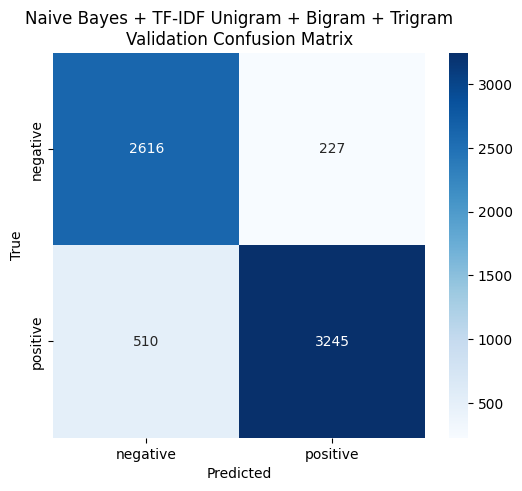

In [99]:
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


X_train_vec_nb_ubt = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_train"]
)

X_val_vec_nb_ubt = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_val"]
)


sample_weights_nb_ubt = np.array([
    class_weight_dict_tfidf[int(label)]
    for label in y_train_tfidf_enc
])


nb_ubt_model = MultinomialNB()

nb_ubt_model.fit(
    X_train_vec_nb_ubt,
    y_train_tfidf_enc,
    sample_weight=sample_weights_nb_ubt
)


y_val_pred_nb_ubt = nb_ubt_model.predict(
    X_val_vec_nb_ubt
)


print(
    "=== NAIVE BAYES + TF-IDF UNIGRAM + "
    "BIGRAM + TRIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_nb_ubt
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_nb_ubt,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_nb_ubt,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_nb_ubt = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_nb_ubt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb_ubt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "Naive Bayes + TF-IDF Unigram + Bigram + Trigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Naive Bayes + Word2Vec**

=== NAIVE BAYES + WORD2VEC - VALIDATION RESULTS ===
Accuracy: 0.7027887238557139
Weighted F1-score: 0.6991096750971001

Classification Report:

              precision    recall  f1-score   support

    negative       0.61      0.89      0.72      2843
    positive       0.87      0.56      0.68      3755

    accuracy                           0.70      6598
   macro avg       0.74      0.73      0.70      6598
weighted avg       0.76      0.70      0.70      6598



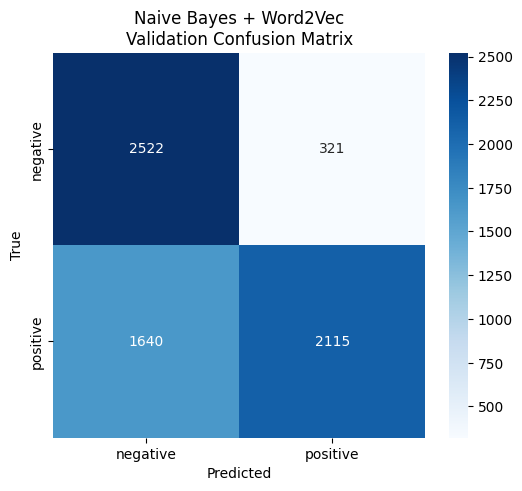

In [100]:
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


sample_weights_nb_w2v = np.array([
    class_weight_dict_emb[int(label)]
    for label in y_train_emb_enc
])


nb_w2v_model = GaussianNB()

nb_w2v_model.fit(
    X_train_w2v,
    y_train_emb_enc,
    sample_weight=sample_weights_nb_w2v
)


y_val_pred_nb_w2v = nb_w2v_model.predict(
    X_val_w2v
)


print(
    "=== NAIVE BAYES + WORD2VEC "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_nb_w2v
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_nb_w2v,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_nb_w2v,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_nb_w2v = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_nb_w2v
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb_w2v,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "Naive Bayes + Word2Vec\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Naive Bayes + GloVe**

=== NAIVE BAYES + GLOVE - VALIDATION RESULTS ===
Accuracy: 0.6309487723552591
Weighted F1-score: 0.6199676096720875

Classification Report:

              precision    recall  f1-score   support

    negative       0.55      0.87      0.67      2843
    positive       0.82      0.45      0.58      3755

    accuracy                           0.63      6598
   macro avg       0.68      0.66      0.63      6598
weighted avg       0.70      0.63      0.62      6598



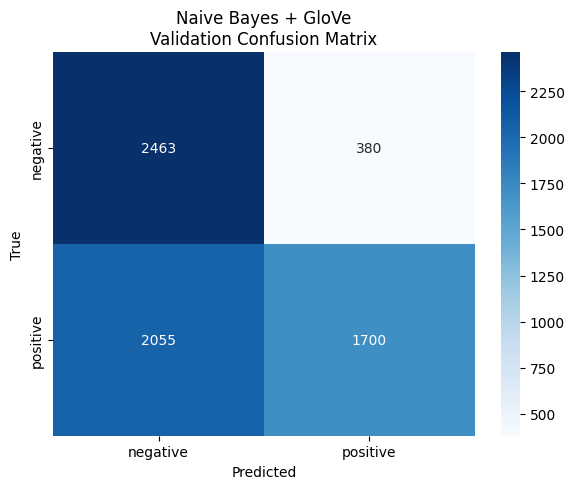

In [101]:
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


sample_weights_nb_glove = np.array([
    class_weight_dict_emb[int(label)]
    for label in y_train_emb_enc
])


nb_glove_model = GaussianNB()

nb_glove_model.fit(
    X_train_glove,
    y_train_emb_enc,
    sample_weight=sample_weights_nb_glove
)


y_val_pred_nb_glove = nb_glove_model.predict(
    X_val_glove
)


print(
    "=== NAIVE BAYES + GLOVE "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_nb_glove
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_nb_glove,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_nb_glove,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_nb_glove = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_nb_glove
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb_glove,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "Naive Bayes + GloVe\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## **Logistic Regression + TF-IDF (Unigram)**

=== LOGISTIC REGRESSION + TF-IDF UNIGRAM - VALIDATION RESULTS ===
Accuracy: 0.8970900272809943
Weighted F1-score: 0.8974244884629882

Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.91      0.88      2843
    positive       0.93      0.88      0.91      3755

    accuracy                           0.90      6598
   macro avg       0.89      0.90      0.90      6598
weighted avg       0.90      0.90      0.90      6598



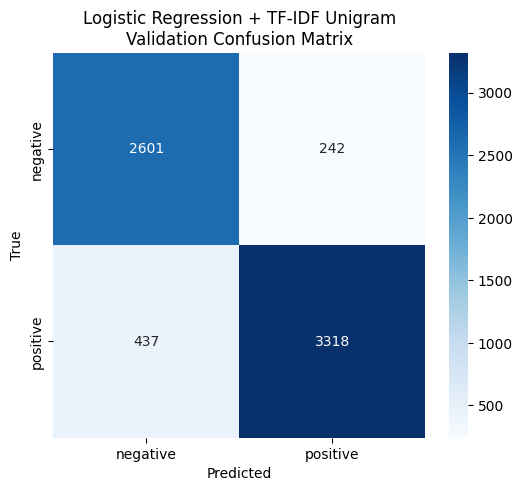

In [102]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


X_train_vec_lr_uni = (
    tfidf_vectors["unigram"]["X_train"]
)

X_val_vec_lr_uni = (
    tfidf_vectors["unigram"]["X_val"]
)


lr_uni_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight=class_weight_dict_tfidf,
    random_state=42,
    n_jobs=-1
)


lr_uni_model.fit(
    X_train_vec_lr_uni,
    y_train_tfidf_enc
)


y_val_pred_lr_uni = lr_uni_model.predict(
    X_val_vec_lr_uni
)


print(
    "=== LOGISTIC REGRESSION + TF-IDF "
    "UNIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_lr_uni
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_lr_uni,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_lr_uni,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_lr_uni = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_lr_uni
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_uni,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "Logistic Regression + TF-IDF Unigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Logistic Regression + TF-IDF (Unigram + Bigram)**

=== LOGISTIC REGRESSION + TF-IDF UNIGRAM + BIGRAM - VALIDATION RESULTS ===
Accuracy: 0.9042133979993937
Weighted F1-score: 0.9045457797157286

Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.93      0.89      2843
    positive       0.94      0.89      0.91      3755

    accuracy                           0.90      6598
   macro avg       0.90      0.91      0.90      6598
weighted avg       0.91      0.90      0.90      6598



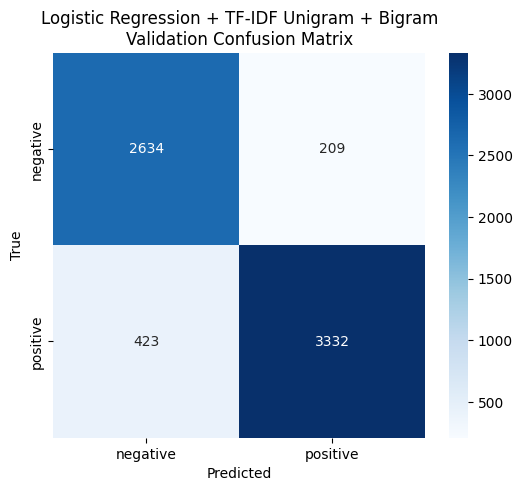

In [103]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


X_train_vec_lr_ub = (
    tfidf_vectors["unigram_bigram"]["X_train"]
)

X_val_vec_lr_ub = (
    tfidf_vectors["unigram_bigram"]["X_val"]
)


lr_ub_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight=class_weight_dict_tfidf,
    random_state=42,
    n_jobs=-1
)


lr_ub_model.fit(
    X_train_vec_lr_ub,
    y_train_tfidf_enc
)


y_val_pred_lr_ub = lr_ub_model.predict(
    X_val_vec_lr_ub
)


print(
    "=== LOGISTIC REGRESSION + TF-IDF "
    "UNIGRAM + BIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_lr_ub
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_lr_ub,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_lr_ub,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_lr_ub = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_lr_ub
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_ub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "Logistic Regression + TF-IDF Unigram + Bigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Logistic Regression + TF-IDF (Unigram + Bigram + Trigram)**

=== LOGISTIC REGRESSION + TF-IDF UNIGRAM + BIGRAM + TRIGRAM - VALIDATION RESULTS ===
Accuracy: 0.9049712033949682
Weighted F1-score: 0.905295610743138

Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.93      0.89      2843
    positive       0.94      0.89      0.91      3755

    accuracy                           0.90      6598
   macro avg       0.90      0.91      0.90      6598
weighted avg       0.91      0.90      0.91      6598



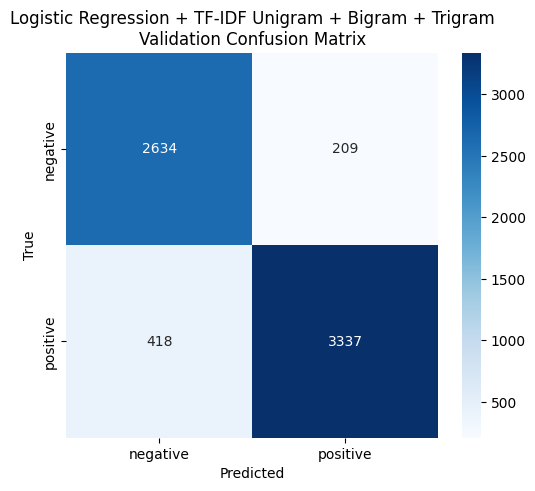

In [104]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


X_train_vec_lr_ubt = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_train"]
)

X_val_vec_lr_ubt = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_val"]
)


lr_ubt_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight=class_weight_dict_tfidf,
    random_state=42,
    n_jobs=-1
)


lr_ubt_model.fit(
    X_train_vec_lr_ubt,
    y_train_tfidf_enc
)


y_val_pred_lr_ubt = lr_ubt_model.predict(
    X_val_vec_lr_ubt
)


print(
    "=== LOGISTIC REGRESSION + TF-IDF "
    "UNIGRAM + BIGRAM + TRIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_lr_ubt
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_lr_ubt,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_lr_ubt,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_lr_ubt = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_lr_ubt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_ubt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "Logistic Regression + TF-IDF "
    "Unigram + Bigram + Trigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Logistic Regression + FastText**

=== LOGISTIC REGRESSION + FASTTEXT - VALIDATION RESULTS ===
Accuracy: 0.876629281600485
Weighted F1-score: 0.8771541045205892

Classification Report:

              precision    recall  f1-score   support

    negative       0.82      0.91      0.86      2843
    positive       0.93      0.85      0.89      3755

    accuracy                           0.88      6598
   macro avg       0.87      0.88      0.88      6598
weighted avg       0.88      0.88      0.88      6598



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


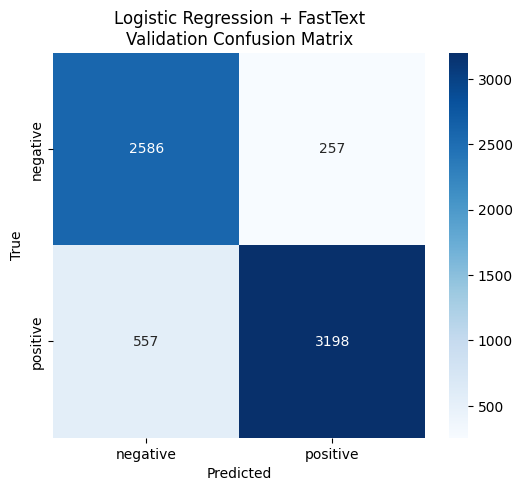

In [105]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


lr_ft_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight=class_weight_dict_emb,
    random_state=42,
    n_jobs=-1
)


lr_ft_model.fit(
    X_train_ft,
    y_train_emb_enc
)


y_val_pred_lr_ft = lr_ft_model.predict(
    X_val_ft
)


print(
    "=== LOGISTIC REGRESSION + FASTTEXT "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_lr_ft
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_lr_ft,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_lr_ft,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_lr_ft = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_lr_ft
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "Logistic Regression + FastText\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Logistic Regression + Word2Vec**

=== LOGISTIC REGRESSION + WORD2VEC - VALIDATION RESULTS ===
Accuracy: 0.8866323128220673
Weighted F1-score: 0.8871253477803026

Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.92      0.88      2843
    positive       0.94      0.86      0.90      3755

    accuracy                           0.89      6598
   macro avg       0.88      0.89      0.89      6598
weighted avg       0.89      0.89      0.89      6598



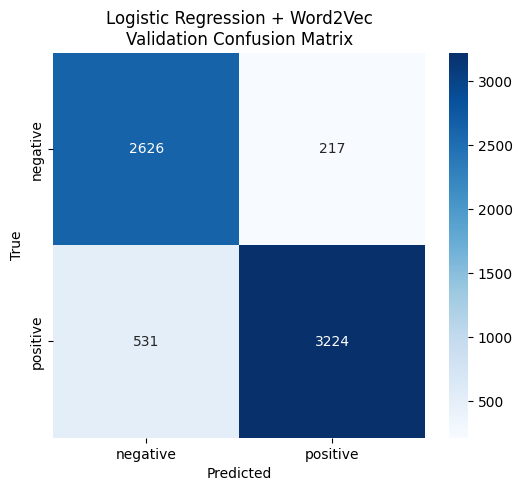

In [106]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


lr_w2v_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight=class_weight_dict_emb,
    random_state=42,
    n_jobs=-1
)


lr_w2v_model.fit(
    X_train_w2v,
    y_train_emb_enc
)


y_val_pred_lr_w2v = lr_w2v_model.predict(
    X_val_w2v
)


print(
    "=== LOGISTIC REGRESSION + WORD2VEC "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_lr_w2v
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_lr_w2v,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_lr_w2v,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_lr_w2v = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_lr_w2v
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_w2v,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "Logistic Regression + Word2Vec\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Logistic Regression + GloVe**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== LOGISTIC REGRESSION + GLOVE - VALIDATION RESULTS ===
Accuracy: 0.8552591694452865
Weighted F1-score: 0.8559342046149029

Classification Report:

              precision    recall  f1-score   support

    negative       0.79      0.90      0.84      2843
    positive       0.91      0.82      0.87      3755

    accuracy                           0.86      6598
   macro avg       0.85      0.86      0.85      6598
weighted avg       0.86      0.86      0.86      6598



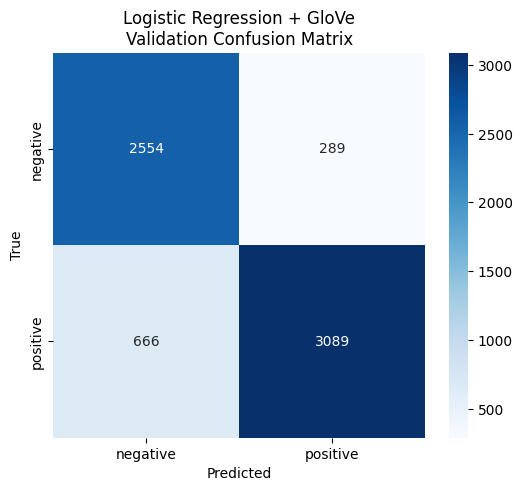

In [107]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


lr_glove_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight=class_weight_dict_emb,
    random_state=42,
    n_jobs=-1
)


lr_glove_model.fit(
    X_train_glove,
    y_train_emb_enc
)


y_val_pred_lr_glove = lr_glove_model.predict(
    X_val_glove
)


print(
    "=== LOGISTIC REGRESSION + GLOVE "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_lr_glove
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_lr_glove,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_lr_glove,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_lr_glove = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_lr_glove
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_glove,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "Logistic Regression + GloVe\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **SVM + TF-IDF (Unigram)**

=== SVM + TF-IDF UNIGRAM - VALIDATION RESULTS ===
Accuracy: 0.8910275841163989
Weighted F1-score: 0.8913683868024601

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.91      0.88      2843
    positive       0.93      0.88      0.90      3755

    accuracy                           0.89      6598
   macro avg       0.89      0.89      0.89      6598
weighted avg       0.89      0.89      0.89      6598



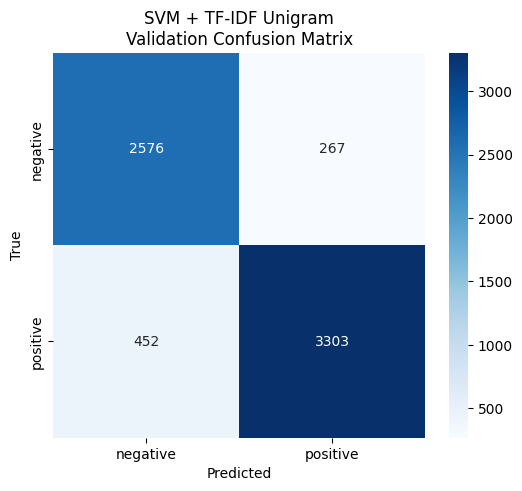

In [108]:
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


X_train_vec_svm_uni = (
    tfidf_vectors["unigram"]["X_train"]
)

X_val_vec_svm_uni = (
    tfidf_vectors["unigram"]["X_val"]
)


svm_uni_model = LinearSVC(
    C=1.0,
    class_weight=class_weight_dict_tfidf,
    dual=False,
    max_iter=5000,
    random_state=42
)


svm_uni_model.fit(
    X_train_vec_svm_uni,
    y_train_tfidf_enc
)


y_val_pred_svm_uni = svm_uni_model.predict(
    X_val_vec_svm_uni
)


print(
    "=== SVM + TF-IDF UNIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_svm_uni
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_svm_uni,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_svm_uni,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_svm_uni = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_svm_uni
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_uni,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "SVM + TF-IDF Unigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **SVM + TF-IDF (Unigram + Bigram)**

=== SVM + TF-IDF UNIGRAM + BIGRAM - VALIDATION RESULTS ===
Accuracy: 0.8990603213094878
Weighted F1-score: 0.8993670550581517

Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.91      0.89      2843
    positive       0.93      0.89      0.91      3755

    accuracy                           0.90      6598
   macro avg       0.90      0.90      0.90      6598
weighted avg       0.90      0.90      0.90      6598



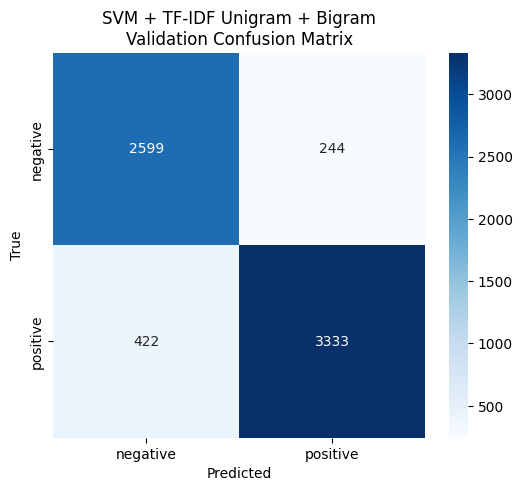

In [109]:
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


X_train_vec_svm_ub = (
    tfidf_vectors["unigram_bigram"]["X_train"]
)

X_val_vec_svm_ub = (
    tfidf_vectors["unigram_bigram"]["X_val"]
)


svm_ub_model = LinearSVC(
    C=1.0,
    class_weight=class_weight_dict_tfidf,
    dual=False,
    max_iter=5000,
    random_state=42
)


svm_ub_model.fit(
    X_train_vec_svm_ub,
    y_train_tfidf_enc
)


y_val_pred_svm_ub = svm_ub_model.predict(
    X_val_vec_svm_ub
)


print(
    "=== SVM + TF-IDF UNIGRAM + BIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_svm_ub
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_svm_ub,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_svm_ub,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_svm_ub = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_svm_ub
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_ub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "SVM + TF-IDF Unigram + Bigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **SVM + TF-IDF (Unigram + Bigram + Trigram)**

=== SVM + TF-IDF UNIGRAM + BIGRAM + TRIGRAM - VALIDATION RESULTS ===
Accuracy: 0.8978478326765686
Weighted F1-score: 0.8981225467391057

Classification Report:

              precision    recall  f1-score   support

    negative       0.86      0.91      0.88      2843
    positive       0.93      0.89      0.91      3755

    accuracy                           0.90      6598
   macro avg       0.89      0.90      0.90      6598
weighted avg       0.90      0.90      0.90      6598



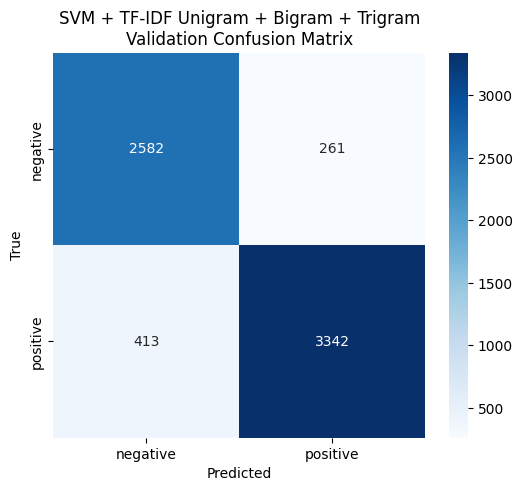

In [110]:
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


X_train_vec_svm_ubt = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_train"]
)

X_val_vec_svm_ubt = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_val"]
)


svm_ubt_model = LinearSVC(
    C=1.0,
    class_weight=class_weight_dict_tfidf,
    dual=False,
    max_iter=5000,
    random_state=42
)


svm_ubt_model.fit(
    X_train_vec_svm_ubt,
    y_train_tfidf_enc
)


y_val_pred_svm_ubt = svm_ubt_model.predict(
    X_val_vec_svm_ubt
)


print(
    "=== SVM + TF-IDF UNIGRAM + BIGRAM + "
    "TRIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_svm_ubt
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_svm_ubt,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_svm_ubt,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_svm_ubt = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_svm_ubt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_ubt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "SVM + TF-IDF Unigram + Bigram + Trigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **SVM + FastText**

=== SVM + FASTTEXT - VALIDATION RESULTS ===
Accuracy: 0.874052743255532
Weighted F1-score: 0.874614882907239

Classification Report:

              precision    recall  f1-score   support

    negative       0.82      0.91      0.86      2843
    positive       0.93      0.85      0.88      3755

    accuracy                           0.87      6598
   macro avg       0.87      0.88      0.87      6598
weighted avg       0.88      0.87      0.87      6598



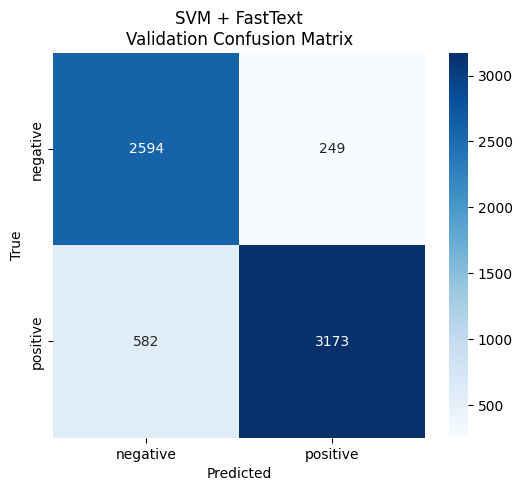

In [111]:
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


svm_ft_model = LinearSVC(
    C=1.0,
    class_weight=class_weight_dict_emb,
    dual=False,
    max_iter=5000,
    random_state=42
)


svm_ft_model.fit(
    X_train_ft,
    y_train_emb_enc
)


y_val_pred_svm_ft = svm_ft_model.predict(
    X_val_ft
)


print(
    "=== SVM + FASTTEXT "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_svm_ft
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_svm_ft,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_svm_ft,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_svm_ft = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_svm_ft
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "SVM + FastText\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **SVM + Word2Vec**

=== SVM + WORD2VEC - VALIDATION RESULTS ===
Accuracy: 0.8852682631100334
Weighted F1-score: 0.8857708679242957

Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.92      0.87      2843
    positive       0.94      0.86      0.89      3755

    accuracy                           0.89      6598
   macro avg       0.88      0.89      0.88      6598
weighted avg       0.89      0.89      0.89      6598



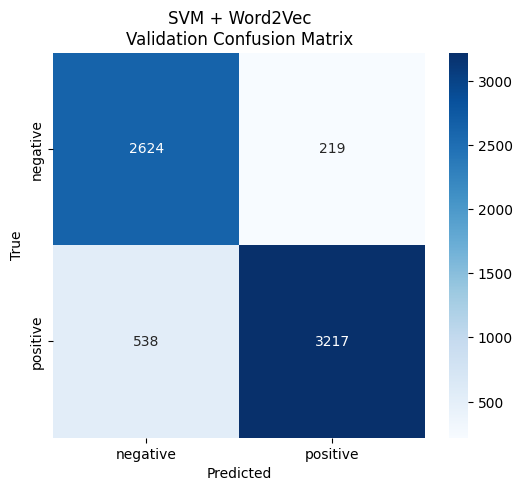

In [112]:
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


svm_w2v_model = LinearSVC(
    C=1.0,
    class_weight=class_weight_dict_emb,
    dual=False,
    max_iter=5000,
    random_state=42
)


svm_w2v_model.fit(
    X_train_w2v,
    y_train_emb_enc
)


y_val_pred_svm_w2v = svm_w2v_model.predict(
    X_val_w2v
)


print(
    "=== SVM + WORD2VEC "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_svm_w2v
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_svm_w2v,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_svm_w2v,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_svm_w2v = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_svm_w2v
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_w2v,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "SVM + Word2Vec\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **SVM + GloVe**

=== SVM + GLOVE - VALIDATION RESULTS ===
Accuracy: 0.8494998484389209
Weighted F1-score: 0.850219686677843

Classification Report:

              precision    recall  f1-score   support

    negative       0.78      0.90      0.84      2843
    positive       0.91      0.81      0.86      3755

    accuracy                           0.85      6598
   macro avg       0.85      0.86      0.85      6598
weighted avg       0.86      0.85      0.85      6598



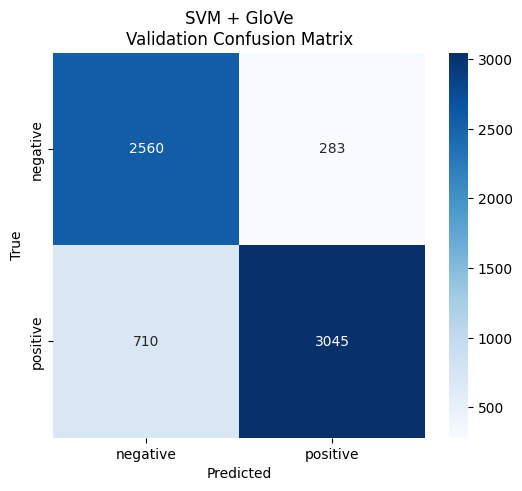

In [113]:
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


svm_glove_model = LinearSVC(
    C=1.0,
    class_weight=class_weight_dict_emb,
    dual=False,
    max_iter=5000,
    random_state=42
)


svm_glove_model.fit(
    X_train_glove,
    y_train_emb_enc
)


y_val_pred_svm_glove = svm_glove_model.predict(
    X_val_glove
)


print(
    "=== SVM + GLOVE "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_svm_glove
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_svm_glove,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_svm_glove,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_svm_glove = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_svm_glove
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm_glove,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "SVM + GloVe\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **Deep-Learning Preparation**

In [114]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

import numpy as np


SVD_COMPONENTS = 300


def prepare_tfidf_deep_learning_data(
    X_train_sparse,
    X_val_sparse
):
    number_of_components = min(
        SVD_COMPONENTS,
        X_train_sparse.shape[0] - 1,
        X_train_sparse.shape[1] - 1
    )

    reducer = make_pipeline(
        TruncatedSVD(
            n_components=number_of_components,
            random_state=42
        ),
        Normalizer(copy=False)
    )

    X_train_reduced = reducer.fit_transform(
        X_train_sparse
    ).astype(np.float32)

    X_val_reduced = reducer.transform(
        X_val_sparse
    ).astype(np.float32)

    X_train_reduced = (
        X_train_reduced[..., np.newaxis]
    )

    X_val_reduced = (
        X_val_reduced[..., np.newaxis]
    )

    return (
        X_train_reduced,
        X_val_reduced,
        reducer
    )

In [115]:
# TF-IDF Unigram

(
    X_train_tfidf_uni_dl,
    X_val_tfidf_uni_dl,
    svd_tfidf_uni
) = prepare_tfidf_deep_learning_data(
    tfidf_vectors["unigram"]["X_train"],
    tfidf_vectors["unigram"]["X_val"]
)

print(
    "Unigram DL training shape:",
    X_train_tfidf_uni_dl.shape
)

print(
    "Unigram DL validation shape:",
    X_val_tfidf_uni_dl.shape
)

Unigram DL training shape: (52782, 300, 1)
Unigram DL validation shape: (6598, 300, 1)


In [116]:
# TF-IDF Unigram + Bigram

(
    X_train_tfidf_ub_dl,
    X_val_tfidf_ub_dl,
    svd_tfidf_ub
) = prepare_tfidf_deep_learning_data(
    tfidf_vectors["unigram_bigram"]["X_train"],
    tfidf_vectors["unigram_bigram"]["X_val"]
)

print(
    "Unigram + Bigram DL training shape:",
    X_train_tfidf_ub_dl.shape
)

print(
    "Unigram + Bigram DL validation shape:",
    X_val_tfidf_ub_dl.shape
)

Unigram + Bigram DL training shape: (52782, 300, 1)
Unigram + Bigram DL validation shape: (6598, 300, 1)


In [117]:
# TF-IDF Unigram + Bigram + Trigram

(
    X_train_tfidf_ubt_dl,
    X_val_tfidf_ubt_dl,
    svd_tfidf_ubt
) = prepare_tfidf_deep_learning_data(
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_train"],
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_val"]
)

print(
    "Unigram + Bigram + Trigram "
    "DL training shape:",
    X_train_tfidf_ubt_dl.shape
)

print(
    "Unigram + Bigram + Trigram "
    "DL validation shape:",
    X_val_tfidf_ubt_dl.shape
)

Unigram + Bigram + Trigram DL training shape: (52782, 300, 1)
Unigram + Bigram + Trigram DL validation shape: (6598, 300, 1)


In [118]:
# PREPARE TOKEN SEQUENCES FOR EMBEDDING MODELS

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_VOCAB_SIZE = 30000
MAX_SEQUENCE_LENGTH = 100


embedding_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)


# Fit tokenizer using training reviews only
embedding_tokenizer.fit_on_texts(
    X_train_emb.astype(str).tolist()
)


X_train_sequence = (
    embedding_tokenizer.texts_to_sequences(
        X_train_emb.astype(str).tolist()
    )
)

X_val_sequence = (
    embedding_tokenizer.texts_to_sequences(
        X_val_emb.astype(str).tolist()
    )
)


X_train_sequence = pad_sequences(
    X_train_sequence,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_sequence = pad_sequences(
    X_val_sequence,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)


VOCAB_SIZE = min(
    MAX_VOCAB_SIZE,
    len(embedding_tokenizer.word_index) + 1
)


print("Vocabulary size:", VOCAB_SIZE)

print(
    "Training sequence shape:",
    X_train_sequence.shape
)

print(
    "Validation sequence shape:",
    X_val_sequence.shape
)

Vocabulary size: 25177
Training sequence shape: (52782, 100)
Validation sequence shape: (6598, 100)


In [119]:
# FASTTEXT EMBEDDING MATRIX

import numpy as np


FASTTEXT_VECTOR_SIZE = (
    fasttext_model.wv.vector_size
)


fasttext_embedding_matrix = np.zeros(
    (
        VOCAB_SIZE,
        FASTTEXT_VECTOR_SIZE
    ),
    dtype=np.float32
)


for word, word_index in (
    embedding_tokenizer.word_index.items()
):
    if word_index >= VOCAB_SIZE:
        continue

    try:
        fasttext_embedding_matrix[
            word_index
        ] = fasttext_model.wv.get_vector(word)

    except KeyError:
        pass


print(
    "FastText embedding matrix shape:",
    fasttext_embedding_matrix.shape
)

FastText embedding matrix shape: (25177, 300)


In [120]:
# WORD2VEC EMBEDDING MATRIX

import numpy as np


WORD2VEC_VECTOR_SIZE = (
    word2vec_model.wv.vector_size
)


word2vec_embedding_matrix = np.zeros(
    (
        VOCAB_SIZE,
        WORD2VEC_VECTOR_SIZE
    ),
    dtype=np.float32
)


for word, word_index in (
    embedding_tokenizer.word_index.items()
):
    if word_index >= VOCAB_SIZE:
        continue

    if word in word2vec_model.wv.key_to_index:
        word2vec_embedding_matrix[
            word_index
        ] = word2vec_model.wv[word]


print(
    "Word2Vec embedding matrix shape:",
    word2vec_embedding_matrix.shape
)

Word2Vec embedding matrix shape: (25177, 300)


In [121]:
# GLOVE EMBEDDING MATRIX

import numpy as np


GLOVE_VECTOR_SIZE = glove_model.vector_size


glove_embedding_matrix = np.zeros(
    (
        VOCAB_SIZE,
        GLOVE_VECTOR_SIZE
    ),
    dtype=np.float32
)


for word, word_index in (
    embedding_tokenizer.word_index.items()
):
    if word_index >= VOCAB_SIZE:
        continue

    if word in glove_model.key_to_index:
        glove_embedding_matrix[
            word_index
        ] = glove_model[word]


print(
    "GloVe embedding matrix shape:",
    glove_embedding_matrix.shape
)

GloVe embedding matrix shape: (25177, 300)


## **LSTM + TF-IDF (Unigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4985 - loss: 0.6932 - val_accuracy: 0.5693 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5048 - loss: 0.6931 - val_accuracy: 0.4348 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5267 - loss: 0.6917 - val_accuracy: 0.5587 - val_loss: 0.6905 - learning_rate: 5.0000e-04
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5541 - loss: 0.6901 - val_accuracy: 0.5767 - val_loss: 0.6905 - learning_rate: 5.0000e-04
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5627 - loss: 0.6893 - val_accuracy: 0.5762 - val_loss: 0.6885 - learning_rate: 2.5000e-04
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5721 - loss: 0.6858 - val_accuracy: 0.5914 - val_loss: 0.6829 - learning_rate: 2.5000e-04
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 

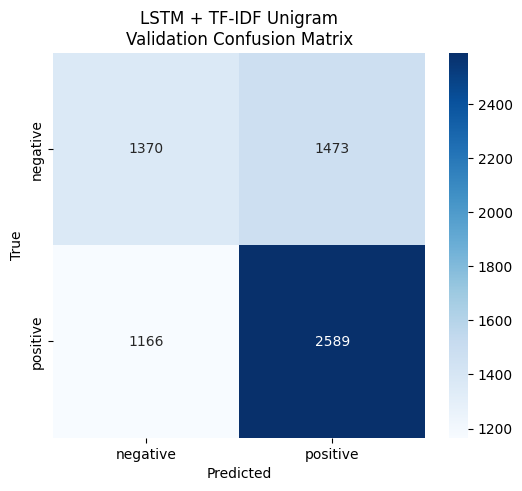

In [122]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


lstm_tfidf_uni_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_uni_dl.shape[1],
            1
        )
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


lstm_tfidf_uni_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


lstm_tfidf_uni_history = (
    lstm_tfidf_uni_model.fit(
        X_train_tfidf_uni_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_uni_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_lstm_tfidf_uni = np.argmax(
    lstm_tfidf_uni_model.predict(
        X_val_tfidf_uni_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== LSTM + TF-IDF UNIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_uni
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_uni,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_uni,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_lstm_tfidf_uni = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_lstm_tfidf_uni
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm_tfidf_uni,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "LSTM + TF-IDF Unigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **LSTM + TF-IDF (Unigram + Bigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5032 - loss: 0.6932 - val_accuracy: 0.4309 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5140 - loss: 0.6931 - val_accuracy: 0.4706 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5487 - loss: 0.6895 - val_accuracy: 0.5715 - val_loss: 0.6860 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5657 - loss: 0.6867 - val_accuracy: 0.5865 - val_loss: 0.6817 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5695 - loss: 0.6846 - val_accuracy: 0.5750 - val_loss: 0.6838 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5747 - loss: 0.6818 - val_accuracy: 0.5741 - val_loss: 0.6796 - learning_rate: 5.0000e-04
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5571 - loss

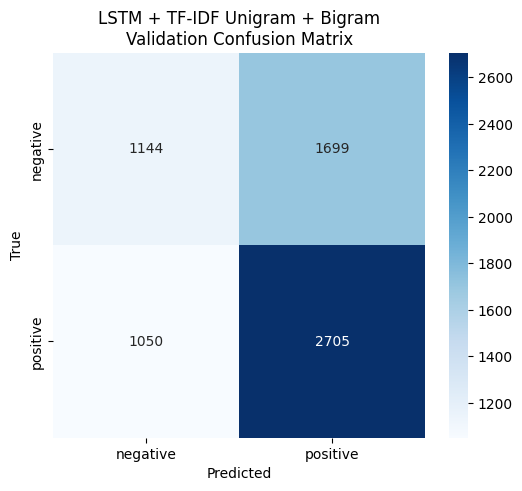

In [123]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


lstm_tfidf_ub_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_ub_dl.shape[1],
            1
        )
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


lstm_tfidf_ub_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


lstm_tfidf_ub_history = (
    lstm_tfidf_ub_model.fit(
        X_train_tfidf_ub_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_ub_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_lstm_tfidf_ub = np.argmax(
    lstm_tfidf_ub_model.predict(
        X_val_tfidf_ub_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== LSTM + TF-IDF UNIGRAM + BIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_ub
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_ub,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_ub,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_lstm_tfidf_ub = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_lstm_tfidf_ub
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm_tfidf_ub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "LSTM + TF-IDF Unigram + Bigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **LSTM + TF-IDF (Unigram + Bigram + Trigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5102 - loss: 0.6933 - val_accuracy: 0.5691 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5023 - loss: 0.6933 - val_accuracy: 0.4326 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5099 - loss: 0.6931 - val_accuracy: 0.4338 - val_loss: 0.6944 - learning_rate: 5.0000e-04
=== LSTM + TF-IDF UNIGRAM + BIGRAM + TRIGRAM - VALIDATION RESULTS ===
Accuracy: 0.5691118520763868
Weighted F1-score: 0.41310281104655344

Classification Report:

              precision    recall  f1-score   support

    negative       0.50      0.00      0.00      2843
    positive       0.57      1.00      0.73      3755

    accuracy                           0.57      6598
   macro avg       0.53      0.50      0.36      6598
weighted avg       0.54      0.57      0.41      6598



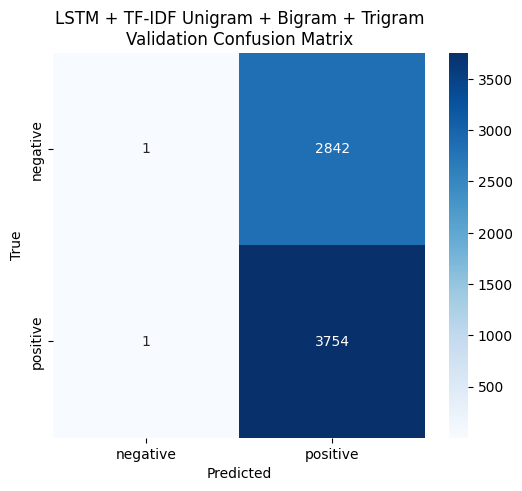

In [124]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


lstm_tfidf_ubt_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_ubt_dl.shape[1],
            1
        )
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


lstm_tfidf_ubt_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


lstm_tfidf_ubt_history = (
    lstm_tfidf_ubt_model.fit(
        X_train_tfidf_ubt_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_ubt_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_lstm_tfidf_ubt = np.argmax(
    lstm_tfidf_ubt_model.predict(
        X_val_tfidf_ubt_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== LSTM + TF-IDF UNIGRAM + BIGRAM + "
    "TRIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_ubt
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_ubt,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_lstm_tfidf_ubt,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_lstm_tfidf_ubt = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_lstm_tfidf_ubt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm_tfidf_ubt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "LSTM + TF-IDF Unigram + Bigram + Trigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **LSTM + FastText**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8397 - loss: 0.3648 - val_accuracy: 0.8874 - val_loss: 0.2809 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8813 - loss: 0.2921 - val_accuracy: 0.8921 - val_loss: 0.2674 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8895 - loss: 0.2767 - val_accuracy: 0.8978 - val_loss: 0.2572 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8949 - loss: 0.2630 - val_accuracy: 0.8969 - val_loss: 0.2645 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9029 - loss: 0.2460 - val_accuracy: 0.9012 - val_loss: 0.2567 - learning_rate: 5.0000e-04
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9062 - loss: 0.2382 - val_accuracy: 0.9003 - val_loss: 0.2587 - learning_rate: 5.0000e-04
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9084 - 

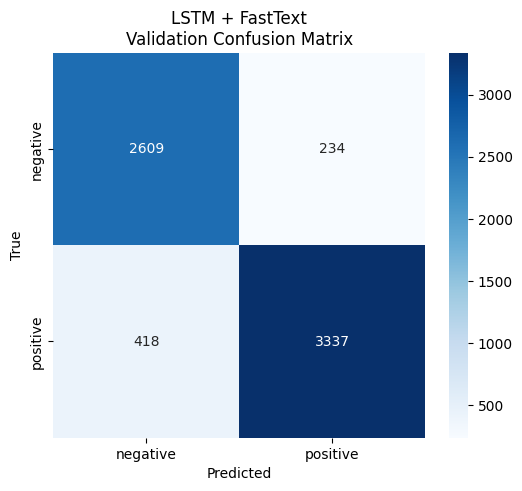

In [125]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


lstm_ft_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=FASTTEXT_VECTOR_SIZE,
        weights=[fasttext_embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


lstm_ft_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


lstm_ft_history = lstm_ft_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_lstm_ft = np.argmax(
    lstm_ft_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== LSTM + FASTTEXT "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_lstm_ft
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_lstm_ft,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_lstm_ft,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_lstm_ft = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_lstm_ft
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "LSTM + FastText\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **LSTM + Word2Vec**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8519 - loss: 0.3467 - val_accuracy: 0.8868 - val_loss: 0.2751 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8812 - loss: 0.2914 - val_accuracy: 0.8968 - val_loss: 0.2561 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8878 - loss: 0.2756 - val_accuracy: 0.8991 - val_loss: 0.2504 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8930 - loss: 0.2649 - val_accuracy: 0.8986 - val_loss: 0.2432 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8987 - loss: 0.2537 - val_accuracy: 0.9033 - val_loss: 0.2386 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9026 - loss: 0.2453 - val_accuracy: 0.9042 - val_loss: 0.2348 - learning_rate: 0.0010
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9055 - loss: 0.

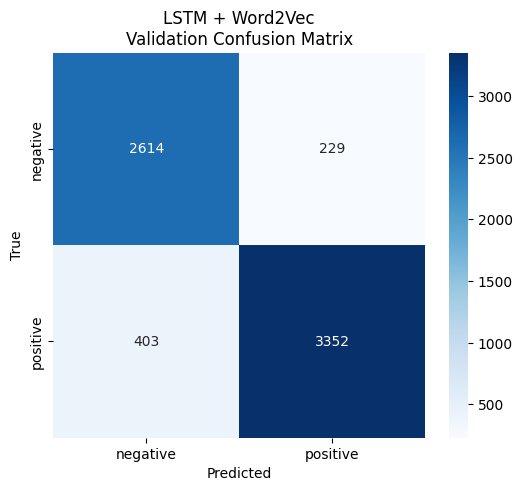

In [126]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


lstm_w2v_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=WORD2VEC_VECTOR_SIZE,
        weights=[word2vec_embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


lstm_w2v_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


lstm_w2v_history = lstm_w2v_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_lstm_w2v = np.argmax(
    lstm_w2v_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== LSTM + WORD2VEC "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_lstm_w2v
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_lstm_w2v,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_lstm_w2v,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_lstm_w2v = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_lstm_w2v
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm_w2v,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "LSTM + Word2Vec\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **LSTM + GloVe**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8270 - loss: 0.3847 - val_accuracy: 0.8716 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8751 - loss: 0.3032 - val_accuracy: 0.8877 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8866 - loss: 0.2812 - val_accuracy: 0.8930 - val_loss: 0.2607 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8939 - loss: 0.2638 - val_accuracy: 0.8959 - val_loss: 0.2549 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8994 - loss: 0.2521 - val_accuracy: 0.9004 - val_loss: 0.2501 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9044 - loss: 0.2410 - val_accuracy: 0.9030 - val_loss: 0.2482 - learning_rate: 0.0010
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9082 - loss: 0.

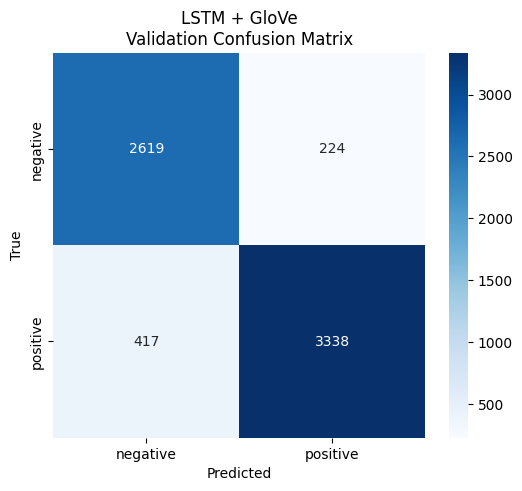

In [127]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


lstm_glove_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_VECTOR_SIZE,
        weights=[glove_embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    LSTM(
        64,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


lstm_glove_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


lstm_glove_history = lstm_glove_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_lstm_glove = np.argmax(
    lstm_glove_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== LSTM + GLOVE "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_lstm_glove
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_lstm_glove,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_lstm_glove,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_lstm_glove = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_lstm_glove
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm_glove,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "LSTM + GloVe\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **BiLSTM + TF-IDF (Unigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6872 - loss: 0.5529 - val_accuracy: 0.8093 - val_loss: 0.4280 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7449 - loss: 0.4820 - val_accuracy: 0.8159 - val_loss: 0.4169 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7498 - loss: 0.4750 - val_accuracy: 0.8169 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7533 - loss: 0.4698 - val_accuracy: 0.8199 - val_loss: 0.4064 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7544 - loss: 0.4675 - val_accuracy: 0.8151 - val_loss: 0.4109 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7559 - loss: 0.4656 - val_accuracy: 0.8196 - val_loss: 0.4042 - learning_rate: 5.0000e-04
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7575

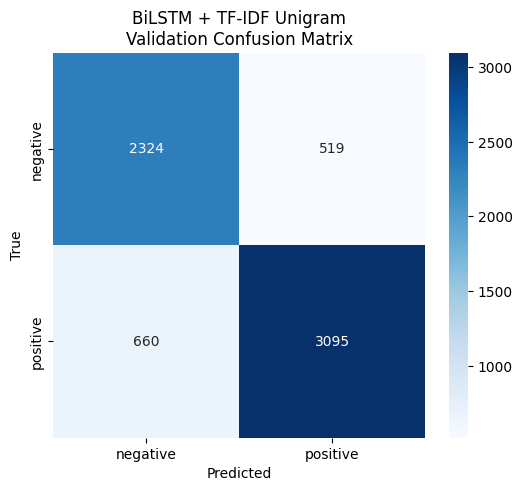

In [128]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


bilstm_tfidf_uni_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_uni_dl.shape[1],
            1
        )
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


bilstm_tfidf_uni_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


bilstm_tfidf_uni_history = (
    bilstm_tfidf_uni_model.fit(
        X_train_tfidf_uni_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_uni_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_bilstm_tfidf_uni = np.argmax(
    bilstm_tfidf_uni_model.predict(
        X_val_tfidf_uni_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== BILSTM + TF-IDF UNIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_uni
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_uni,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_uni,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_bilstm_tfidf_uni = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_bilstm_tfidf_uni
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_tfidf_uni,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "BiLSTM + TF-IDF Unigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **BiLSTM + TF-IDF (Unigram + Bigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6944 - loss: 0.5428 - val_accuracy: 0.8016 - val_loss: 0.4320 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7458 - loss: 0.4832 - val_accuracy: 0.8001 - val_loss: 0.4323 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7535 - loss: 0.4767 - val_accuracy: 0.8115 - val_loss: 0.4161 - learning_rate: 5.0000e-04
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7543 - loss: 0.4717 - val_accuracy: 0.8095 - val_loss: 0.4194 - learning_rate: 5.0000e-04
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.7551 - loss: 0.4670 - val_accuracy: 0.8140 - val_loss: 0.4090 - learning_rate: 2.5000e-04
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7556 - loss: 0.4659 - val_accuracy: 0.8169 - val_loss: 0.4061 - learning_rate: 2.5000e-04
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accu

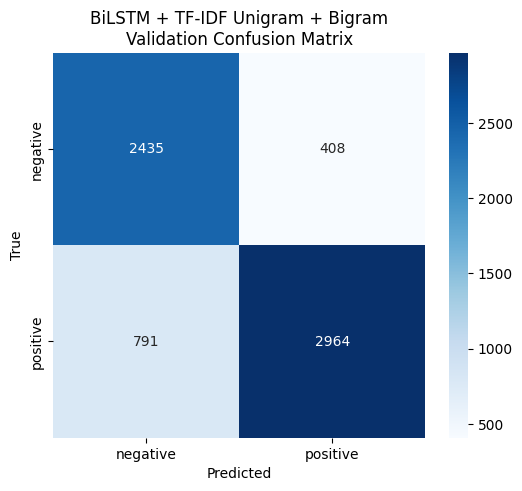

In [129]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


bilstm_tfidf_ub_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_ub_dl.shape[1],
            1
        )
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


bilstm_tfidf_ub_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


bilstm_tfidf_ub_history = (
    bilstm_tfidf_ub_model.fit(
        X_train_tfidf_ub_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_ub_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_bilstm_tfidf_ub = np.argmax(
    bilstm_tfidf_ub_model.predict(
        X_val_tfidf_ub_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== BILSTM + TF-IDF UNIGRAM + BIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_ub
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_ub,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_ub,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_bilstm_tfidf_ub = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_bilstm_tfidf_ub
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_tfidf_ub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "BiLSTM + TF-IDF Unigram + Bigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **BiLSTM + TF-IDF (Unigram + Bigram + Trigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.6654 - loss: 0.5786 - val_accuracy: 0.7796 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7267 - loss: 0.5081 - val_accuracy: 0.7934 - val_loss: 0.4500 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7503 - loss: 0.4772 - val_accuracy: 0.8189 - val_loss: 0.4072 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7561 - loss: 0.4669 - val_accuracy: 0.8168 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7614 - loss: 0.4592 - val_accuracy: 0.8181 - val_loss: 0.4019 - learning_rate: 5.0000e-04
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.7618 - loss: 0.4592 - val_accuracy: 0.8230 - val_loss: 0.3956 - learning_rate: 5.0000e-04
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.

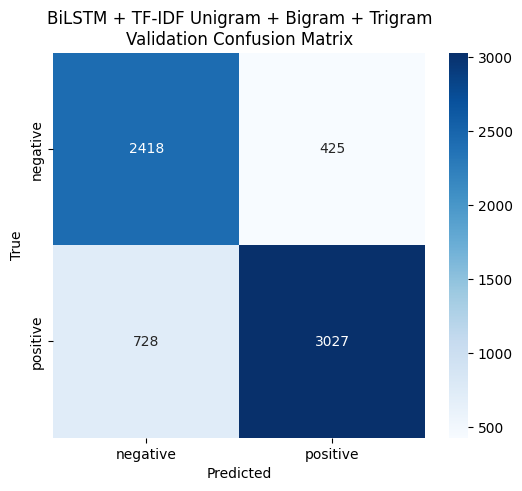

In [130]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


bilstm_tfidf_ubt_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_ubt_dl.shape[1],
            1
        )
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


bilstm_tfidf_ubt_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


bilstm_tfidf_ubt_history = (
    bilstm_tfidf_ubt_model.fit(
        X_train_tfidf_ubt_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_ubt_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_bilstm_tfidf_ubt = np.argmax(
    bilstm_tfidf_ubt_model.predict(
        X_val_tfidf_ubt_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== BILSTM + TF-IDF UNIGRAM + BIGRAM + "
    "TRIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_ubt
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_ubt,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_bilstm_tfidf_ubt,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_bilstm_tfidf_ubt = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_bilstm_tfidf_ubt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_tfidf_ubt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "BiLSTM + TF-IDF Unigram + Bigram + Trigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **BiLSTM + FastText**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8604 - loss: 0.3312 - val_accuracy: 0.8892 - val_loss: 0.2702 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8898 - loss: 0.2762 - val_accuracy: 0.8931 - val_loss: 0.2595 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8973 - loss: 0.2578 - val_accuracy: 0.8962 - val_loss: 0.2605 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9075 - loss: 0.2344 - val_accuracy: 0.8995 - val_loss: 0.2547 - learning_rate: 5.0000e-04
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9110 - loss: 0.2255 - val_accuracy: 0.9018 - val_loss: 0.2515 - learning_rate: 5.0000e-04
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9156 - loss: 0.2146 - val_accuracy: 0.9024 - val_loss: 0.2536 - learning_rate: 5.0000e-04
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.921

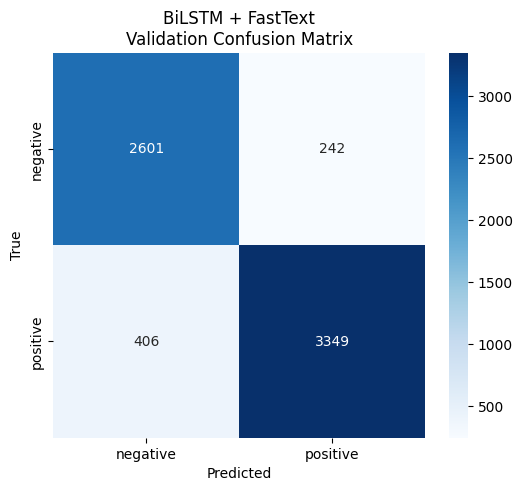

In [131]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


bilstm_ft_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=FASTTEXT_VECTOR_SIZE,
        weights=[fasttext_embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


bilstm_ft_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


bilstm_ft_history = bilstm_ft_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_bilstm_ft = np.argmax(
    bilstm_ft_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== BILSTM + FASTTEXT "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_bilstm_ft
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_bilstm_ft,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_bilstm_ft,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_bilstm_ft = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_bilstm_ft
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "BiLSTM + FastText\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **BiLSTM + Word2Vec**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8668 - loss: 0.3199 - val_accuracy: 0.8875 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8879 - loss: 0.2768 - val_accuracy: 0.8977 - val_loss: 0.2510 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8949 - loss: 0.2621 - val_accuracy: 0.9001 - val_loss: 0.2450 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9005 - loss: 0.2494 - val_accuracy: 0.9001 - val_loss: 0.2385 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9057 - loss: 0.2397 - val_accuracy: 0.9039 - val_loss: 0.2380 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9097 - loss: 0.2295 - val_accuracy: 0.9044 - val_loss: 0.2348 - learning_rate: 0.0010
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9134 - loss: 0

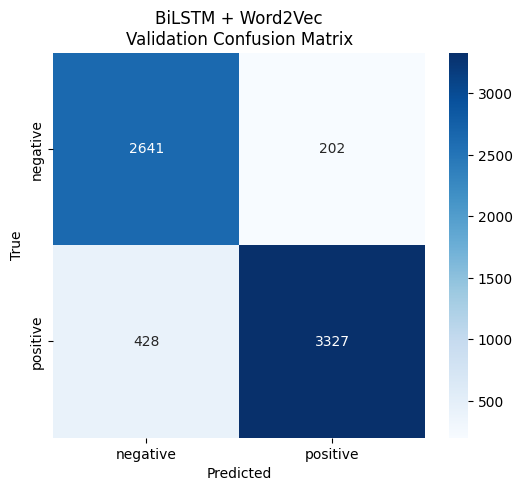

In [132]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


bilstm_w2v_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=WORD2VEC_VECTOR_SIZE,
        weights=[word2vec_embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


bilstm_w2v_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


bilstm_w2v_history = bilstm_w2v_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_bilstm_w2v = np.argmax(
    bilstm_w2v_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== BILSTM + WORD2VEC "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_bilstm_w2v
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_bilstm_w2v,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_bilstm_w2v,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_bilstm_w2v = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_bilstm_w2v
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_w2v,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "BiLSTM + Word2Vec\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **BiLSTM + GloVe**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8438 - loss: 0.3553 - val_accuracy: 0.8818 - val_loss: 0.2819 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8795 - loss: 0.2913 - val_accuracy: 0.8892 - val_loss: 0.2666 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8929 - loss: 0.2666 - val_accuracy: 0.8954 - val_loss: 0.2549 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9006 - loss: 0.2494 - val_accuracy: 0.9000 - val_loss: 0.2507 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9076 - loss: 0.2352 - val_accuracy: 0.9028 - val_loss: 0.2483 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9137 - loss: 0.2212 - val_accuracy: 0.9007 - val_loss: 0.2495 - learning_rate: 0.0010
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9220 - loss: 0

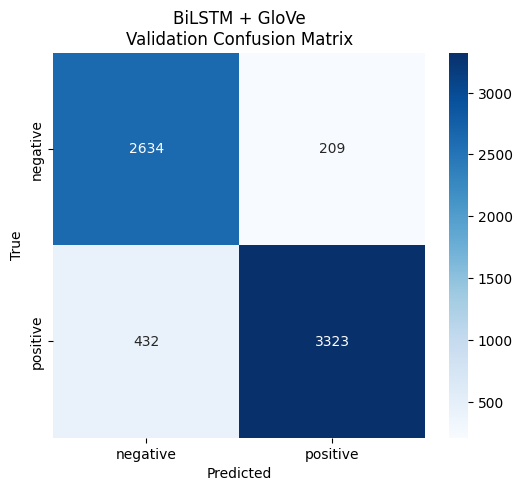

In [133]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


bilstm_glove_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_VECTOR_SIZE,
        weights=[glove_embedding_matrix],
        trainable=False,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


bilstm_glove_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


bilstm_glove_history = bilstm_glove_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_bilstm_glove = np.argmax(
    bilstm_glove_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== BILSTM + GLOVE "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_bilstm_glove
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_bilstm_glove,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_bilstm_glove,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_bilstm_glove = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_bilstm_glove
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_glove,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "BiLSTM + GloVe\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **CNN + TF-IDF (Unigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.7260 - loss: 0.5486 - val_accuracy: 0.7577 - val_loss: 0.5024 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7583 - loss: 0.5026 - val_accuracy: 0.7593 - val_loss: 0.4984 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7612 - loss: 0.4974 - val_accuracy: 0.7624 - val_loss: 0.4925 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7633 - loss: 0.4937 - val_accuracy: 0.7684 - val_loss: 0.4880 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7640 - loss: 0.4917 - val_accuracy: 0.7690 - val_loss: 0.4864 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7648 - loss: 0.4894 - val_accuracy: 0.7684 - val_loss: 0.4866 - learning_rate: 0.0010
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7683 - loss: 0.4862 

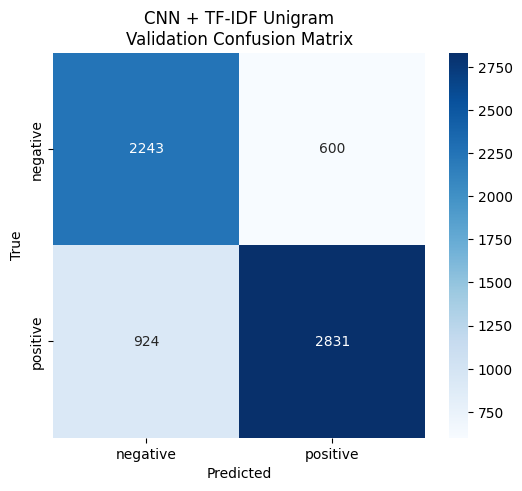

In [134]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


cnn_tfidf_uni_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_uni_dl.shape[1],
            1
        )
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


cnn_tfidf_uni_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


cnn_tfidf_uni_history = (
    cnn_tfidf_uni_model.fit(
        X_train_tfidf_uni_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_uni_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_cnn_tfidf_uni = np.argmax(
    cnn_tfidf_uni_model.predict(
        X_val_tfidf_uni_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== CNN + TF-IDF UNIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_uni
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_uni,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_uni,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_cnn_tfidf_uni = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_cnn_tfidf_uni
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn_tfidf_uni,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "CNN + TF-IDF Unigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **CNN + TF-IDF (Unigram + Bigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7244 - loss: 0.5509 - val_accuracy: 0.7620 - val_loss: 0.5017 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7564 - loss: 0.5048 - val_accuracy: 0.7671 - val_loss: 0.4952 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7634 - loss: 0.4998 - val_accuracy: 0.7710 - val_loss: 0.4899 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7647 - loss: 0.4952 - val_accuracy: 0.7736 - val_loss: 0.4846 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7647 - loss: 0.4932 - val_accuracy: 0.7725 - val_loss: 0.4829 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7671 - loss: 0.4903 - val_accuracy: 0.7710 - val_loss: 0.4835 - learning_rate: 0.0010
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7706 - loss: 0.4862 -

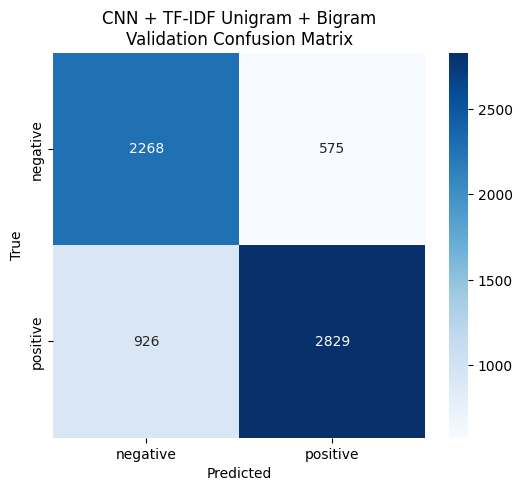

In [135]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


cnn_tfidf_ub_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_ub_dl.shape[1],
            1
        )
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


cnn_tfidf_ub_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


cnn_tfidf_ub_history = (
    cnn_tfidf_ub_model.fit(
        X_train_tfidf_ub_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_ub_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_cnn_tfidf_ub = np.argmax(
    cnn_tfidf_ub_model.predict(
        X_val_tfidf_ub_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== CNN + TF-IDF UNIGRAM + BIGRAM "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_ub
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_ub,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_ub,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_cnn_tfidf_ub = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_cnn_tfidf_ub
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn_tfidf_ub,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "CNN + TF-IDF Unigram + Bigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **CNN + TF-IDF (Unigram + Bigram + Trigram)**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7182 - loss: 0.5608 - val_accuracy: 0.7507 - val_loss: 0.5124 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7476 - loss: 0.5182 - val_accuracy: 0.7554 - val_loss: 0.5028 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7545 - loss: 0.5102 - val_accuracy: 0.7574 - val_loss: 0.4959 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7561 - loss: 0.5044 - val_accuracy: 0.7587 - val_loss: 0.4921 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7589 - loss: 0.5008 - val_accuracy: 0.7614 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7615 - loss: 0.4969 - val_accuracy: 0.7622 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7624 - loss: 0.4935 -

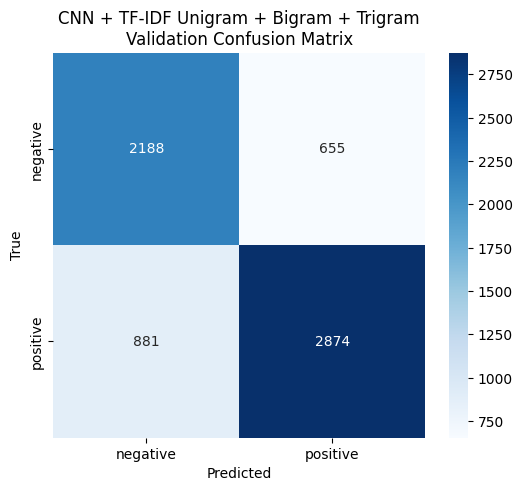

In [136]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


cnn_tfidf_ubt_model = Sequential([
    Input(
        shape=(
            X_train_tfidf_ubt_dl.shape[1],
            1
        )
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_tfidf.classes_),
        activation="softmax"
    )
])


cnn_tfidf_ubt_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


cnn_tfidf_ubt_history = (
    cnn_tfidf_ubt_model.fit(
        X_train_tfidf_ubt_dl,
        y_train_tfidf_enc,

        validation_data=(
            X_val_tfidf_ubt_dl,
            y_val_tfidf_enc
        ),

        epochs=10,
        batch_size=128,

        class_weight=(
            class_weight_dict_tfidf
        ),

        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                patience=1,
                factor=0.5,
                min_lr=1e-6
            )
        ],

        verbose=1
    )
)


y_val_pred_cnn_tfidf_ubt = np.argmax(
    cnn_tfidf_ubt_model.predict(
        X_val_tfidf_ubt_dl,
        verbose=0
    ),
    axis=1
)


print(
    "=== CNN + TF-IDF UNIGRAM + BIGRAM + "
    "TRIGRAM - VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_ubt
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_ubt,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_tfidf_enc,
        y_val_pred_cnn_tfidf_ubt,
        target_names=le_tfidf.classes_,
        zero_division=0
    )
)


cm_cnn_tfidf_ubt = confusion_matrix(
    y_val_tfidf_enc,
    y_val_pred_cnn_tfidf_ubt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn_tfidf_ubt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_tfidf.classes_,
    yticklabels=le_tfidf.classes_
)

plt.title(
    "CNN + TF-IDF Unigram + Bigram + Trigram\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **CNN + FastText**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8164 - loss: 0.4478 - val_accuracy: 0.8618 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8669 - loss: 0.3262 - val_accuracy: 0.8777 - val_loss: 0.2977 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8820 - loss: 0.2940 - val_accuracy: 0.8803 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8904 - loss: 0.2731 - val_accuracy: 0.8857 - val_loss: 0.2813 - learning_rate: 0.0010
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8991 - loss: 0.2579 - val_accuracy: 0.8830 - val_loss: 0.2862 - learning_rate: 0.0010
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9102 - loss: 0.2265 - val_accuracy: 0.8871 - val_loss: 0.2882 - learning_rate: 5.0000e-04
=== CNN + FASTTEXT - VALIDATION RESULTS ===
Accuracy: 0.885722946347378
Weighted F

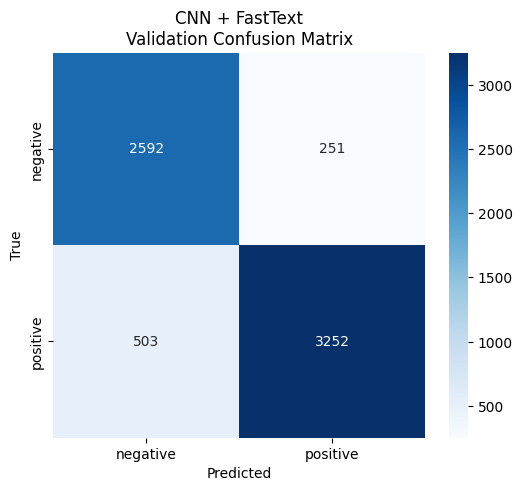

In [137]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


cnn_ft_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=FASTTEXT_VECTOR_SIZE,
        weights=[fasttext_embedding_matrix],
        trainable=False,
        mask_zero=False
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


cnn_ft_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


cnn_ft_history = cnn_ft_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_cnn_ft = np.argmax(
    cnn_ft_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== CNN + FASTTEXT "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_cnn_ft
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_cnn_ft,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_cnn_ft,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_cnn_ft = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_cnn_ft
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn_ft,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "CNN + FastText\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **CNN + Word2Vec**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8757 - loss: 0.3029 - val_accuracy: 0.9044 - val_loss: 0.2412 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9127 - loss: 0.2292 - val_accuracy: 0.9059 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9279 - loss: 0.1932 - val_accuracy: 0.9065 - val_loss: 0.2359 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9466 - loss: 0.1479 - val_accuracy: 0.9054 - val_loss: 0.2500 - learning_rate: 5.0000e-04
=== CNN + WORD2VEC - VALIDATION RESULTS ===
Accuracy: 0.9058805698696575
Weighted F1-score: 0.9059627832579681

Classification Report:

              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      2843
    positive       0.92      0.91      0.92      3755

    accuracy                           0.91      6598
   macro avg       0.90      0.9

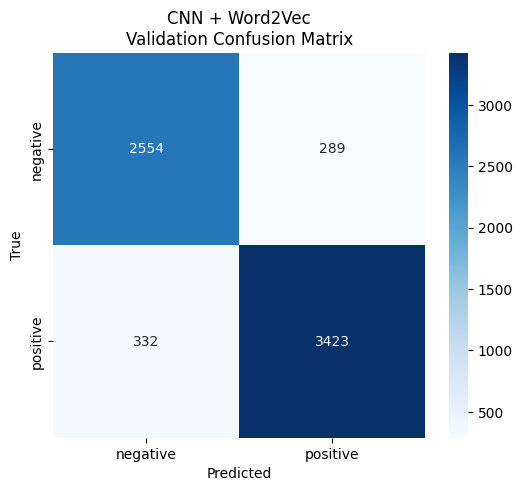

In [138]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


cnn_w2v_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=WORD2VEC_VECTOR_SIZE,
        weights=[word2vec_embedding_matrix],
        trainable=False,
        mask_zero=False
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


cnn_w2v_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


cnn_w2v_history = cnn_w2v_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_cnn_w2v = np.argmax(
    cnn_w2v_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== CNN + WORD2VEC "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_cnn_w2v
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_cnn_w2v,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_cnn_w2v,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_cnn_w2v = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_cnn_w2v
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn_w2v,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "CNN + Word2Vec\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **CNN + GloVe**

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8590 - loss: 0.3341 - val_accuracy: 0.8935 - val_loss: 0.2666 - learning_rate: 0.0010
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8992 - loss: 0.2558 - val_accuracy: 0.8944 - val_loss: 0.2597 - learning_rate: 0.0010
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.2164 - val_accuracy: 0.8912 - val_loss: 0.2729 - learning_rate: 0.0010
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9384 - loss: 0.1659 - val_accuracy: 0.8886 - val_loss: 0.3093 - learning_rate: 5.0000e-04
=== CNN + GLOVE - VALIDATION RESULTS ===
Accuracy: 0.8943619278569264
Weighted F1-score: 0.8943686731877619

Classification Report:

              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      2843
    positive       0.91      0.91      0.91      3755

    accuracy                           0.89      6598
   macro avg       0.89      0.89  

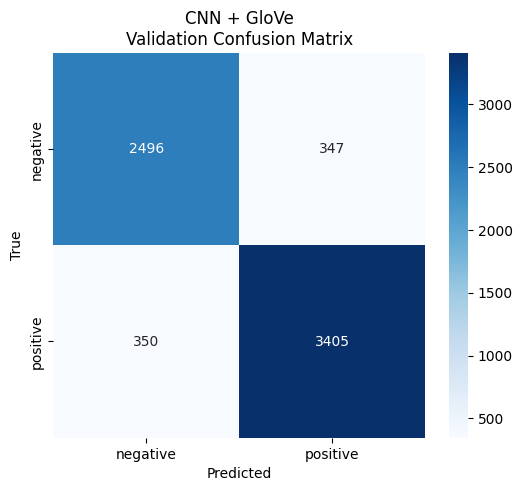

In [139]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)


cnn_glove_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_VECTOR_SIZE,
        weights=[glove_embedding_matrix],
        trainable=False,
        mask_zero=False
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        len(le_emb.classes_),
        activation="softmax"
    )
])


cnn_glove_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


cnn_glove_history = cnn_glove_model.fit(
    X_train_sequence,
    y_train_emb_enc,

    validation_data=(
        X_val_sequence,
        y_val_emb_enc
    ),

    epochs=10,
    batch_size=128,

    class_weight=class_weight_dict_emb,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            patience=1,
            factor=0.5,
            min_lr=1e-6
        )
    ],

    verbose=1
)


y_val_pred_cnn_glove = np.argmax(
    cnn_glove_model.predict(
        X_val_sequence,
        verbose=0
    ),
    axis=1
)


print(
    "=== CNN + GLOVE "
    "- VALIDATION RESULTS ==="
)

print(
    "Accuracy:",
    accuracy_score(
        y_val_emb_enc,
        y_val_pred_cnn_glove
    )
)

print(
    "Weighted F1-score:",
    f1_score(
        y_val_emb_enc,
        y_val_pred_cnn_glove,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_emb_enc,
        y_val_pred_cnn_glove,
        target_names=le_emb.classes_,
        zero_division=0
    )
)


cm_cnn_glove = confusion_matrix(
    y_val_emb_enc,
    y_val_pred_cnn_glove
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn_glove,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_emb.classes_,
    yticklabels=le_emb.classes_
)

plt.title(
    "CNN + GloVe\n"
    "Validation Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Test Set Evaluation**

In [144]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

## **Prepare Models' Test Inputs**

In [145]:
# Logistic Regression:
# Retrieve the untouched TF-IDF unigram + bigram + trigram test data.
X_test_vec_lr_ubt = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["X_test"]
)

tfidf_ubt_vectorizer = (
    tfidf_vectors[
        "unigram_bigram_trigram"
    ]["vectorizer"]
)


# LSTM:
# Convert the embedding test reviews into integer sequences.
X_test_sequence = (
    embedding_tokenizer.texts_to_sequences(
        X_test_emb.astype(str).tolist()
    )
)

# Make all test sequences exactly the same length.
X_test_sequence = pad_sequences(
    X_test_sequence,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)


# Convert labels to NumPy arrays.
y_test_lr = np.asarray(
    y_test_tfidf_enc
).astype(int)

y_test_lstm = np.asarray(
    y_test_emb_enc
).astype(int)


# Reset review-text indexes.
test_text_tfidf = (
    X_test_tfidf
    .reset_index(drop=True)
    .fillna("")
    .astype(str)
)

test_text_embedding = (
    X_test_emb
    .reset_index(drop=True)
    .fillna("")
    .astype(str)
)


# Check that the number of records matches.
assert X_test_vec_lr_ubt.shape[0] == len(y_test_lr)
assert X_test_sequence.shape[0] == len(y_test_lstm)
assert len(test_text_tfidf) == len(y_test_lr)
assert len(test_text_embedding) == len(y_test_lstm)


print(
    "Logistic Regression test shape:",
    X_test_vec_lr_ubt.shape
)

print(
    "LSTM test sequence shape:",
    X_test_sequence.shape
)

print(
    "TF-IDF test classes:",
    list(le_tfidf.classes_)
)

print(
    "Embedding test classes:",
    list(le_emb.classes_)
)

Logistic Regression test shape: (6598, 20000)
LSTM test sequence shape: (6598, 100)
TF-IDF test classes: ['negative', 'positive']
Embedding test classes: ['negative', 'positive']


## **Make Final Test Predictions**

In [146]:
# Logistic Regression prediction

y_test_pred_lr_ubt = lr_ubt_model.predict(
    X_test_vec_lr_ubt
)

lr_test_probabilities = lr_ubt_model.predict_proba(
    X_test_vec_lr_ubt
)

# Highest class probability becomes prediction confidence.
lr_test_confidence = np.max(
    lr_test_probabilities,
    axis=1
)


# Find the encoded value of the positive class.
lr_positive_encoded = int(
    le_tfidf.transform(["positive"])[0]
)

# Find which probability column represents positive.
lr_positive_column = int(
    np.where(
        lr_ubt_model.classes_
        == lr_positive_encoded
    )[0][0]
)

lr_positive_probability = (
    lr_test_probabilities[
        :,
        lr_positive_column
    ]
)


# LSTM + Word2Vec prediction

lstm_test_probabilities = (
    lstm_w2v_model.predict(
        X_test_sequence,
        batch_size=256,
        verbose=1
    )
)

# Select the class with the highest probability.
y_test_pred_lstm_w2v = np.argmax(
    lstm_test_probabilities,
    axis=1
)

# Highest probability becomes prediction confidence.
lstm_test_confidence = np.max(
    lstm_test_probabilities,
    axis=1
)

lstm_positive_encoded = int(
    le_emb.transform(["positive"])[0]
)

lstm_positive_probability = (
    lstm_test_probabilities[
        :,
        lstm_positive_encoded
    ]
)


print(
    "Logistic Regression predictions:",
    len(y_test_pred_lr_ubt)
)

print(
    "LSTM predictions:",
    len(y_test_pred_lstm_w2v)
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Logistic Regression predictions: 6598
LSTM predictions: 6598


For Logistic Regression:
* **predict()** returns the predicted class.
* **predict_proba()** returns the probability for each class.
* The highest probability is used as confidence

For LSTM:
* The output layer returns one probability per sentiment class
*  **np.argmax()** selects the class with the highest probability
* The maximum probability becomes the confidence score.

## **Calculate Final Test Metrics**

In [147]:
def calculate_test_metrics(
    model_name,
    y_true,
    y_pred,
    positive_probability,
    label_encoder
):
    positive_encoded = int(
        label_encoder.transform(["positive"])[0]
    )

    binary_actual = (
        np.asarray(y_true)
        == positive_encoded
    ).astype(int)

    result = {
        "Model": model_name,

        "Test Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Weighted Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            binary_actual,
            positive_probability
        )
    }

    return result


lr_test_metrics = calculate_test_metrics(
    model_name=(
        "Logistic Regression + TF-IDF "
        "Unigram + Bigram + Trigram"
    ),
    y_true=y_test_lr,
    y_pred=y_test_pred_lr_ubt,
    positive_probability=lr_positive_probability,
    label_encoder=le_tfidf
)

lstm_test_metrics = calculate_test_metrics(
    model_name="LSTM + Word2Vec",
    y_true=y_test_lstm,
    y_pred=y_test_pred_lstm_w2v,
    positive_probability=lstm_positive_probability,
    label_encoder=le_emb
)


test_results_summary = pd.DataFrame([
    lr_test_metrics,
    lstm_test_metrics
])

numeric_columns = (
    test_results_summary
    .select_dtypes(include="number")
    .columns
)

test_results_summary[
    numeric_columns
] = test_results_summary[
    numeric_columns
].round(4)


print("=== FINAL TEST RESULT COMPARISON ===")

display(test_results_summary)

=== FINAL TEST RESULT COMPARISON ===


,Model,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,ROC-AUC
0,Logistic Regression + TF-IDF Unigram + Bigram ...,0.9028,0.9053,0.9028,0.9032,0.9017,0.9570
1,LSTM + Word2Vec,0.9091,0.9109,0.9091,0.9093,0.9079,0.9626


* **Accuracy**: Percentage of all correctly predicted reviews
* **Weighted Precision**: Precision while considering class sizes
* **Weighted Recall**: Recall while considering class sizes
* **Weighted F1**: Overall class-balanced performance measure
* **Macro F1: Gives equal importance to negative and positive classes
* **ROC-AUC**: Measures how well the model seperates positive and negative reviews across different thresholds

## **Classification Reports**

In [148]:
print(
    "=== LOGISTIC REGRESSION + TF-IDF UBT "
    "TEST CLASSIFICATION REPORT ===\n"
)

print(
    classification_report(
        y_test_lr,
        y_test_pred_lr_ubt,
        target_names=le_tfidf.classes_,
        digits=4,
        zero_division=0
    )
)


print(
    "\n=== LSTM + WORD2VEC "
    "TEST CLASSIFICATION REPORT ===\n"
)

print(
    classification_report(
        y_test_lstm,
        y_test_pred_lstm_w2v,
        target_names=le_emb.classes_,
        digits=4,
        zero_division=0
    )
)


# Save reports as DataFrames for later export.
lr_test_report_df = pd.DataFrame(
    classification_report(
        y_test_lr,
        y_test_pred_lr_ubt,
        target_names=le_tfidf.classes_,
        output_dict=True,
        zero_division=0
    )
).transpose()

lstm_test_report_df = pd.DataFrame(
    classification_report(
        y_test_lstm,
        y_test_pred_lstm_w2v,
        target_names=le_emb.classes_,
        output_dict=True,
        zero_division=0
    )
).transpose()

=== LOGISTIC REGRESSION + TF-IDF UBT TEST CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    negative     0.8607    0.9240    0.8913      2843
    positive     0.9391    0.8868    0.9122      3755

    accuracy                         0.9028      6598
   macro avg     0.8999    0.9054    0.9017      6598
weighted avg     0.9053    0.9028    0.9032      6598


=== LSTM + WORD2VEC TEST CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    negative     0.8717    0.9251    0.8976      2843
    positive     0.9405    0.8969    0.9182      3755

    accuracy                         0.9091      6598
   macro avg     0.9061    0.9110    0.9079      6598
weighted avg     0.9109    0.9091    0.9093      6598



## **Display Confusion Matrix**

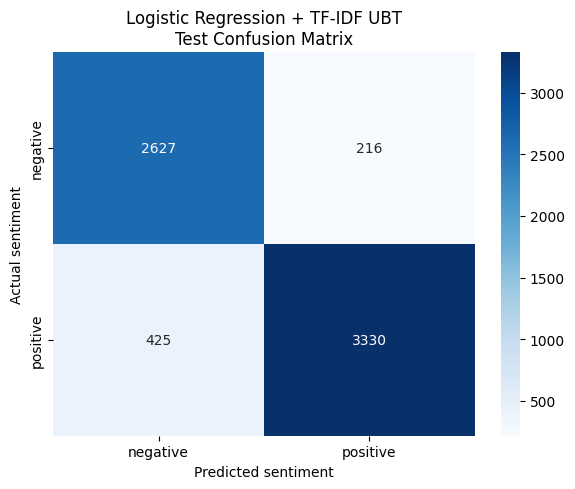

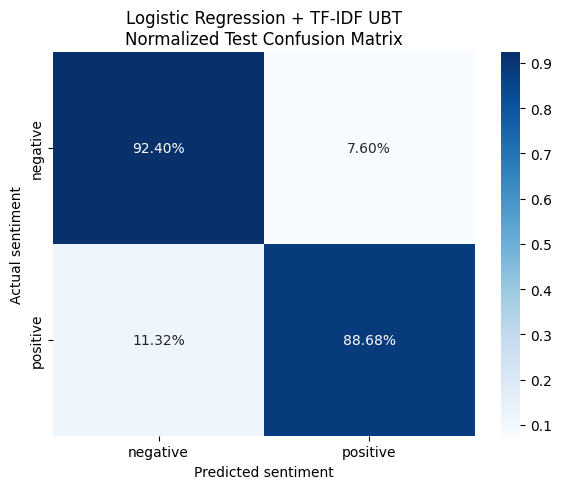

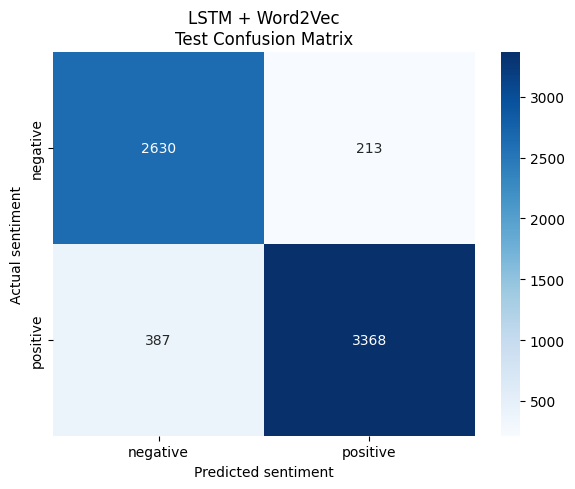

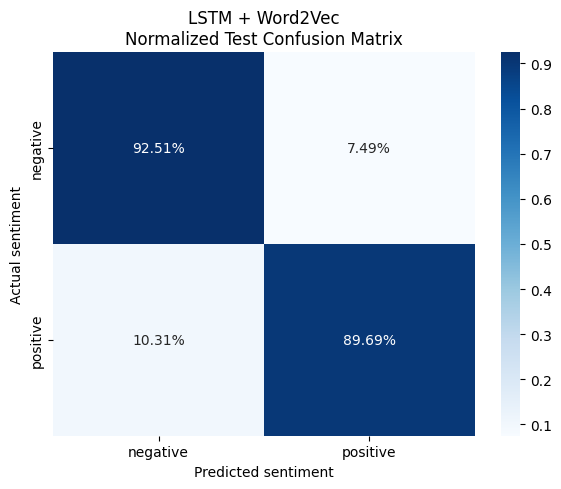

In [149]:
def show_confusion_matrices(
    y_true,
    y_pred,
    class_names,
    model_name
):
    labels = np.arange(
        len(class_names)
    )

    # Count confusion matrix
    count_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        count_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"{model_name}\n"
        "Test Confusion Matrix"
    )

    plt.xlabel("Predicted sentiment")
    plt.ylabel("Actual sentiment")
    plt.tight_layout()
    plt.show()


    # Row-normalized confusion matrix
    normalized_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
        normalize="true"
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        normalized_matrix,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"{model_name}\n"
        "Normalized Test Confusion Matrix"
    )

    plt.xlabel("Predicted sentiment")
    plt.ylabel("Actual sentiment")
    plt.tight_layout()
    plt.show()

    return count_matrix, normalized_matrix


(
    lr_test_confusion_matrix,
    lr_test_normalized_confusion_matrix
) = show_confusion_matrices(
    y_true=y_test_lr,
    y_pred=y_test_pred_lr_ubt,
    class_names=le_tfidf.classes_,
    model_name="Logistic Regression + TF-IDF UBT"
)


(
    lstm_test_confusion_matrix,
    lstm_test_normalized_confusion_matrix
) = show_confusion_matrices(
    y_true=y_test_lstm,
    y_pred=y_test_pred_lstm_w2v,
    class_names=le_emb.classes_,
    model_name="LSTM + Word2Vec"
)

## **Detailed Test-Prediction Tables**

In [150]:
def build_prediction_table(
    texts,
    y_true,
    y_pred,
    confidence,
    positive_probability,
    label_encoder,
    model_name
):
    texts = (
        pd.Series(texts)
        .reset_index(drop=True)
        .fillna("")
        .astype(str)
    )

    result = pd.DataFrame({
        "test_row": np.arange(len(y_true)),
        "review_text": texts,
        "actual_encoded": y_true,
        "predicted_encoded": y_pred,

        "actual_sentiment":
            label_encoder.inverse_transform(
                y_true
            ),

        "predicted_sentiment":
            label_encoder.inverse_transform(
                y_pred
            ),

        "confidence": confidence,

        "positive_probability":
            positive_probability,

        "correct_prediction":
            np.asarray(y_true)
            == np.asarray(y_pred),

        "model": model_name
    })

    result["error_type"] = np.where(
        result["correct_prediction"],
        "Correct",
        result["actual_sentiment"].astype(str)
        + " → "
        + result["predicted_sentiment"].astype(str)
    )

    result["word_count"] = (
        result["review_text"]
        .str.split()
        .str.len()
    )

    return result


lr_test_predictions_df = build_prediction_table(
    texts=test_text_tfidf,
    y_true=y_test_lr,
    y_pred=y_test_pred_lr_ubt,
    confidence=lr_test_confidence,
    positive_probability=lr_positive_probability,
    label_encoder=le_tfidf,
    model_name="Logistic Regression + TF-IDF UBT"
)


lstm_test_predictions_df = build_prediction_table(
    texts=test_text_embedding,
    y_true=y_test_lstm,
    y_pred=y_test_pred_lstm_w2v,
    confidence=lstm_test_confidence,
    positive_probability=lstm_positive_probability,
    label_encoder=le_emb,
    model_name="LSTM + Word2Vec"
)


print("Logistic Regression prediction sample:")

display(
    lr_test_predictions_df.head(10)
)


print("\nLSTM prediction sample:")

display(
    lstm_test_predictions_df.head(10)
)

Logistic Regression prediction sample:


,test_row,review_text,actual_encoded,predicted_encoded,actual_sentiment,predicted_sentiment,confidence,positive_probability,correct_prediction,model,error_type,word_count
0,0,i love this app because i can listen to my fav...,1,1,positive,positive,0.987177,0.987177,True,Logistic Regression + TF-IDF UBT,Correct,20
1,1,"gave me an ad for 30 mins. of ad free music, b...",0,0,negative,negative,0.889907,0.110093,True,Logistic Regression + TF-IDF UBT,Correct,22
2,2,much love. this app is my favorite when it com...,1,1,positive,positive,0.993755,0.993755,True,Logistic Regression + TF-IDF UBT,Correct,24
3,3,i do heavily enjoy spotify - the fact of free ...,1,1,positive,positive,0.918217,0.918217,True,Logistic Regression + TF-IDF UBT,Correct,52
4,4,love the new and the old songs in the past. br...,1,1,positive,positive,0.909375,0.909375,True,Logistic Regression + TF-IDF UBT,Correct,37
5,5,i cannot shuffle through my own liked songs at...,0,0,negative,negative,0.940585,0.059415,True,Logistic Regression + TF-IDF UBT,Correct,43
6,6,great array of good music,1,1,positive,positive,0.988439,0.988439,True,Logistic Regression + TF-IDF UBT,Correct,5
7,7,they know my taste of music and always made a ...,1,1,positive,positive,0.908277,0.908277,True,Logistic Regression + TF-IDF UBT,Correct,14
8,8,for years the app was basically flawless. howe...,0,0,negative,negative,0.969396,0.030604,True,Logistic Regression + TF-IDF UBT,Correct,85
9,9,real awesome. love how at the end of the year ...,1,1,positive,positive,0.883633,0.883633,True,Logistic Regression + TF-IDF UBT,Correct,94



LSTM prediction sample:


,test_row,review_text,actual_encoded,predicted_encoded,actual_sentiment,predicted_sentiment,confidence,positive_probability,correct_prediction,model,error_type,word_count
0,0,i love this app because i can listen to my fav...,1,1,positive,positive,0.993487,0.993487,True,LSTM + Word2Vec,Correct,16
1,1,"gave me an ad for 30 mins. of ad free music, b...",0,0,negative,negative,0.894145,0.105855,True,LSTM + Word2Vec,Correct,22
2,2,much love. this app is my favorite when it com...,1,1,positive,positive,0.998520,0.998520,True,LSTM + Word2Vec,Correct,24
3,3,i do heavily enjoy spotify - the fact of free ...,1,1,positive,positive,0.991459,0.991459,True,LSTM + Word2Vec,Correct,52
4,4,love the new and the old songs in the past. br...,1,1,positive,positive,0.996468,0.996468,True,LSTM + Word2Vec,Correct,37
5,5,i cannot shuffle through my own liked songs at...,0,0,negative,negative,0.973895,0.026105,True,LSTM + Word2Vec,Correct,43
6,6,great array of good music,1,1,positive,positive,0.998201,0.998201,True,LSTM + Word2Vec,Correct,5
7,7,they know my taste of music and always made a ...,1,1,positive,positive,0.990802,0.990802,True,LSTM + Word2Vec,Correct,14
8,8,for years the app was basically flawless. howe...,0,0,negative,negative,0.966414,0.033586,True,LSTM + Word2Vec,Correct,85
9,9,real awesome. love how at the end of the year ...,1,1,positive,positive,0.979416,0.979416,True,LSTM + Word2Vec,Correct,94


Each Test Review Has:
* Original Review Text
* Actual Sentiment
* Predicted Sentiment
* Prediction Confidence
* Positive Probability
* False/ True of Prediction
* Type of Error
* Numbers of Word

## **Most Confident Wrong Predictions**

In [151]:
print(
    "Most confident Logistic Regression errors:"
)

display(
    lr_test_predictions_df[
        ~lr_test_predictions_df[
            "correct_prediction"
        ]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(20)[
        [
            "review_text",
            "actual_sentiment",
            "predicted_sentiment",
            "confidence",
            "error_type"
        ]
    ]
)


print(
    "\nMost confident LSTM errors:"
)

display(
    lstm_test_predictions_df[
        ~lstm_test_predictions_df[
            "correct_prediction"
        ]
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(20)[
        [
            "review_text",
            "actual_sentiment",
            "predicted_sentiment",
            "confidence",
            "error_type"
        ]
    ]
)

Most confident Logistic Regression errors:


,review_text,actual_sentiment,predicted_sentiment,confidence,error_type
1214,best,negative,positive,0.999898,negative → positive
2960,best playing music emoji_emoji_music emoji_emo...,negative,positive,0.998949,negative → positive
177,very good app,negative,positive,0.995999,negative → positive
4946,good app but still missing on many great music...,negative,positive,0.991682,negative → positive
4355,perfect,negative,positive,0.991384,negative → positive
6208,i love it emoji_emoji_love i like it so much e...,negative,positive,0.991015,negative → positive
1523,it crashes after playing a few songs so uninst...,positive,negative,0.988934,positive → negative
1329,it says no internet connection after the updat...,positive,negative,0.987503,positive → negative
2190,definitely the best music streaming app. upd: ...,negative,positive,0.986873,negative → positive
1994,new update made the app buggy. play bar does n...,positive,negative,0.985666,positive → negative



Most confident LSTM errors:


,review_text,actual_sentiment,predicted_sentiment,confidence,error_type
862,app is easy to use and the music is best .,negative,positive,0.998643,negative → positive
2960,best playing music 🎶 👌 ever from the playlist ...,negative,positive,0.997819,negative → positive
369,best for listening,negative,positive,0.996326,negative → positive
5438,love this app. i like to listen to relaxation ...,negative,positive,0.995615,negative → positive
428,spotify is best for listening songs but premiu...,negative,positive,0.995043,negative → positive
4946,good app but still missing on many great music...,negative,positive,0.993744,negative → positive
6014,in my personal opinion it is a good streaming ...,negative,positive,0.993683,negative → positive
6382,overall a good app. but for the love of god br...,negative,positive,0.993073,negative → positive
2190,definitely the best music streaming app. upd: ...,negative,positive,0.992433,negative → positive
3542,love potion is no longer on here along with so...,negative,positive,0.990622,negative → positive


A confident wrong prediction is more important than a low-confidence error because the model strongly believed its incorrect decision.

## **Frequent N-Gram Analysis**

In [152]:
# Keep important negation words.
# Remove general words that would dominate Spotify reviews.
ANALYSIS_STOP_WORDS = sorted(
    (
        set(ENGLISH_STOP_WORDS)
        - {
            "no",
            "not",
            "never",
            "cannot"
        }
    )
    | {
        "spotify",
        "app"
    }
)


def get_top_ngrams(
    texts,
    ngram_size=1,
    top_n=25,
    min_df=2
):
    texts = (
        pd.Series(texts)
        .fillna("")
        .astype(str)
    )

    if texts.str.strip().eq("").all():
        return pd.DataFrame(
            columns=[
                "term",
                "frequency",
                "ngram_size"
            ]
        )

    vectorizer = CountVectorizer(
        ngram_range=(
            ngram_size,
            ngram_size
        ),

        stop_words=ANALYSIS_STOP_WORDS,

        min_df=min_df,

        token_pattern=(
            r"(?u)\b"
            r"[a-zA-Z]"
            r"[a-zA-Z_']+"
            r"\b"
        )
    )

    try:
        count_matrix = vectorizer.fit_transform(
            texts
        )

    except ValueError:
        return pd.DataFrame(
            columns=[
                "term",
                "frequency",
                "ngram_size"
            ]
        )

    frequencies = np.asarray(
        count_matrix.sum(axis=0)
    ).ravel()

    terms = (
        vectorizer
        .get_feature_names_out()
    )

    result = pd.DataFrame({
        "term": terms,
        "frequency": frequencies,
        "ngram_size": ngram_size
    })

    result = (
        result
        .sort_values(
            ["frequency", "term"],
            ascending=[False, True]
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return result


overall_unigrams = get_top_ngrams(
    test_text_tfidf,
    ngram_size=1,
    top_n=25
)

overall_bigrams = get_top_ngrams(
    test_text_tfidf,
    ngram_size=2,
    top_n=25
)

overall_trigrams = get_top_ngrams(
    test_text_tfidf,
    ngram_size=3,
    top_n=25
)


print("Top 25 unigrams:")

display(overall_unigrams)


print("\nTop 25 bigrams:")

display(overall_bigrams)


print("\nTop 25 trigrams:")

display(overall_trigrams)

Top 25 unigrams:


,term,frequency,ngram_size
0,not,2801,1
1,music,2708,1
2,songs,1736,1
3,song,1405,1
4,play,1115,1
5,like,1012,1
6,premium,981,1
7,listen,969,1
8,love,945,1
9,good,915,1



Top 25 bigrams:


,term,frequency,ngram_size
0,does not,387,2
1,best music,231,2
2,listen music,209,2
3,play song,163,2
4,did not,133,2
5,easy use,122,2
6,songs not,119,2
7,not work,115,2
8,not know,112,2
9,not play,108,2



Top 25 trigrams:


,term,frequency,ngram_size
0,does not work,72,3
1,emoji_emoji_negative emoji_emoji_negative emoj...,55,3
2,emoji_emoji_love emoji_emoji_love emoji_emoji_...,54,3
3,emoji_emoji_cry emoji_emoji_cry emoji_emoji_cry,43,3
4,emoji_emoji_perfect emoji_emoji_perfect emoji_...,41,3
5,emoji_emoji_angry emoji_emoji_angry emoji_emoj...,35,3
6,no internet connection,34,3
7,does not play,31,3
8,best music streaming,28,3
9,cannot play song,26,3


* The code removes common English stop words but keeps negation words such as **not**, **never**, because they strongly affect sentiment
* It also removews **spotify** and **app** from analysis because these words may appear in almost every review and hide more meaningful issues.

## **Plot Frequent Terms**

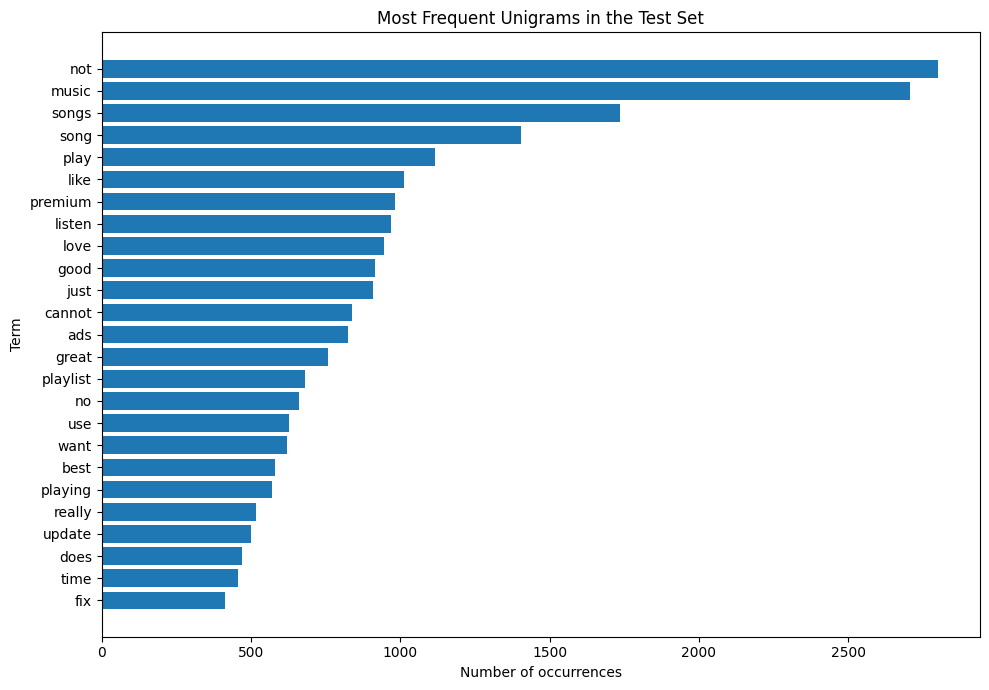

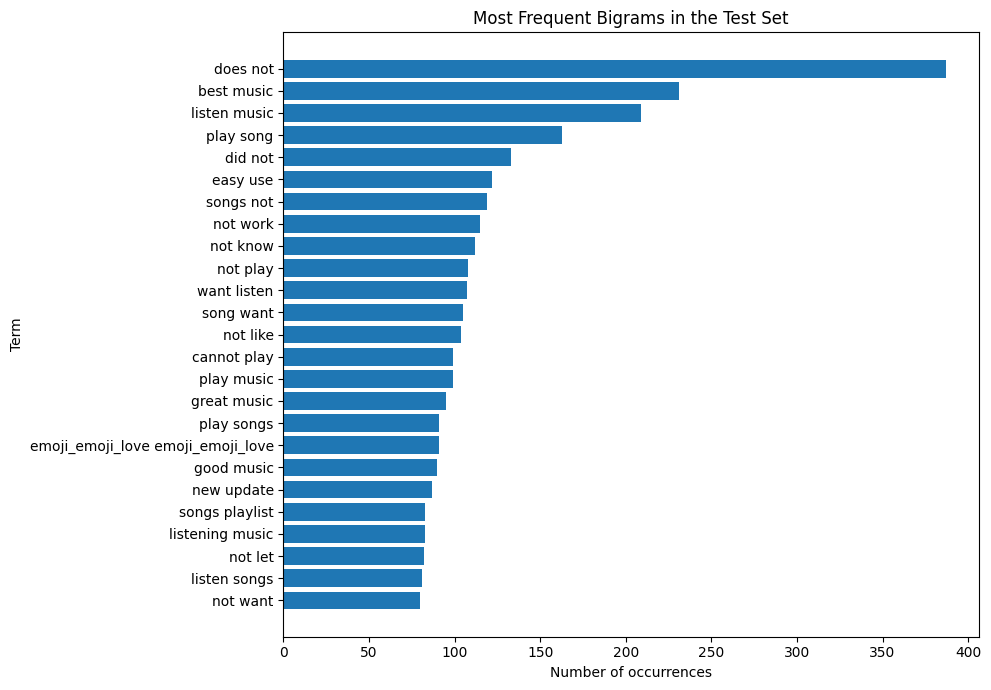

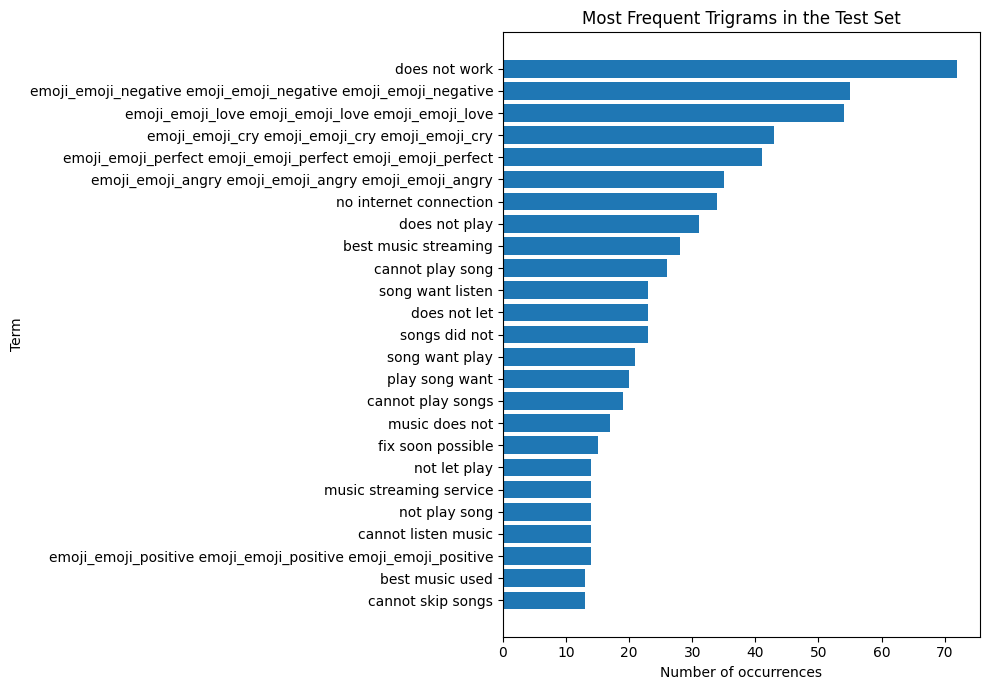

In [153]:
def plot_top_terms(
    frequency_table,
    title
):
    if frequency_table.empty:
        print(
            f"No terms available for {title}"
        )
        return

    plot_data = (
        frequency_table
        .sort_values(
            "frequency",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        plot_data["term"],
        plot_data["frequency"]
    )

    plt.title(title)
    plt.xlabel("Number of occurrences")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()


plot_top_terms(
    overall_unigrams,
    "Most Frequent Unigrams in the Test Set"
)

plot_top_terms(
    overall_bigrams,
    "Most Frequent Bigrams in the Test Set"
)

plot_top_terms(
    overall_trigrams,
    "Most Frequent Trigrams in the Test Set"
)

These charts help identify commonly discussed topics

## **Frequent Terms for Postive and Negative Reviews**

In [154]:
sentiment_frequency_tables = {}


for sentiment_name in le_tfidf.classes_:

    sentiment_reviews = (
        lr_test_predictions_df.loc[
            lr_test_predictions_df[
                "actual_sentiment"
            ] == sentiment_name,
            "review_text"
        ]
    )

    sentiment_unigrams = get_top_ngrams(
        sentiment_reviews,
        ngram_size=1,
        top_n=20
    )

    sentiment_bigrams = get_top_ngrams(
        sentiment_reviews,
        ngram_size=2,
        top_n=20
    )

    sentiment_trigrams = get_top_ngrams(
        sentiment_reviews,
        ngram_size=3,
        top_n=20
    )


    sentiment_frequency_tables[
        f"{sentiment_name}_unigrams"
    ] = sentiment_unigrams

    sentiment_frequency_tables[
        f"{sentiment_name}_bigrams"
    ] = sentiment_bigrams

    sentiment_frequency_tables[
        f"{sentiment_name}_trigrams"
    ] = sentiment_trigrams


    print(
        f"\n=== TOP TERMS IN ACTUAL "
        f"{sentiment_name.upper()} REVIEWS ==="
    )

    print("\nUnigrams:")
    display(sentiment_unigrams)

    print("\nBigrams:")
    display(sentiment_bigrams)

    print("\nTrigrams:")
    display(sentiment_trigrams)


=== TOP TERMS IN ACTUAL NEGATIVE REVIEWS ===

Unigrams:


,term,frequency,ngram_size
0,not,1953,1
1,songs,986,1
2,song,976,1
3,music,907,1
4,play,837,1
5,cannot,651,1
6,premium,587,1
7,just,546,1
8,listen,501,1
9,ads,489,1



Bigrams:


,term,frequency,ngram_size
0,does not,297,2
1,play song,128,2
2,did not,97,2
3,not work,97,2
4,not play,96,2
5,cannot play,91,2
6,listen music,86,2
7,songs not,84,2
8,song want,77,2
9,new update,76,2



Trigrams:


...

,term,frequency,ngram_size
0,music,1801,1
1,not,848,1
2,love,832,1
3,songs,750,1
4,good,714,1
5,great,646,1
6,like,546,1
7,best,536,1
8,listen,468,1
9,song,429,1



Bigrams:


,term,frequency,ngram_size
0,best music,224,2
1,listen music,123,2
2,easy use,117,2
3,does not,90,2
4,great music,89,2
5,emoji_emoji_love emoji_emoji_love,84,2
6,good music,77,2
7,listening music,64,2
8,love music,63,2
9,really good,57,2



Trigrams:


,term,frequency,ngram_size
0,emoji_emoji_love emoji_emoji_love emoji_emoji_...,48,3
1,emoji_emoji_perfect emoji_emoji_perfect emoji_...,41,3
2,best music streaming,26,3
3,emoji_emoji_positive emoji_emoji_positive emoj...,14,3
4,best music used,13,3
5,does not work,13,3
6,best music apps,11,3
7,listen favorite songs,11,3
8,best music player,10,3
9,does not let,10,3


This separates the language used in actual positive and negative reviews.

## **Logistic Regression Feature Importance**

In [155]:
feature_names = np.asarray(
    tfidf_ubt_vectorizer
    .get_feature_names_out()
)

lr_coefficients = np.asarray(
    lr_ubt_model.coef_
)


if lr_coefficients.shape[0] != 1:
    raise ValueError(
        "This feature analysis is designed "
        "for binary classification."
    )


lr_coefficients = lr_coefficients[0]


model_class_zero = int(
    lr_ubt_model.classes_[0]
)

model_class_one = int(
    lr_ubt_model.classes_[1]
)


class_zero_name = str(
    le_tfidf.inverse_transform(
        [model_class_zero]
    )[0]
)

class_one_name = str(
    le_tfidf.inverse_transform(
        [model_class_one]
    )[0]
)


lr_feature_importance_df = pd.DataFrame({
    "term": feature_names,
    "coefficient": lr_coefficients
})


lr_feature_importance_df[
    "ngram_size"
] = (
    lr_feature_importance_df[
        "term"
    ]
    .str.count(" ")
    .add(1)
)


# Negative coefficients favour the first model class.
top_class_zero_features = (
    lr_feature_importance_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(30)
    .reset_index(drop=True)
)


# Positive coefficients favour the second model class.
top_class_one_features = (
    lr_feature_importance_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(30)
    .reset_index(drop=True)
)


print(
    f"Strongest TF-IDF features favouring "
    f"{class_zero_name}:"
)

display(top_class_zero_features)


print(
    f"\nStrongest TF-IDF features favouring "
    f"{class_one_name}:"
)

display(top_class_one_features)

Strongest TF-IDF features favouring negative:


,term,coefficient,ngram_size
0,worst,-6.676288,1
1,not,-6.322636,1
2,cannot,-5.952572,1
3,worse,-4.774840,1
4,horrible,-4.611658,1
5,buggy,-4.421829,1
6,terrible,-4.412119,1
7,misinformation,-4.245932,1
8,cant,-4.204728,1
9,sucks,-4.144540,1



Strongest TF-IDF features favouring positive:


,term,coefficient,ngram_size
0,love,10.977977,1
1,great,8.686555,1
2,best,8.412726,1
3,amazing,6.585178,1
4,good,6.148895,1
5,awesome,5.896515,1
6,easy,5.302884,1
7,excellent,5.283727,1
8,nice,4.029156,1
9,perfect,3.970660,1


Logistic Regression assigns one coefficient to each TF-IDF feature.
* A large positive coefficient supports the model's second encoded class.
* A large negative coefficient supports the model's first encoded class.
* A coefficient near zero has a weak effect on the prediction.

This is different from frequency analysis:
* Frequency tells you which words occur most often.
* Coefficients tell you which words most strongly influence the model.

## **Important Unigrams, Bigrams and Trigrams Seperately**

In [156]:
lr_feature_tables_by_ngram = {}


for ngram_size in [1, 2, 3]:

    ngram_features = (
        lr_feature_importance_df[
            lr_feature_importance_df[
                "ngram_size"
            ] == ngram_size
        ]
    )


    class_zero_features = (
        ngram_features
        .sort_values(
            "coefficient",
            ascending=True
        )
        .head(20)
        .reset_index(drop=True)
    )


    class_one_features = (
        ngram_features
        .sort_values(
            "coefficient",
            ascending=False
        )
        .head(20)
        .reset_index(drop=True)
    )


    lr_feature_tables_by_ngram[
        f"{ngram_size}gram_{class_zero_name}"
    ] = class_zero_features

    lr_feature_tables_by_ngram[
        f"{ngram_size}gram_{class_one_name}"
    ] = class_one_features


    print(
        f"\nTop {ngram_size}-gram features "
        f"favouring {class_zero_name}:"
    )

    display(class_zero_features)


    print(
        f"\nTop {ngram_size}-gram features "
        f"favouring {class_one_name}:"
    )

    display(class_one_features)


Top 1-gram features favouring negative:


,term,coefficient,ngram_size
0,worst,-6.676288,1
1,not,-6.322636,1
2,cannot,-5.952572,1
3,worse,-4.774840,1
4,horrible,-4.611658,1
5,buggy,-4.421829,1
6,terrible,-4.412119,1
7,misinformation,-4.245932,1
8,cant,-4.204728,1
9,sucks,-4.144540,1



Top 1-gram features favouring positive:


,term,coefficient,ngram_size
0,love,10.977977,1
1,great,8.686555,1
2,best,8.412726,1
3,amazing,6.585178,1
4,good,6.148895,1
5,awesome,5.896515,1
6,easy,5.302884,1
7,excellent,5.283727,1
8,nice,4.029156,1
9,perfect,3.970660,1



Top 2-gram features favouring negative:


...

,term,coefficient,ngram_size
0,great app,3.689088,2
1,love it,3.577104,2
2,very good,3.236084,2
3,best music,3.061835,2
4,easy to,3.028984,2
5,the best,3.025535,2
6,no ads,2.954536,2
7,love this,2.916620,2
8,really good,2.752574,2
9,better than,2.699197,2



Top 3-gram features favouring negative:


,term,coefficient,ngram_size
0,used to be,-2.571276,3
1,used to love,-2.227905,3
2,to love this,-1.748186,3
3,does not work,-1.609425,3
4,when it works,-1.524586,3
5,cannot listen to,-1.511403,3
6,to be great,-1.501022,3
7,hate this app,-1.461560,3
8,listening to ads,-1.327916,3
9,you cannot even,-1.251863,3



Top 3-gram features favouring positive:


,term,coefficient,ngram_size
0,love this app,2.466150,3
1,easy to use,1.862204,3
2,it is great,1.566737,3
3,is the best,1.564449,3
4,best music app,1.443705,3
5,is really good,1.390327,3
6,is very good,1.372738,3
7,this app is,1.329690,3
8,thank you spotify,1.305683,3
9,it is amazing,1.302248,3


## **Analyse the Prediction Errors**

In [157]:
def analyse_model_errors(
    prediction_table,
    model_name
):
    error_summary = (
        prediction_table[
            "error_type"
        ]
        .value_counts()
        .rename_axis(
            "error_type"
        )
        .reset_index(
            name="count"
        )
    )

    error_summary[
        "percentage"
    ] = (
        error_summary["count"]
        / len(prediction_table)
        * 100
    ).round(2)


    wrong_predictions = (
        prediction_table[
            ~prediction_table[
                "correct_prediction"
            ]
        ]
        .copy()
    )


    wrong_unigrams = get_top_ngrams(
        wrong_predictions[
            "review_text"
        ],
        ngram_size=1,
        top_n=20
    )


    wrong_bigrams = get_top_ngrams(
        wrong_predictions[
            "review_text"
        ],
        ngram_size=2,
        top_n=20
    )


    print(
        f"\n=== {model_name}: "
        f"ERROR SUMMARY ==="
    )

    display(error_summary)


    print(
        f"\nFrequent words in "
        f"{model_name} errors:"
    )

    display(wrong_unigrams)


    print(
        f"\nFrequent phrases in "
        f"{model_name} errors:"
    )

    display(wrong_bigrams)


    return (
        error_summary,
        wrong_predictions,
        wrong_unigrams,
        wrong_bigrams
    )


(
    lr_error_summary,
    lr_wrong_predictions,
    lr_error_unigrams,
    lr_error_bigrams
) = analyse_model_errors(
    lr_test_predictions_df,
    "Logistic Regression + TF-IDF UBT"
)


(
    lstm_error_summary,
    lstm_wrong_predictions,
    lstm_error_unigrams,
    lstm_error_bigrams
) = analyse_model_errors(
    lstm_test_predictions_df,
    "LSTM + Word2Vec"
)


=== Logistic Regression + TF-IDF UBT: ERROR SUMMARY ===


,error_type,count,percentage
0,Correct,5957,90.28
1,positive → negative,425,6.44
2,negative → positive,216,3.27



Frequent words in Logistic Regression + TF-IDF UBT errors:


,term,frequency,ngram_size
0,not,351,1
1,music,223,1
2,songs,205,1
3,song,167,1
4,play,134,1
5,just,127,1
6,like,127,1
7,ads,112,1
8,premium,108,1
9,listen,95,1



Frequent phrases in Logistic Regression + TF-IDF UBT errors:


...

,error_type,count,percentage
0,Correct,5998,90.91
1,positive → negative,387,5.87
2,negative → positive,213,3.23



Frequent words in LSTM + Word2Vec errors:


,term,frequency,ngram_size
0,not,327,1
1,music,197,1
2,songs,191,1
3,song,150,1
4,like,124,1
5,play,118,1
6,just,114,1
7,premium,105,1
8,ads,101,1
9,cannot,85,1



Frequent phrases in LSTM + Word2Vec errors:


,term,frequency,ngram_size
0,does not,39,2
1,not know,20,2
2,not like,20,2
3,play music,18,2
4,songs playlist,17,2
5,did not,15,2
6,listen music,14,2
7,play song,14,2
8,internet connection,12,2
9,listen songs,12,2


## **Analyse Performance By Review Length**

In [159]:
def review_length_analysis(
    prediction_table
):
    result = prediction_table.copy()

    result["review_length_group"] = pd.cut(
        result["word_count"],

        bins=[
            -1,
            1,
            3,
            6,
            10,
            20,
            40,
            np.inf
        ],

        labels=[
            "1 word",
            "2–3 words",
            "4–6 words",
            "7–10 words",
            "11–20 words",
            "21–40 words",
            "More than 40 words"
        ]
    )


    summary = (
        result
        .groupby(
            "review_length_group",
            observed=False
        )
        .agg(
            review_count=(
                "correct_prediction",
                "size"
            ),

            accuracy=(
                "correct_prediction",
                "mean"
            ),

            average_confidence=(
                "confidence",
                "mean"
            ),

            average_word_count=(
                "word_count",
                "mean"
            )
        )
        .reset_index()
    )


    summary["accuracy"] = (
        summary["accuracy"]
        .round(4)
    )

    summary["average_confidence"] = (
        summary["average_confidence"]
        .round(4)
    )

    summary["average_word_count"] = (
        summary["average_word_count"]
        .round(2)
    )

    return result, summary


(
    lr_length_detail,
    lr_length_summary
) = review_length_analysis(
    lr_test_predictions_df
)


(
    lstm_length_detail,
    lstm_length_summary
) = review_length_analysis(
    lstm_test_predictions_df
)


print(
    "Logistic Regression performance "
    "by review length:"
)

display(lr_length_summary)


print(
    "\nLSTM performance "
    "by review length:"
)

display(lstm_length_summary)

Logistic Regression performance by review length:


,review_length_group,review_count,accuracy,average_confidence,average_word_count
0,1 word,32,0.9062,0.9224,1.00
1,2–3 words,252,0.8968,0.8814,2.62
2,4–6 words,484,0.9318,0.8976,5.13
3,7–10 words,775,0.9394,0.8955,8.43
4,11–20 words,1579,0.9151,0.8638,15.19
5,21–40 words,1877,0.8865,0.8427,29.37
6,More than 40 words,1599,0.8843,0.8593,63.92



LSTM performance by review length:


,review_length_group,review_count,accuracy,average_confidence,average_word_count
0,1 word,45,0.8889,0.8579,1.00
1,2–3 words,259,0.9035,0.8980,2.60
2,4–6 words,496,0.9355,0.9196,5.12
3,7–10 words,772,0.9378,0.9330,8.45
4,11–20 words,1572,0.9141,0.9189,15.16
5,21–40 words,1863,0.8964,0.8866,29.39
6,More than 40 words,1591,0.8982,0.8874,63.76


This checks whether the models perform differently on:

* One-word reviews
* Short reviews
* Medium reviews
* Long reviews

Short reviews may be difficult because they contain limited context. Long reviews may also be difficult when they contain mixed positive and negative information.

## **Plot Accuracy by Review Length**

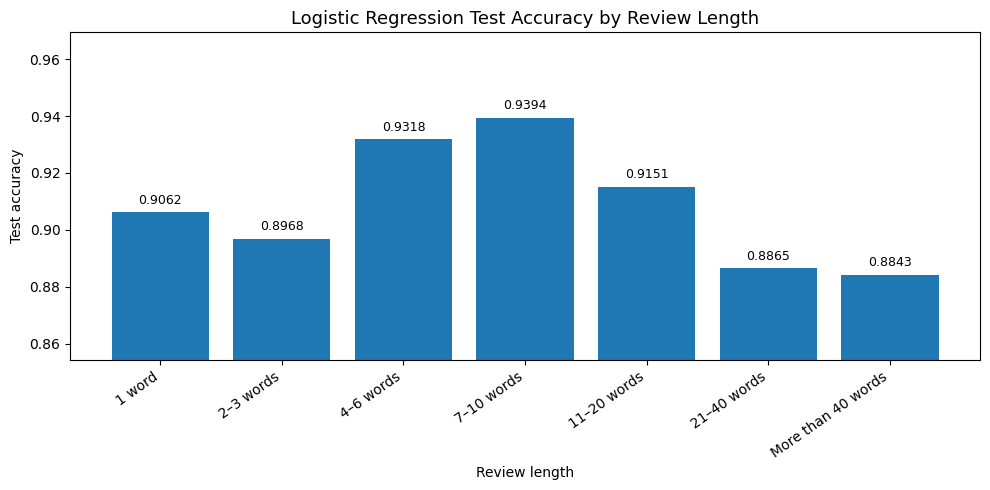

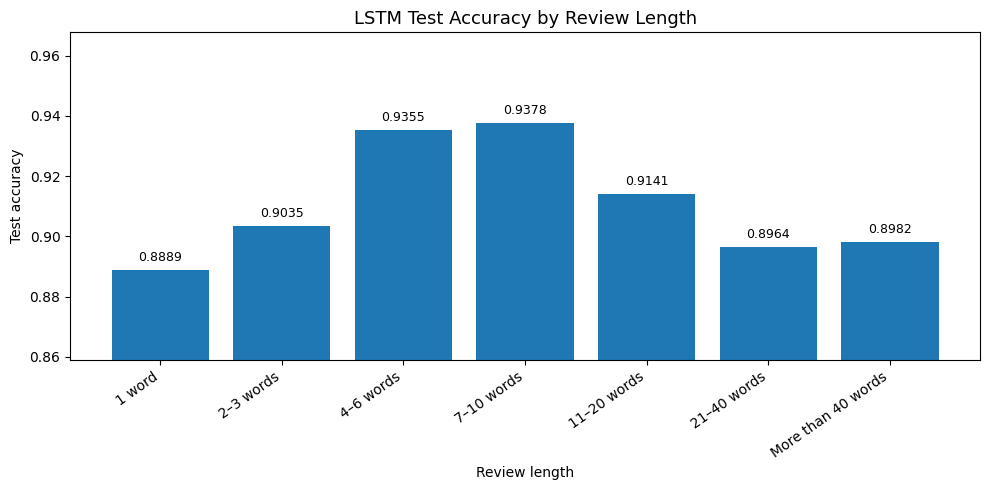

In [166]:
import matplotlib.pyplot as plt
import numpy as np

def plot_review_length_accuracy(length_summary, title):
    plot_data = (
        length_summary
        .dropna(subset=["accuracy"])
        .copy()
    )

    x_labels = plot_data["review_length_group"].astype(str)
    y_values = plot_data["accuracy"].values

    # Automatically zoom the y-axis to make small differences clearer
    y_min = max(0, y_values.min() - 0.03)
    y_max = min(1, y_values.max() + 0.03)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(x_labels, y_values)

    # Zoomed y-axis
    plt.ylim(y_min, y_max)

    plt.title(title, fontsize=13)
    plt.xlabel("Review length")
    plt.ylabel("Test accuracy")

    plt.xticks(rotation=35, ha="right")

    # Add exact values on top of each bar
    for bar, value in zip(bars, y_values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.002,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


plot_review_length_accuracy(
    lr_length_summary,
    "Logistic Regression Test Accuracy by Review Length"
)

plot_review_length_accuracy(
    lstm_length_summary,
    "LSTM Test Accuracy by Review Length"
)

## **Analyse Confidence Reliability**

In [162]:
def confidence_analysis(
    prediction_table
):
    result = prediction_table.copy()

    result[
        "confidence_group"
    ] = pd.cut(
        result["confidence"],

        bins=[
            0.00,
            0.60,
            0.70,
            0.80,
            0.90,
            1.00
        ],

        include_lowest=True,

        labels=[
            "0.50–0.60",
            "0.60–0.70",
            "0.70–0.80",
            "0.80–0.90",
            "0.90–1.00"
        ]
    )


    summary = (
        result
        .groupby(
            "confidence_group",
            observed=False
        )
        .agg(
            prediction_count=(
                "correct_prediction",
                "size"
            ),

            accuracy=(
                "correct_prediction",
                "mean"
            ),

            average_confidence=(
                "confidence",
                "mean"
            )
        )
        .reset_index()
    )


    summary[
        "accuracy"
    ] = summary[
        "accuracy"
    ].round(4)

    summary[
        "average_confidence"
    ] = summary[
        "average_confidence"
    ].round(4)

    return summary


lr_confidence_summary = confidence_analysis(
    lr_test_predictions_df
)

lstm_confidence_summary = confidence_analysis(
    lstm_test_predictions_df
)


print(
    "Logistic Regression confidence analysis:"
)

display(lr_confidence_summary)


print(
    "\nLSTM confidence analysis:"
)

display(lstm_confidence_summary)

Logistic Regression confidence analysis:


,confidence_group,prediction_count,accuracy,average_confidence
0,0.50–0.60,422,0.5829,0.5501
1,0.60–0.70,526,0.7186,0.6536
2,0.70–0.80,769,0.8453,0.7538
3,0.80–0.90,1336,0.9244,0.8563
4,0.90–1.00,3545,0.9726,0.9592



LSTM confidence analysis:


,confidence_group,prediction_count,accuracy,average_confidence
0,0.50–0.60,294,0.5714,0.5492
1,0.60–0.70,384,0.6901,0.6526
2,0.70–0.80,492,0.7825,0.7516
3,0.80–0.90,892,0.8733,0.8565
4,0.90–1.00,4536,0.9702,0.9722


## **Compare Actual and Predicted Sentimen Distributions**

In [164]:
def sentiment_distribution(
    prediction_table,
    model_name
):
    actual_distribution = (
        prediction_table[
            "actual_sentiment"
        ]
        .value_counts()
        .rename(
            "actual_count"
        )
    )

    predicted_distribution = (
        prediction_table[
            "predicted_sentiment"
        ]
        .value_counts()
        .rename(
            "predicted_count"
        )
    )

    result = pd.concat(
        [
            actual_distribution,
            predicted_distribution
        ],
        axis=1
    ).fillna(0)

    result = result.reset_index().rename(
        columns={
            "index": "sentiment"
        }
    )

    result[
        "actual_percentage"
    ] = (
        result["actual_count"]
        / result["actual_count"].sum()
        * 100
    ).round(2)

    result[
        "predicted_percentage"
    ] = (
        result["predicted_count"]
        / result["predicted_count"].sum()
        * 100
    ).round(2)

    result.insert(
        0,
        "model",
        model_name
    )

    return result


lr_sentiment_distribution = sentiment_distribution(
    lr_test_predictions_df,
    "Logistic Regression + TF-IDF UBT"
)

lstm_sentiment_distribution = sentiment_distribution(
    lstm_test_predictions_df,
    "LSTM + Word2Vec"
)


sentiment_distribution_summary = pd.concat(
    [
        lr_sentiment_distribution,
        lstm_sentiment_distribution
    ],
    ignore_index=True
)


display(sentiment_distribution_summary)

,model,sentiment,actual_count,predicted_count,actual_percentage,predicted_percentage
0,Logistic Regression + TF-IDF UBT,positive,3755,3546,56.91,53.74
1,Logistic Regression + TF-IDF UBT,negative,2843,3052,43.09,46.26
2,LSTM + Word2Vec,positive,3755,3581,56.91,54.27
3,LSTM + Word2Vec,negative,2843,3017,43.09,45.73


## **Calculate Net Sentiment Index**

In [165]:
def calculate_net_sentiment_index(
    prediction_table,
    model_name
):
    predicted_percentages = (
        prediction_table[
            "predicted_sentiment"
        ]
        .astype(str)
        .str.lower()
        .value_counts(
            normalize=True
        )
        .mul(100)
    )


    positive_percentage = (
        predicted_percentages
        .get(
            "positive",
            0.0
        )
    )

    negative_percentage = (
        predicted_percentages
        .get(
            "negative",
            0.0
        )
    )


    return {
        "Model": model_name,

        "Predicted Positive Percentage":
            positive_percentage,

        "Predicted Negative Percentage":
            negative_percentage,

        "Net Sentiment Index":
            positive_percentage
            - negative_percentage
    }


brand_reputation_summary = pd.DataFrame([
    calculate_net_sentiment_index(
        lr_test_predictions_df,
        "Logistic Regression + TF-IDF UBT"
    ),

    calculate_net_sentiment_index(
        lstm_test_predictions_df,
        "LSTM + Word2Vec"
    )
]).round(2)


display(brand_reputation_summary)

,Model,Predicted Positive Percentage,Predicted Negative Percentage,Net Sentiment Index
0,Logistic Regression + TF-IDF UBT,53.74,46.26,7.49
1,LSTM + Word2Vec,54.27,45.73,8.55
